In [10]:
from pathlib import Path
import pandas as pd

file_path_m = Path.home() / "Downloads" / "mechanisms.xlsx"
mechanisms = pd.read_excel(file_path_m)

file_path_t = Path.home() / "Downloads" / "triggers.xlsx"
triggers = pd.read_excel(file_path_t)


mechanisms.head()

,Table 1.6.2-2Mechanisms of injury for US and Canadian scuba fatalities,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Mechanism,2016,2015,2014,2010,2011,2012,2013,2017,2018
1,Breathing Issues/ Out of air,2,0,3,7,9,7,10,2,1
2,Panic,3,1,0,0,2,5,0,0,0
3,Ascent/ Pressure-related,3,5,2,19,8,4,2,4,4
4,Exhaustion,2,0,0,0,0,1,1,0,0


In [11]:
file_path_r = Path.home() / "Downloads" / "region_country.xlsx"
region_country = pd.read_excel(file_path_r)

file_path_max = Path.home() / "Downloads" / "max_depth.xlsx"
max_depth = pd.read_excel(file_path_max)

file_path_certifications = Path.home() / "Downloads" / "certifications.xlsx"
certifications = pd.read_excel(file_path_certifications)

In [7]:
print("region_country shape:", region_country.shape)
print("columns:", list(region_country.columns))
display(region_country.head(10))

region_country shape: (100, 12)
columns: ['Region', 'country', 'number 2016', 2010, 2011, 2012, 2013, 2014, 2015, 2017, 2019, 2020]


,Region,country,number 2016,2010,2011,2012,2013,2014,2015,2017,2019,2020
0,North America,NaN,72.0,62,90,73,67,60,46,85,77,58
1,NaN,United States,59.0,56,74,56,48,50,39,71,67,49
2,NaN,Mexico,8.0,1,9,9,8,6,2,6,5,3
3,NaN,Canada,5.0,4,6,7,10,4,4,8,5,6
4,NaN,Bermuda,0.0,0,1,1,1,0,1,0,0,0
5,NaN,Greenland,0.0,1,0,0,0,0,0,0,0,0
6,Oceania,NaN,23.0,12,18,11,19,14,18,24,25,18
7,NaN,Australia,14.0,6,11,7,11,5,8,7,14,9
8,NaN,French Polynesia,0.0,0,0,0,0,0,1,3,0,1
9,NaN,Marshall Island,0.0,0,0,0,0,0,1,0,0,0


,Region,year,fatalities,total_fatalities,proportion
0,North America,2010,62.0,117.0,0.529915
1,Oceania,2010,12.0,117.0,0.102564
2,Caribbean,2010,6.0,117.0,0.051282
3,South America,2010,1.0,117.0,0.008547
4,Northern Africa,2010,4.0,117.0,0.034188


,Region,country,year,fatalities,total_fatalities,proportion
0,North America,United States,2010,56.0,117.0,0.478632
1,North America,Mexico,2010,1.0,117.0,0.008547
2,North America,Canada,2010,4.0,117.0,0.034188
3,North America,Bermuda,2010,0.0,117.0,0.000000
4,North America,Greenland,2010,1.0,117.0,0.008547


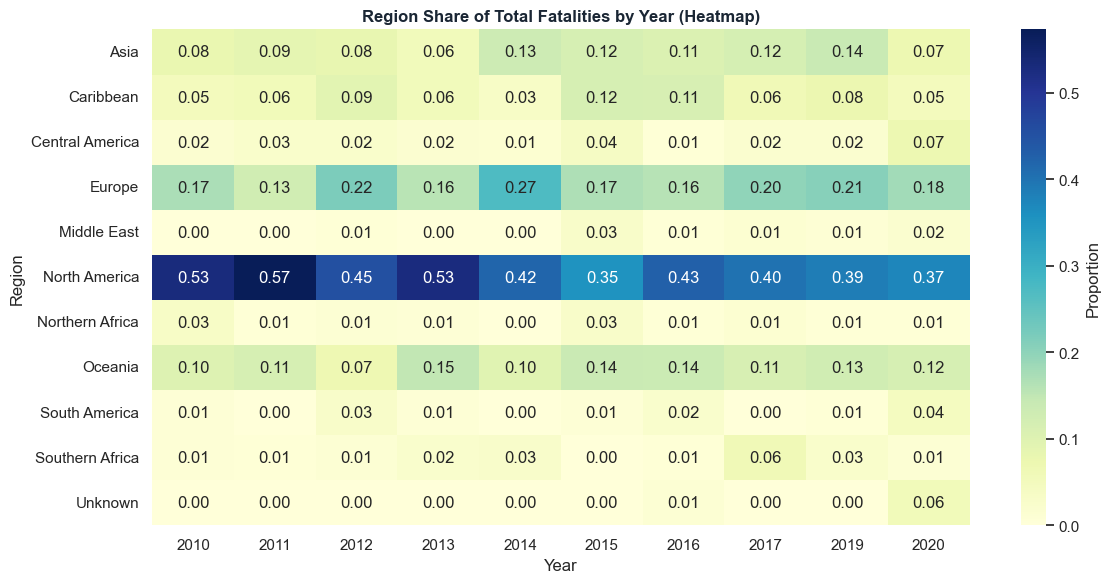

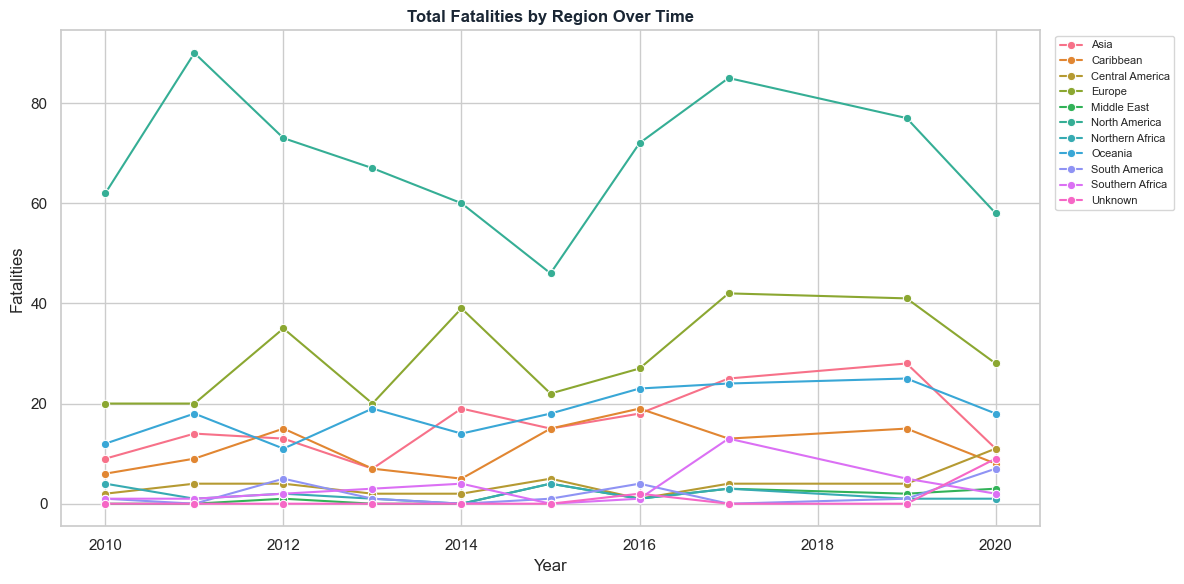

Top 10 countries by total fatalities:


,country,fatalities
78,United States,569.0
2,Australia,92.0
77,United Kingdom,69.0
11,Canada,59.0
44,Mexico,57.0
50,New Zealand,52.0
36,Italy,37.0
54,Philippines,31.0
52,Other,31.0
34,Indonesia,31.0


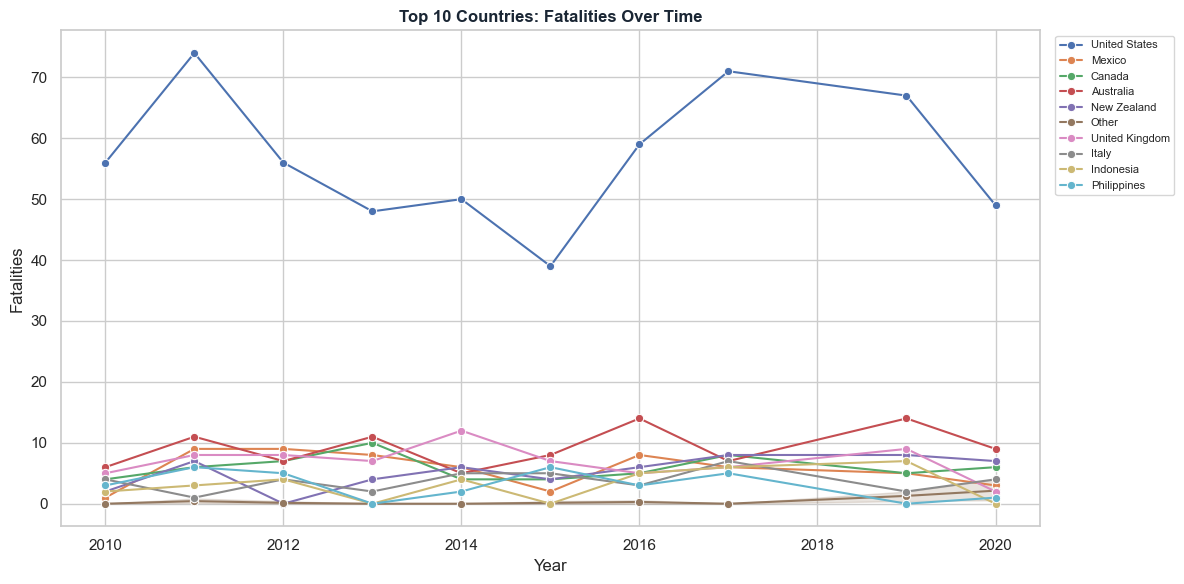

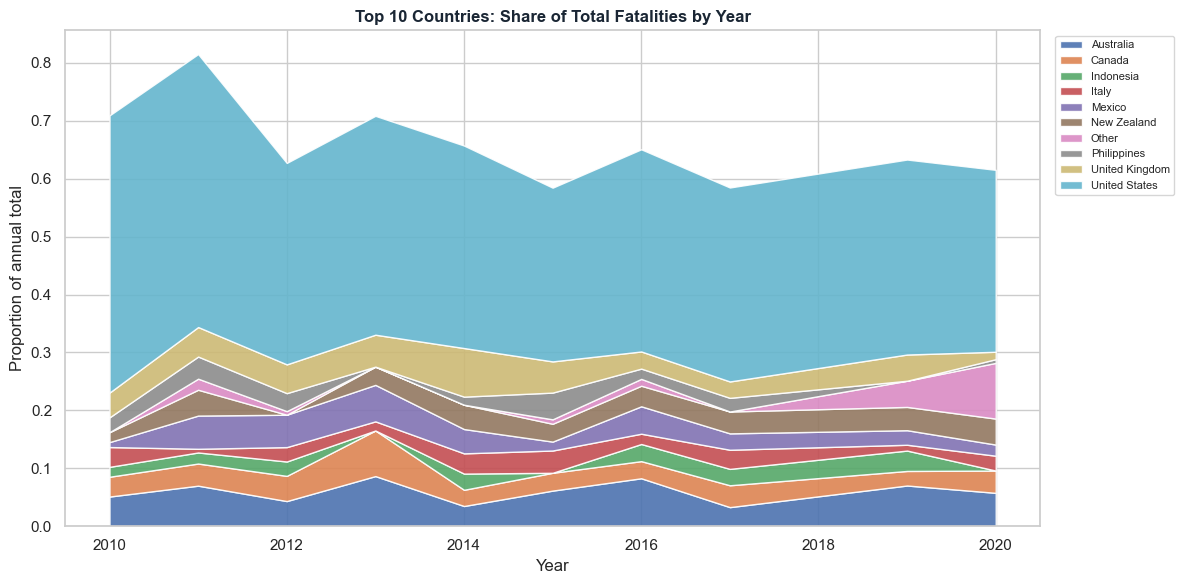

In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

###reshaping
rc = region_country.copy()
rc.columns = [str(c).strip() for c in rc.columns]


year_map = {}
for col in rc.columns:
    m = re.search(r"(19\d{2}|20\d{2})", str(col))
    if m:
        year_map[col] = int(m.group(1))

if not year_map:
    raise ValueError("No year columns found in region_country")

rc = rc.rename(columns=year_map)
year_cols = sorted([c for c in rc.columns if isinstance(c, int)])

#fwrd fill region name to country rows
rc["Region"] = rc["Region"].ffill()

##region total rows are those with no country value
region_rows = rc[rc["country"].isna()].copy()
country_rows = rc[rc["country"].notna()].copy()


region_long = region_rows.melt(id_vars=["Region"], value_vars=year_cols, var_name="year", value_name="fatalities")
region_long["fatalities"] = pd.to_numeric(region_long["fatalities"], errors="coerce").fillna(0)
region_long["year"] = region_long["year"].astype(int)

country_long = country_rows.melt(id_vars=["Region", "country"], value_vars=year_cols, var_name="year", value_name="fatalities")
country_long["fatalities"] = pd.to_numeric(country_long["fatalities"], errors="coerce").fillna(0)
country_long["year"] = country_long["year"].astype(int)

#totals by year from region totals
year_totals = region_long.groupby("year", as_index=False)["fatalities"].sum().rename(columns={"fatalities": "total_fatalities"})

###proportions of total by year
region_prop = region_long.merge(year_totals, on="year", how="left")
region_prop["proportion"] = np.where(region_prop["total_fatalities"] > 0, region_prop["fatalities"] / region_prop["total_fatalities"], 0)

country_prop = country_long.merge(year_totals, on="year", how="left")
country_prop["proportion"] = np.where(country_prop["total_fatalities"] > 0, country_prop["fatalities"] / country_prop["total_fatalities"], 0)


display(region_prop.head())
display(country_prop.head())

# CHART 1: Region share of total fatalities by year (heatmap)
region_share_heatmap = (
    region_prop.pivot_table(index="Region", columns="year", values="proportion", aggfunc="sum", fill_value=0)
    .sort_index()
)
plt.figure(figsize=(12, 6))
sns.heatmap(region_share_heatmap, cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={"label": "Proportion"})
plt.title("Region Share of Total Fatalities by Year (Heatmap)")
plt.xlabel("Year")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

# CHART 2: Totals of fatalities by region over time (separate chart)
region_totals_ts = region_long.groupby(["year", "Region"], as_index=False)["fatalities"].sum()
plt.figure(figsize=(12, 6))
sns.lineplot(data=region_totals_ts, x="year", y="fatalities", hue="Region", marker="o")
plt.title("Total Fatalities by Region Over Time")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

#top 10 countries by total fatalities
top10_countries = (
    country_long.groupby("country", as_index=False)["fatalities"]
    .sum()
    .sort_values("fatalities", ascending=False)
    .head(10)
)
print("Top 10 countries by total fatalities:")
display(top10_countries)

top10_list = top10_countries["country"].tolist()
top10_country_ts = country_long[country_long["country"].isin(top10_list)].copy()

# ---------- Chart 3: Top 10 countries fatalities over time ----------
plt.figure(figsize=(12, 6))
sns.lineplot(data=top10_country_ts, x="year", y="fatalities", hue="country", marker="o")
plt.title("Top 10 Countries: Fatalities Over Time")
plt.xlabel("Year")
plt.ylabel("Fatalities")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

# proportions for top 10 countries
top10_country_prop = country_prop[country_prop["country"].isin(top10_list)].copy()
top10_prop_pivot = top10_country_prop.pivot_table(index="year", columns="country", values="proportion", aggfunc="sum", fill_value=0).sort_index()
plt.figure(figsize=(12, 6))
plt.stackplot(top10_prop_pivot.index, top10_prop_pivot.values.T, labels=top10_prop_pivot.columns, alpha=0.9)
plt.title("Top 10 Countries: Share of Total Fatalities by Year")
plt.xlabel("Year")
plt.ylabel("Proportion of annual total")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

Most common max depth categories (overall):


,category,count
4,up to 30 ft,79
0,31-60,75
1,61-90,52
3,more than 120,49
2,91-120,40


/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_4841/688760438.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=max_depth_overall, x="count", y="category", palette="viridis")


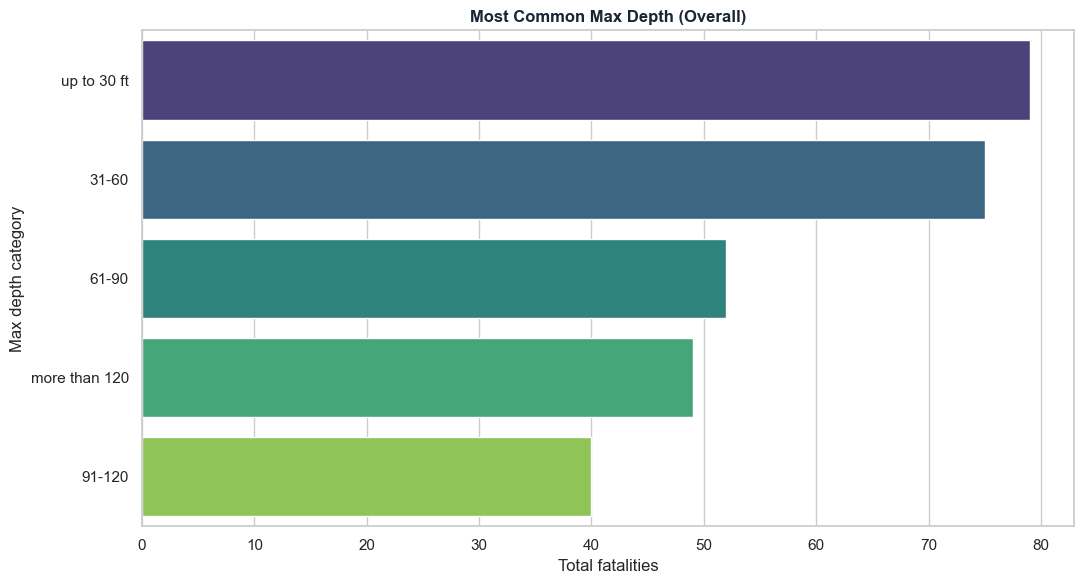

/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_4841/688760438.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_depth_ts = max_depth_top.groupby(["period", "category"], as_index=False)["count"].sum()


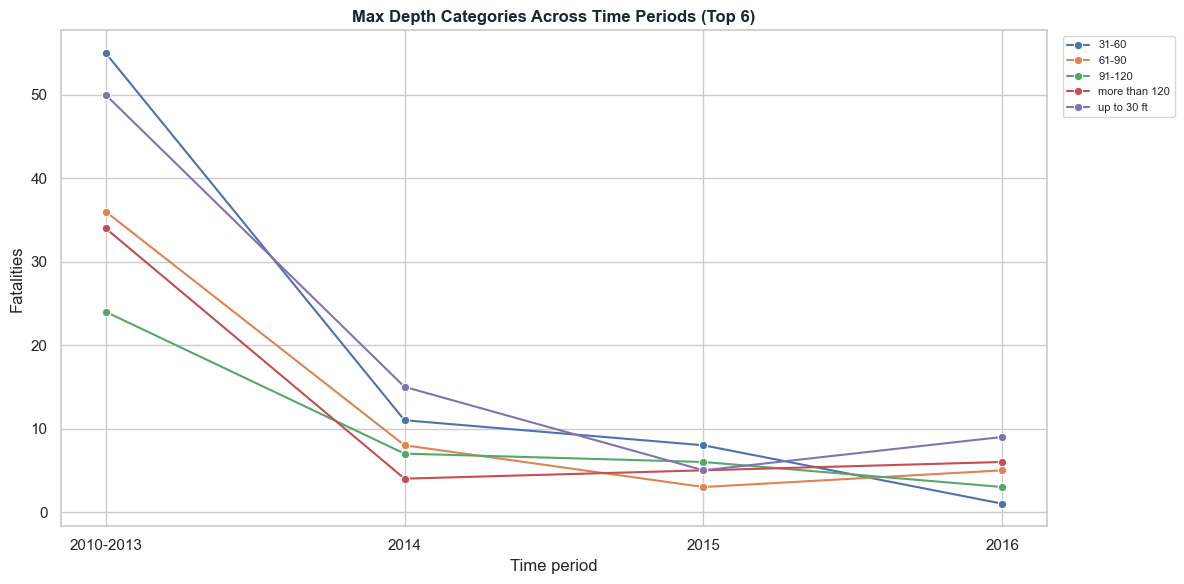

In [13]:
#Max depth
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

md = max_depth.copy()
md.columns = [str(c).strip() for c in md.columns]

# Identify columns
category_col = next((c for c in md.columns if "max depth" in c.lower()), md.columns[1])
time_cols = [c for c in md.columns if re.search(r"^\d{4}(?:-\d{4})?$", str(c).strip())]

if not time_cols:
    raise ValueError(f"No year/time-period columns found in max_depth. Columns: {list(md.columns)}")

#long table
max_depth_long = md.melt(id_vars=[category_col], value_vars=time_cols, var_name="period", value_name="count")
max_depth_long = max_depth_long.rename(columns={category_col: "category"})
max_depth_long["category"] = max_depth_long["category"].astype(str).str.strip()
max_depth_long["count"] = pd.to_numeric(max_depth_long["count"], errors="coerce")
max_depth_long = max_depth_long.dropna(subset=["count", "category"])


max_depth_long = max_depth_long[~max_depth_long["category"].str.lower().isin(["max depth", "total", "nan"])]
max_depth_long = max_depth_long[~max_depth_long["category"].str.lower().str.startswith("table")]

#Order periods (by starting year)
period_order = sorted(max_depth_long["period"].unique(), key=lambda x: int(str(x).split("-")[0]))
max_depth_long["period"] = pd.Categorical(max_depth_long["period"], categories=period_order, ordered=True)

#Most common max depth overall
max_depth_overall = (
    max_depth_long.groupby("category", as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
)
print("Most common max depth categories (overall):")
display(max_depth_overall)

plt.figure(figsize=(11, 6))
sns.barplot(data=max_depth_overall, x="count", y="category", palette="viridis")
plt.title("Most Common Max Depth (Overall)")
plt.xlabel("Total fatalities")
plt.ylabel("Max depth category")
plt.tight_layout()
plt.show()

#Across periods: top 6 categories over time
top_depth_categories = max_depth_overall.head(6)["category"].tolist()
max_depth_top = max_depth_long[max_depth_long["category"].isin(top_depth_categories)].copy()
max_depth_ts = max_depth_top.groupby(["period", "category"], as_index=False)["count"].sum()

plt.figure(figsize=(12, 6))
sns.lineplot(data=max_depth_ts, x="period", y="count", hue="category", marker="o")
plt.title("Max Depth Categories Across Time Periods (Top 6)")
plt.xlabel("Time period")
plt.ylabel("Fatalities")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

Top 5 categories by proportion for each year and section:


,section,year,category,proportion
75,Mechanism,2010,Other,0.426471
21,Mechanism,2010,Ascent/ Pressure-related,0.279412
84,Mechanism,2010,Unknown,0.176471
3,Mechanism,2010,Breathing Issues/ Out of air,0.102941
156,Mechanism,2010,Buoyancy,0.014706
...,...,...,...,...
261,Trigger,2019,Breathing issues/ Choking,0.407407
201,Trigger,2019,Equipment,0.185185
181,Trigger,2019,Health problem,0.111111
191,Trigger,2019,Gas Toxicity,0.074074


Top 5 categories overall by section:


,section,category,proportion
17,Mechanism,Unknown,0.539652
0,Mechanism,Ascent/ Pressure-related,0.098646
13,Mechanism,Other,0.094778
1,Mechanism,Breathing Issues/ Out of air,0.079304
8,Mechanism,Gas Toxicity,0.042553
32,Trigger,Unknown,0.526978
27,Trigger,Health problem,0.100719
24,Trigger,Equipment,0.068345
19,Trigger,Breathing issues/ Choking,0.055755
26,Trigger,Gas Toxicity,0.044964


/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_91052/233759856.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="proportion", y="category", ax=axes[i], palette="mako")
/var/folders/sr/8ckh5m7s1xq7sqkrncq1q2l80000gn/T/ipykernel_91052/233759856.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub, x="proportion", y="category", ax=axes[i], palette="mako")


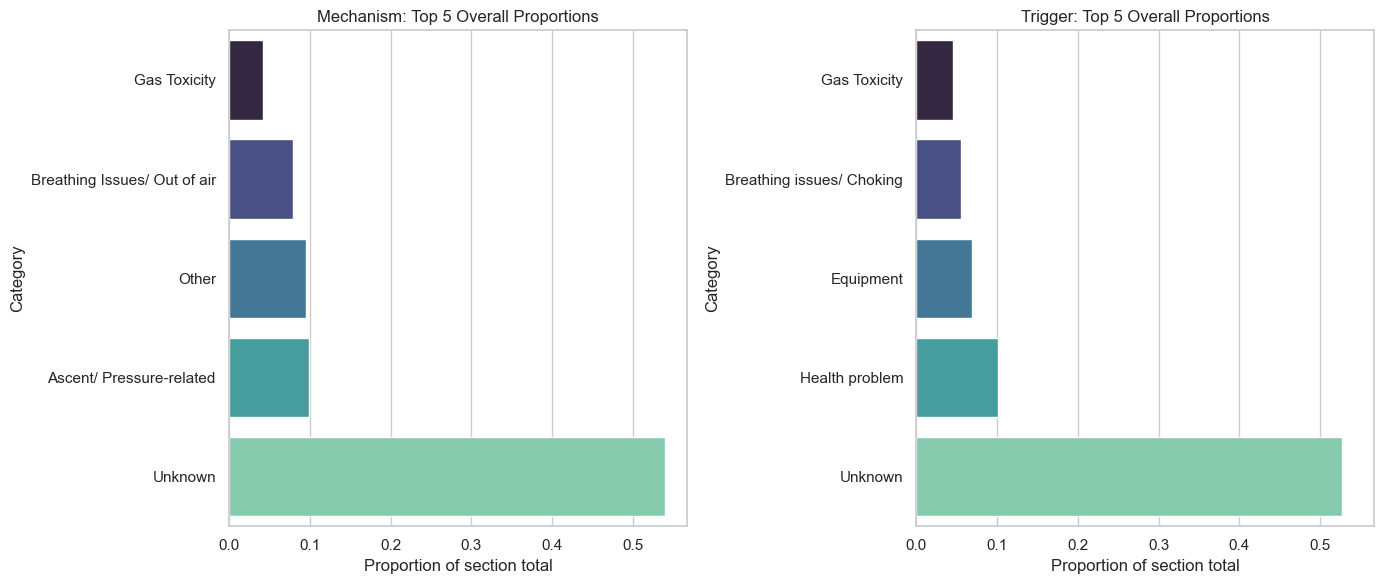

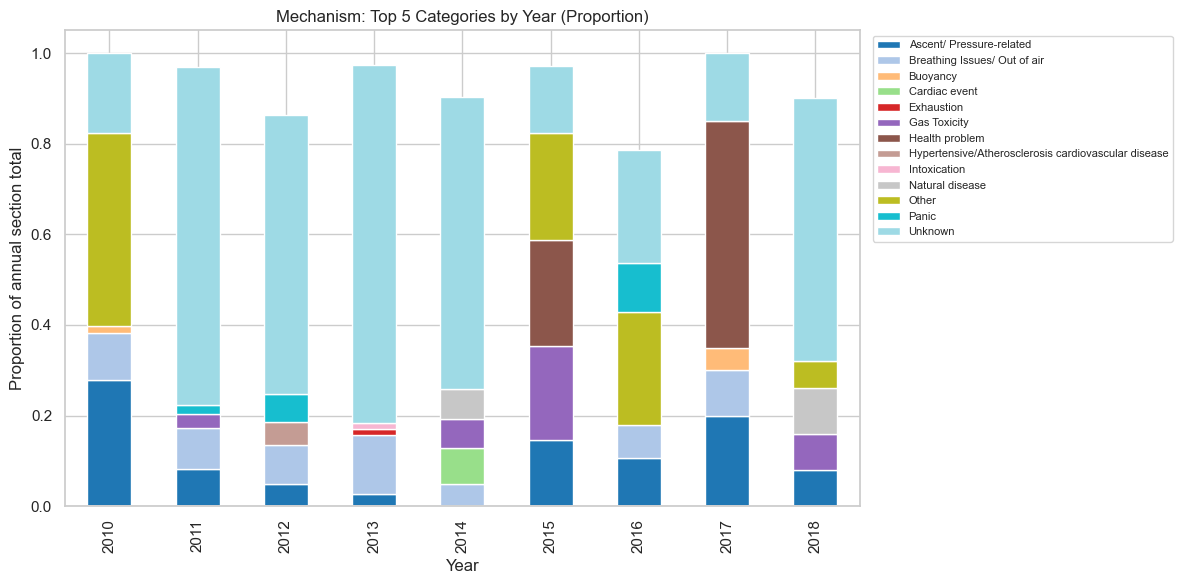

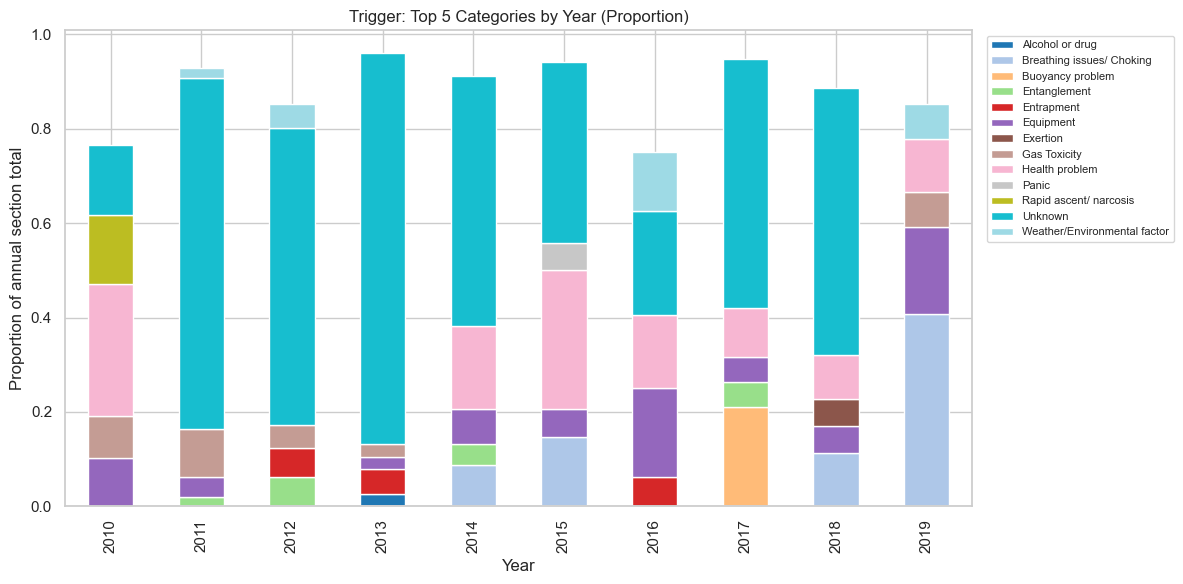

In [10]:
#Trigger + Mechanism analysis in a different cell: top 5 by yearly proportion and overall


## TODO Misspellings need to fix
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def _year_from_value(value):
    if pd.isna(value):
        return None
    if isinstance(value, (int, np.integer)):
        year = int(value)
        return year if 1900 <= year <= 2100 else None
    if isinstance(value, (float, np.floating)) and float(value).is_integer():
        year = int(value)
        return year if 1900 <= year <= 2100 else None
    text = str(value).strip()
    match = re.fullmatch(r"(\d{4})(?:\.0+)?", text)
    if match:
        year = int(match.group(1))
        return year if 1900 <= year <= 2100 else None
    return None

def parse_wide_section_table(df, section_name):
    raw = df.copy().dropna(how="all").reset_index(drop=True)
    raw.columns = [str(c).strip() for c in raw.columns]

    header_idx = None
    year_cols = {}
    for ridx in range(min(12, len(raw))):
        candidate = {}
        for cidx, val in raw.iloc[ridx].items():
            y = _year_from_value(val)
            if y is not None:
                candidate[cidx] = y
        if len(candidate) >= 3:
            header_idx = ridx
            year_cols = candidate
            break

    if header_idx is None:
        raise ValueError(f"Could not detect year header row for {section_name}")

    rows = []
    for ridx in range(header_idx + 1, len(raw)):
        category = raw.iloc[ridx, 0]
        if pd.isna(category):
            continue
        category = str(category).strip()
        if not category or category.lower() in {"total", "nan"}:
            continue
        for cidx, year in year_cols.items():
            value = pd.to_numeric(raw.loc[ridx, cidx], errors="coerce")
            if pd.isna(value):
                continue
            rows.append({
                "section": section_name,
                "category": category,
                "year": int(year),
                "count": float(value),
            })

    out = pd.DataFrame(rows)
    if out.empty:
        raise ValueError(f"No usable rows parsed for {section_name}")
    return out

mechanism_long_2 = parse_wide_section_table(mechanisms, "Mechanism")
trigger_long_2 = parse_wide_section_table(triggers, "Trigger")
tm_long = pd.concat([mechanism_long_2, trigger_long_2], ignore_index=True)

#Yearly proportions
year_totals_tm = tm_long.groupby(["section", "year"], as_index=False)["count"].sum().rename(columns={"count": "year_total"})
tm_year_prop = tm_long.merge(year_totals_tm, on=["section", "year"], how="left")
tm_year_prop["proportion"] = np.where(tm_year_prop["year_total"] > 0, tm_year_prop["count"] / tm_year_prop["year_total"], 0)

top5_yearly = (
    tm_year_prop.sort_values(["section", "year", "proportion"], ascending=[True, True, False])
    .groupby(["section", "year"], as_index=False)
    .head(5)
)
print("Top 5 categories by proportion for each year and section:")
display(top5_yearly[["section", "year", "category", "proportion"]].sort_values(["section", "year", "proportion"], ascending=[True, True, False]))

#Overall proportions
overall_totals_tm = tm_long.groupby("section", as_index=False)["count"].sum().rename(columns={"count": "overall_total"})
tm_overall = tm_long.groupby(["section", "category"], as_index=False)["count"].sum().merge(overall_totals_tm, on="section", how="left")
tm_overall["proportion"] = np.where(tm_overall["overall_total"] > 0, tm_overall["count"] / tm_overall["overall_total"], 0)
top5_overall = tm_overall.sort_values(["section", "proportion"], ascending=[True, False]).groupby("section", as_index=False).head(5)
print("Top 5 categories overall by section:")
display(top5_overall[["section", "category", "proportion"]].sort_values(["section", "proportion"], ascending=[True, False]))

##### TO DO: Remove Unknown and replace with proportions of total for others

## TO DO: clean up visualizations, 

#GRAPH: Overall top 5 proportions for Trigger and Mechanism
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
for i, sec in enumerate(["Mechanism", "Trigger"]):
    sub = top5_overall[top5_overall["section"] == sec].sort_values("proportion", ascending=True)
    sns.barplot(data=sub, x="proportion", y="category", ax=axes[i], palette="mako")
    axes[i].set_title(f"{sec}: Top 5 Overall Proportions")
    axes[i].set_xlabel("Proportion of section total")
    axes[i].set_ylabel("Category")
plt.tight_layout()
plt.show()

#GRAPH: Yearly top 5 proportions (stacked bars)
for sec in ["Mechanism", "Trigger"]:
    sub = top5_yearly[top5_yearly["section"] == sec].copy()
    pivot = sub.pivot_table(index="year", columns="category", values="proportion", aggfunc="sum", fill_value=0).sort_index()
    plt.figure(figsize=(12, 6))
    pivot.plot(kind="bar", stacked=True, ax=plt.gca(), colormap="tab20")
    plt.title(f"{sec}: Top 5 Categories by Year (Proportion)")
    plt.xlabel("Year")
    plt.ylabel("Proportion of annual section total")
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
#### NETWORK ANALYSIS SECTION ---------------------------------------

In [11]:
file_path_network = Path.home() / "Downloads" / "YearbyMechanisms.xlsx"
network_data = pd.read_excel(file_path_network)
print(network_data.head())
print(network_data.info())

   Trigger  Health problem Trigger  Gas Toxicity Trigger  EquipmentTrigger  \
0   2010.0                    19.0                   6.0               7.0   
1   2011.0                     0.0                  10.0               4.0   
2   2012.0                     0.0                   4.0               3.0   
3   2013.0                     0.0                   2.0               2.0   
4   2014.0                    12.0                   1.0               5.0   

   Entrapment  Weather/Environmental factor Trigger  Entanglement Trigger  \
0         1.0                                   4.0                   3.0   
1         1.0                                   2.0                   2.0   
2         5.0                                   4.0                   5.0   
3         4.0                                   1.0                   0.0   
4         1.0                                   1.0                   3.0   

   Rapid ascent Trigger  Panic Trigger  Breathing issues Trigger  ..

In [14]:
trigger_cols = [c for c in network_data.columns if "Trigger" in c]
mech_cols = [c for c in network_data.columns if "Mech" in c]
disable_cols = [c for c in network_data.columns if "Disable" in c]
cod_cols = [c for c in network_data.columns if "Cause" in c or "COD" in c]

network_data["trigger_total"] = network_data[trigger_cols].sum(axis=1)
network_data["disable_total"] = network_data[disable_cols].sum(axis=1)
network_data["mech_total"] = network_data[mech_cols].sum(axis=1)
network_data["cod_total"] = network_data[cod_cols].sum(axis=1)
network_data = network_data.rename(columns={"Trigger": "Year"})

print(network_data[["trigger_total", "disable_total", "mech_total", "cod_total"]])

    trigger_total  disable_total  mech_total  cod_total
0            53.0           49.0        27.0         59
1            23.0           60.0        25.0         66
2            25.0           42.0        29.0         49
3             9.0           28.0        16.0         34
4            30.0           41.0        22.0         44
5            21.0           23.0        21.0         30
6            21.0           24.0        14.0         32
7             9.0           16.0        17.0         19
8            23.0           34.0        18.0         26
9            27.0            0.0         0.0         38
10            0.0            0.0         0.0         79


In [15]:
mech_prop = network_data[mech_cols].div(network_data[mech_cols].sum(axis=1), axis=0)
disable_prop = network_data[disable_cols].div(network_data[disable_cols].sum(axis=1), axis=0)
cod_prop = network_data[cod_cols].div(network_data[cod_cols].sum(axis=1), axis=0)
trigger_prop = network_data[trigger_cols].div(network_data[trigger_cols].sum(axis=1), axis=0)
#proportions

In [16]:

trigger_prop["Year"] = network_data["Year"]
disable_prop["Year"] = network_data["Year"]
mech_prop["Year"] = network_data["Year"]
cod_prop["Year"] = network_data["Year"]

In [22]:
print(network_data.columns)

Index(['Year', 'Health problem Trigger', 'Gas Toxicity Trigger',
       'EquipmentTrigger', 'Entrapment',
       'Weather/Environmental factor Trigger', 'Entanglement Trigger',
       'Rapid ascent Trigger', 'Panic Trigger', 'Breathing issues Trigger',
       'Exertion Trigger', 'Alcohol or drug Trigger', 'Cardiac event Trigger',
       'Inexperience Trigger', 'Buoyancy problem Trigger', 'Cardiac Disable',
       'Drowning/ Asphixia Disable', 'Decompression/Pressure related Disable',
       'Immersion pulmonary edema Disable', 'Loss of consciousness Disable',
       'Seizure Disable', 'Intoxication Disable',
       'Carbon monoxide poisoning Disable', 'Shark bite Disable',
       'Respiratory distress Disable', 'Blunt head trauma Disable',
       'Stroke Disable', 'Other Health Issue Disable', 'Panic Disable',
       'Breathing Issues/ Out of air Mech', 'Panic Mech',
       'Ascent/ Pressure-related Mech', 'Exhaustion Mech',
       'Environmental Mech', 'Intoxication Mech', 'Striking a

In [18]:
#combined triggers cased on categories

###categories Medical, Human Behavior, Equipment, Environmental, Ascent/Buoyancy

network_data["Medical Trigger"] = (
    network_data["Health problem Trigger"] +
    network_data["Cardiac event Trigger"]
)

network_data["Human Behavior Trigger"] = (
    network_data["Panic Trigger"] +
    network_data["Inexperience Trigger"] +
    network_data["Alcohol or drug Trigger"] +
    network_data["Exertion Trigger"]
)

network_data["Equipment Trigger"] = (
    network_data["EquipmentTrigger"] +
    network_data["Breathing issues Trigger"] +
    network_data["Gas Toxicity Trigger"]
) 

network_data["Environmental Trigger"] = (
    network_data["Entrapment"] +
    network_data["Entanglement Trigger"]
)

network_data["Ascent / Buoyancy Trigger"] = (
    network_data["Buoyancy problem Trigger"] +
    network_data["Rapid ascent Trigger"]
)

In [19]:
#combined disabling factors based on categories

###categories Drowning/Respiratory, Cardiovascular/Neurological, Pressure Injury, Environmental, Human

network_data["Drowning / Respiratory Disabling"] = (
    network_data["Respiratory distress Disable"] +
     network_data["Drowning/ Asphixia Disable"] +
     network_data["Immersion pulmonary edema Disable"]
)

network_data["Cardiovascular / Neurological Disabling"] = (
    network_data["Cardiac Disable"] +
    network_data["Stroke Disable"] +
    network_data["Loss of consciousness Disable"] +
    network_data["Seizure Disable"] +
    network_data["Other Health Issue Disable"]
)

network_data["Pressure Injury Disabling"] = (
    network_data["Decompression/Pressure related Disable"]
)
network_data["Environmental Disabling"] = (
    network_data["Blunt head trauma Disable"] +
    network_data["Shark bite Disable"] +
    network_data["Carbon monoxide poisoning Disable"]
    
)
network_data["Human Disabling"] = (
    network_data["Panic Disable"] +
    network_data["Intoxication Disable"]
)

In [20]:
##Mechanism categories: Gas/Breathing, Panic/Human, Pressure/Ascent, Medical, Environmental/Impact
#combined mechanisms based on categories

network_data["Gas / Breathing Mechanism"] = (
    network_data["Breathing Issues/ Out of air Mech"] +
    network_data["Gas Toxicity Mech"]
)

network_data["Human Behavior Mechanism"] = (
    network_data["Panic Mech"] +
    network_data["Exhaustion Mech"] +
    network_data["Intoxication Mech"] 
)
network_data["Pressure / Ascent Mechanism"] = (
    network_data["Ascent/ Pressure-related Mech"] +
    network_data["Buoyancy Mech"]
)
network_data["Medical Mechanism"] = (
    network_data["Health problem Mech"] +
    network_data["Stroke Mech"] +
    network_data["Cardiac event Mech"]
)
network_data["Enviromental / Equipment Mechanism"] = (
    network_data["Environmental Mech"] +
    network_data["Striking an object Mech"] +
    network_data["Entangled Mech"] +
    network_data["Equipment Mech"]
)



In [29]:
#cause of death
##categories Drowning, Cardiac/Heart, Pressure Injury, Trauma/Toxic, Environmental  

network_data["Drowning Cause"] = (
        network_data["Drowning Cause"] +
        network_data["Respiratory issue Cause"] +
        network_data["Immersion pulmonary edema Cause"]
)
network_data["Cardiac/Heart Cause"] = (
    network_data["Cardiac/Heart Issue Cause"]
)
network_data["Pressure Injury Cause"] = (
    network_data["Decompression/Pressure related Cause"]
)
network_data["Trauma / Toxic Cause"] = (
    network_data["Head/brain injury Cause"] +
    network_data["Carbon monoxide poisoning Cause"] +
    network_data["Intoxication Cause"]
)
network_data["Environmental Cause"] = (
    network_data["Shark bite Cause"] +
    network_data["bite venom Cause"] +
    network_data["Entanglement Cause"] +
    network_data["Adverse cons Cause"]
)   

    

In [14]:
# Analysis
import networkx as nx
import numpy as np
import pandas as pd

stage_groups = {
    "Trigger": [
        "Medical Trigger",
        "Human Behavior Trigger",
        "Equipment Trigger",
        "Environmental Trigger",
        "Ascent / Buoyancy Trigger",
    ],
    "Mechanism": [
        "Gas / Breathing Mechanism",
        "Human Behavior Mechanism",
        "Pressure / Ascent Mechanism",
        "Medical Mechanism",
        "Enviromental / Equipment Mechanism",
    ],
    "Disabling": [
        "Drowning / Respiratory Disabling",
        "Cardiovascular / Neurological Disabling",
        "Pressure Injury Disabling",
        "Environmental Disabling",
        "Human Disabling",
    ],
    "Cause": [
        "Drowning Cause",
        "Cardiac/Heart Cause",
        "Pressure Injury Cause",
        "Trauma / Toxic Cause",
        "Environmental Cause",
    ],
}

stage_order = ["Trigger", "Mechanism", "Disabling", "Cause"]
missing_cols = {
    stage: [col for col in cols if col not in network_data.columns]
    for stage, cols in stage_groups.items()
    if any(col not in network_data.columns for col in cols)
}
if missing_cols:
    raise KeyError(f"Missing grouped columns needed for network analysis: {missing_cols}")


def build_stage_share_table(df, cols):
    temp = df[["Year"] + cols].copy()
    temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")
    temp = temp.dropna(subset=["Year"]).copy()
    temp["Year"] = temp["Year"].astype(int)
    temp[cols] = temp[cols].apply(pd.to_numeric, errors="coerce").fillna(0)
    temp = temp.groupby("Year", as_index=False)[cols].sum()
    temp["stage_total"] = temp[cols].sum(axis=1)
    shares = temp[["Year"]].copy()
    denom = temp["stage_total"].replace(0, np.nan)
    for col in cols:
        shares[col] = (temp[col] / denom).fillna(0)
    return shares, temp.set_index("Year")["stage_total"]


stage_share_tables = {}
stage_total_series = {}
for stage, cols in stage_groups.items():
    share_table, total_series = build_stage_share_table(network_data, cols)
    stage_share_tables[stage] = share_table
    stage_total_series[stage] = total_series

print("Trigger stage shares:")
display(stage_share_tables["Trigger"].head())

Trigger stage shares:


,Year,Medical Trigger,Human Behavior Trigger,Equipment Trigger,Environmental Trigger,Ascent / Buoyancy Trigger
0,2010,0.400000,0.040000,0.260000,0.080000,0.220000
1,2011,0.000000,0.136364,0.681818,0.136364,0.045455
2,2012,0.076923,0.230769,0.269231,0.384615,0.038462
3,2013,0.000000,0.250000,0.333333,0.333333,0.083333
4,2014,0.400000,0.066667,0.400000,0.133333,0.000000


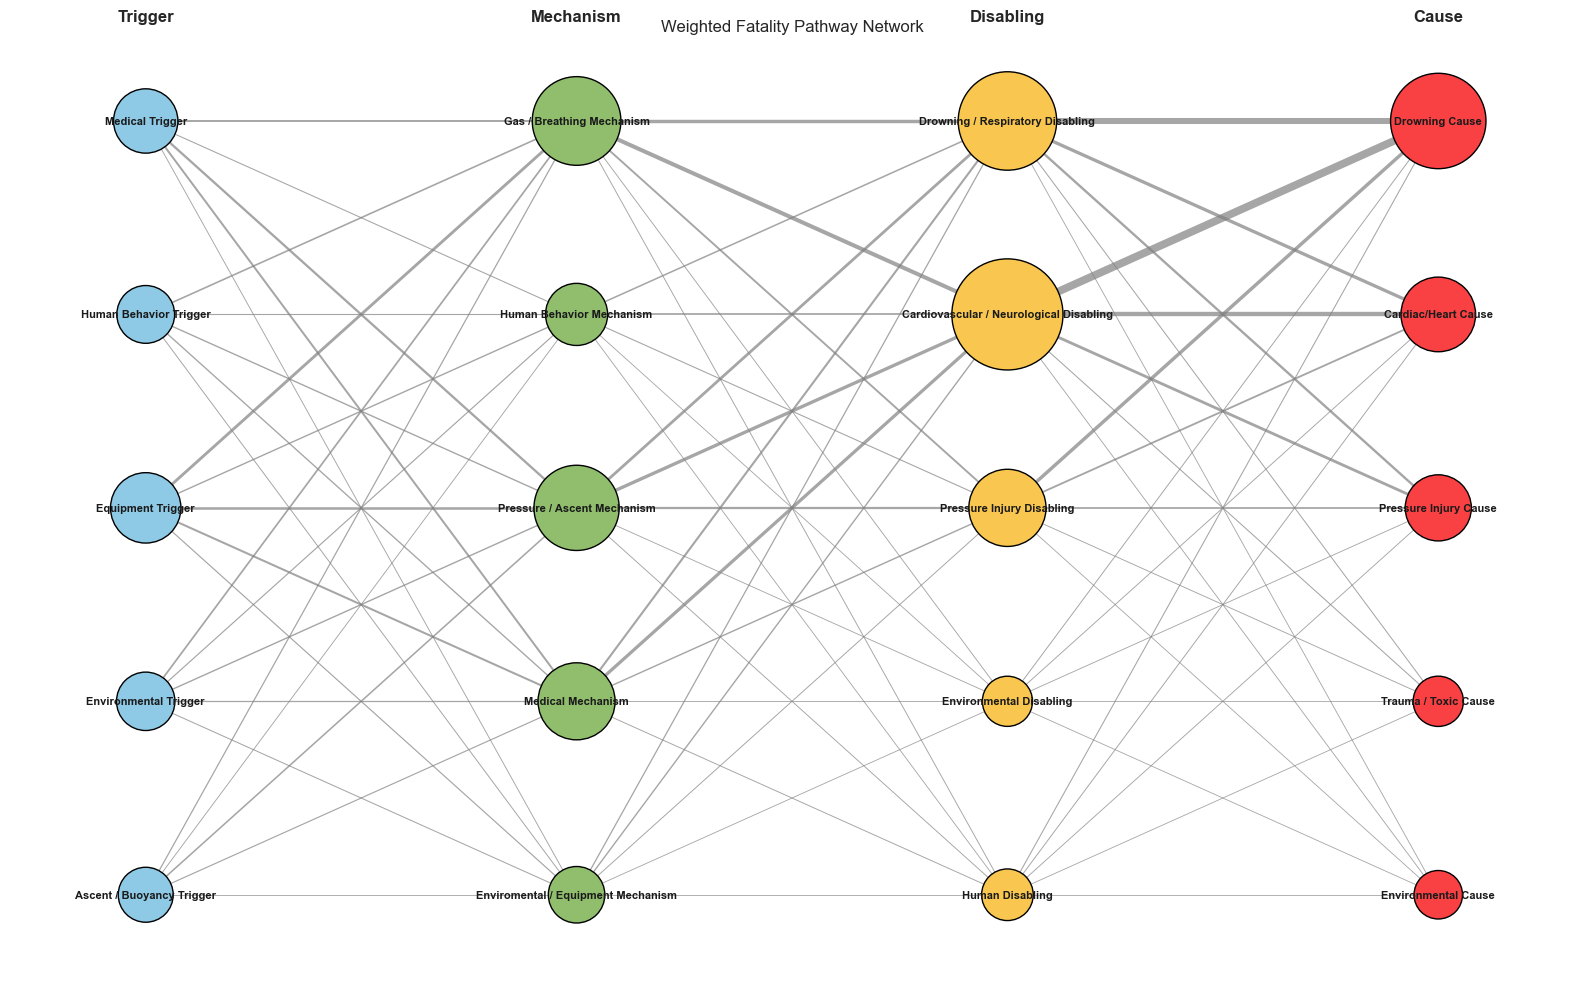

In [31]:
import matplotlib.pyplot as plt

# Layered visualization
plt.figure(figsize=(16, 10))
ax = plt.gca()

stage_x = {"Trigger": 0, "Mechanism": 3, "Disabling": 6, "Cause": 9}
node_pos = {}
for stage, cols in stage_groups.items():
    y_positions = np.linspace(1.0, -1.0, len(cols))
    for y, node in zip(y_positions, cols):
        node_pos[node] = (stage_x[stage], y)

stage_colors = {
    "Trigger": "#8ecae6",
    "Mechanism": "#90be6d",
    "Disabling": "#f9c74f",
    "Cause": "#f94144",
}

strength_lookup = metrics.set_index("node")["strength"].to_dict()
max_strength = max(strength_lookup.values()) if strength_lookup else 1.0

for stage, cols in stage_groups.items():
    nx.draw_networkx_nodes(
        G,
        node_pos,
        nodelist=cols,
        node_color=stage_colors[stage],
        node_size=[1200 + 5200 * (strength_lookup.get(node, 0) / max_strength) for node in cols],
        edgecolors="black",
        linewidths=1.0,
        ax=ax,
    )

nx.draw_networkx_labels(G, node_pos, font_size=8, font_weight="bold", ax=ax)

edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
max_weight = max(edge_weights) if edge_weights else 1.0
widths = [0.6 + 5.0 * (w / max_weight) for w in edge_weights]

nx.draw_networkx_edges(
    G,
    node_pos,
    width=widths,
    edge_color="gray",
    alpha=0.7,
    arrows=False,
    ax=ax,
)

for stage, x in stage_x.items():
    ax.text(x, 1.25, stage, ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_title("Weighted Fatality Pathway Network")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [32]:
##NODES AND EDGES METRICS

from networkx.algorithms.community import greedy_modularity_communities

# Build edges first
def build_layer_edges(source_stage, target_stage):
    source_cols = stage_groups[source_stage]
    target_cols = stage_groups[target_stage]

    source = stage_share_tables[source_stage].set_index("Year")
    target = stage_share_tables[target_stage].set_index("Year")
    years = sorted(set(source.index).intersection(target.index))

    rows = []
    for year in years:
        srow = source.loc[year, source_cols]
        trow = target.loc[year, target_cols]
        source_scale = float(stage_total_series[source_stage].loc[year])
        target_scale = float(stage_total_series[target_stage].loc[year])
        pair_scale = (source_scale + target_scale) / 2.0

        if pair_scale <= 0:
            continue

        for source_node in source_cols:
            for target_node in target_cols:
                weight = float(srow[source_node]) * float(trow[target_node]) * pair_scale
                if weight > 0:
                    rows.append(
                        {
                            "source": source_node,
                            "target": target_node,
                            "weight": weight,
                            "year": year,
                            "stage_pair": f"{source_stage} → {target_stage}",
                        }
                    )

    return pd.DataFrame(rows)


edge_df_parts = [
    build_layer_edges("Trigger", "Mechanism"),
    build_layer_edges("Mechanism", "Disabling"),
    build_layer_edges("Disabling", "Cause"),
]

edge_df = pd.concat(edge_df_parts, ignore_index=True)
edge_df = (
    edge_df.groupby(["source", "target", "stage_pair"], as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=False)
)

# Now build the graph
G = nx.DiGraph()
for _, row in edge_df.iterrows():
    G.add_edge(row["source"], row["target"], weight=float(row["weight"]))

node_stage = {
    node: stage
    for stage, cols in stage_groups.items()
    for node in cols
}
nx.set_node_attributes(G, node_stage, "stage")

metrics = pd.DataFrame({"node": list(G.nodes())})
metrics["stage"] = metrics["node"].map(node_stage)
metrics["in_strength"] = metrics["node"].apply(
    lambda node: sum(data["weight"] for _, _, data in G.in_edges(node, data=True))
)
metrics["out_strength"] = metrics["node"].apply(
    lambda node: sum(data["weight"] for _, _, data in G.out_edges(node, data=True))
)
metrics["strength"] = metrics["in_strength"] + metrics["out_strength"]

if G.number_of_edges() > 0:
    metrics["pagerank"] = metrics["node"].map(nx.pagerank(G, weight="weight"))
    undirected_G = G.to_undirected()
    distance_G = undirected_G.copy()
    for u, v, data in distance_G.edges(data=True):
        data["distance"] = 1.0 / data["weight"] if data["weight"] > 0 else 1.0
    metrics["betweenness"] = metrics["node"].map(
        nx.betweenness_centrality(distance_G, weight="distance")
    )
    communities = list(greedy_modularity_communities(undirected_G, weight="weight"))
    community_lookup = {
        node: f"C{i + 1}"
        for i, community in enumerate(communities)
        for node in community
    }
    metrics["community"] = metrics["node"].map(community_lookup)
else:
    metrics["pagerank"] = 0
    metrics["betweenness"] = 0
    metrics["community"] = None

metrics = metrics.sort_values(["stage", "strength"], ascending=[True, False])

###NODE METRICS
print("Node metrics:")
display(metrics)
#Top nodes by PAGERANK
print("Top nodes by PageRank")
display(metrics.sort_values("pagerank", ascending=False).head(10))

#TOP PATHWAY EDGES
print("Top pathway edges:")
display(edge_df.head(15))

Node metrics:


,node,stage,in_strength,out_strength,strength,pagerank,betweenness,community
1,Drowning Cause,Cause,201.136188,0.000000,201.136188,0.173310,0.315789,C2
3,Cardiac/Heart Cause,Cause,89.132048,0.000000,89.132048,0.091551,0.000000,C2
10,Pressure Injury Cause,Cause,40.947327,0.000000,40.947327,0.053723,0.000000,C2
17,Trauma / Toxic Cause,Cause,5.829891,0.000000,5.829891,0.027579,0.000000,C2
19,Environmental Cause,Cause,0.954545,0.000000,0.954545,0.023986,0.000000,C2
0,Cardiovascular / Neurological Disabling,Disabling,117.979730,156.510060,274.489790,0.109204,0.742690,C2
2,Drowning / Respiratory Disabling,Disabling,85.755022,116.087518,201.842539,0.085534,0.000000,C2
5,Pressure Injury Disabling,Disabling,42.637335,56.970893,99.608229,0.052734,0.000000,C2
16,Human Disabling,Disabling,4.306049,5.261610,9.567659,0.026300,0.000000,C1
18,Environmental Disabling,Disabling,2.321864,3.169919,5.491783,0.025036,0.000000,C1


Top nodes by PageRank


,node,stage,in_strength,out_strength,strength,pagerank,betweenness,community
1,Drowning Cause,Cause,201.136188,0.000000,201.136188,0.173310,0.315789,C2
0,Cardiovascular / Neurological Disabling,Disabling,117.979730,156.510060,274.489790,0.109204,0.742690,C2
3,Cardiac/Heart Cause,Cause,89.132048,0.000000,89.132048,0.091551,0.000000,C2
2,Drowning / Respiratory Disabling,Disabling,85.755022,116.087518,201.842539,0.085534,0.000000,C2
4,Gas / Breathing Mechanism,Mechanism,64.917411,86.851976,151.769387,0.054938,0.245614,C1
6,Pressure / Ascent Mechanism,Mechanism,61.741010,73.643023,135.384033,0.054632,0.181287,C1
10,Pressure Injury Cause,Cause,40.947327,0.000000,40.947327,0.053723,0.000000,C2
5,Pressure Injury Disabling,Disabling,42.637335,56.970893,99.608229,0.052734,0.000000,C2
7,Medical Mechanism,Mechanism,44.677536,54.435046,99.112582,0.044943,0.000000,C1
11,Human Behavior Mechanism,Mechanism,18.315550,23.909442,42.224992,0.032329,0.000000,C1


Top pathway edges:


,source,target,stage_pair,weight
6,Cardiovascular / Neurological Disabling,Drowning Cause,Disabling → Cause,92.432598
11,Drowning / Respiratory Disabling,Drowning Cause,Disabling → Cause,69.802676
5,Cardiovascular / Neurological Disabling,Cardiac/Heart Cause,Disabling → Cause,43.568995
35,Gas / Breathing Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,39.445442
71,Pressure Injury Disabling,Drowning Cause,Disabling → Cause,34.119713
36,Gas / Breathing Mechanism,Drowning / Respiratory Disabling,Mechanism → Disabling,31.958941
65,Pressure / Ascent Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,30.662706
10,Drowning / Respiratory Disabling,Cardiac/Heart Cause,Disabling → Cause,30.366526
55,Medical Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,29.576789
31,Equipment Trigger,Gas / Breathing Mechanism,Trigger → Mechanism,25.183379


In [33]:
#PATHWAYS

def build_layer_edges(source_stage, target_stage):
    source_cols = stage_groups[source_stage]
    target_cols = stage_groups[target_stage]

    source = stage_share_tables[source_stage].set_index("Year")
    target = stage_share_tables[target_stage].set_index("Year")
    years = sorted(set(source.index).intersection(target.index))

    rows = []
    for year in years:
        srow = source.loc[year, source_cols]
        trow = target.loc[year, target_cols]
        source_scale = float(stage_total_series[source_stage].loc[year])
        target_scale = float(stage_total_series[target_stage].loc[year])
        pair_scale = (source_scale + target_scale) / 2.0

        if pair_scale <= 0:
            continue

        for source_node in source_cols:
            for target_node in target_cols:
                weight = float(srow[source_node]) * float(trow[target_node]) * pair_scale
                if weight > 0:
                    rows.append(
                        {
                            "source": source_node,
                            "target": target_node,
                            "weight": weight,
                            "year": year,
                            "stage_pair": f"{source_stage} → {target_stage}",
                        }
                    )

    return pd.DataFrame(rows)


edge_df_parts = [
    build_layer_edges("Trigger", "Mechanism"),
    build_layer_edges("Mechanism", "Disabling"),
    build_layer_edges("Disabling", "Cause"),
]

edge_df = pd.concat(edge_df_parts, ignore_index=True)
edge_df = (
    edge_df.groupby(["source", "target", "stage_pair"], as_index=False)["weight"]
    .sum()
    .sort_values("weight", ascending=False)
)

#TOP PATHWAY EDGES
display(edge_df.head(15))

,source,target,stage_pair,weight
6,Cardiovascular / Neurological Disabling,Drowning Cause,Disabling → Cause,92.432598
11,Drowning / Respiratory Disabling,Drowning Cause,Disabling → Cause,69.802676
5,Cardiovascular / Neurological Disabling,Cardiac/Heart Cause,Disabling → Cause,43.568995
35,Gas / Breathing Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,39.445442
71,Pressure Injury Disabling,Drowning Cause,Disabling → Cause,34.119713
36,Gas / Breathing Mechanism,Drowning / Respiratory Disabling,Mechanism → Disabling,31.958941
65,Pressure / Ascent Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,30.662706
10,Drowning / Respiratory Disabling,Cardiac/Heart Cause,Disabling → Cause,30.366526
55,Medical Mechanism,Cardiovascular / Neurological Disabling,Mechanism → Disabling,29.576789
31,Equipment Trigger,Gas / Breathing Mechanism,Trigger → Mechanism,25.183379


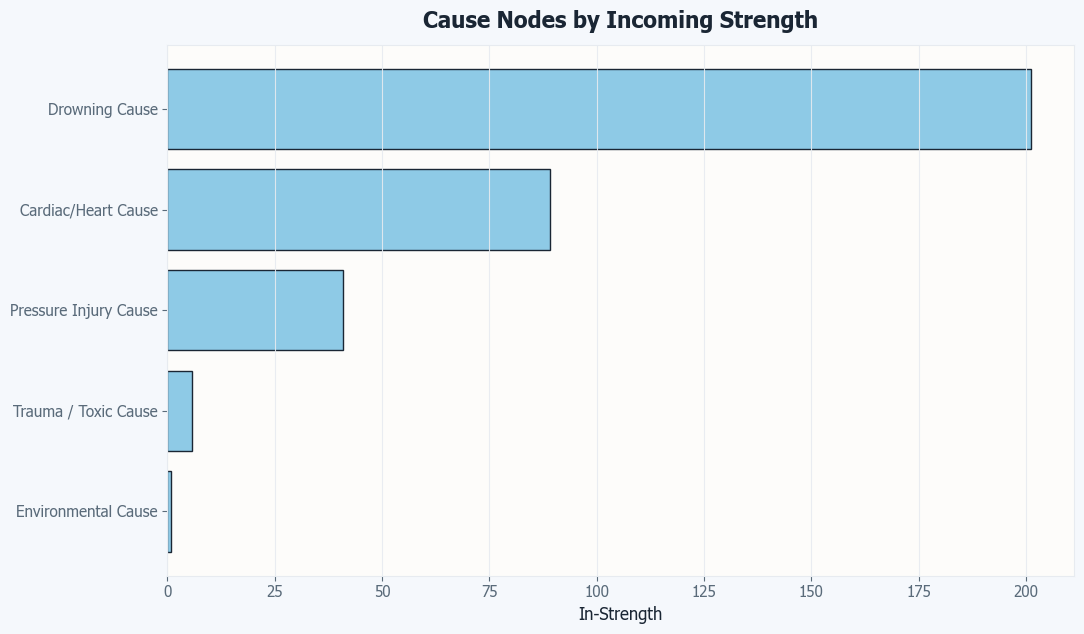

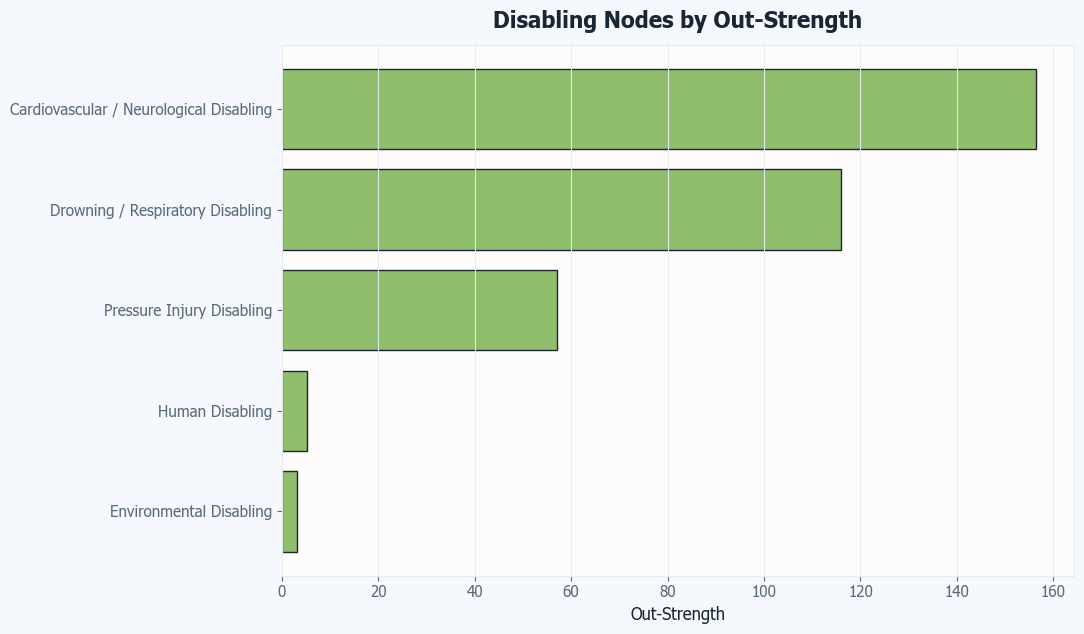

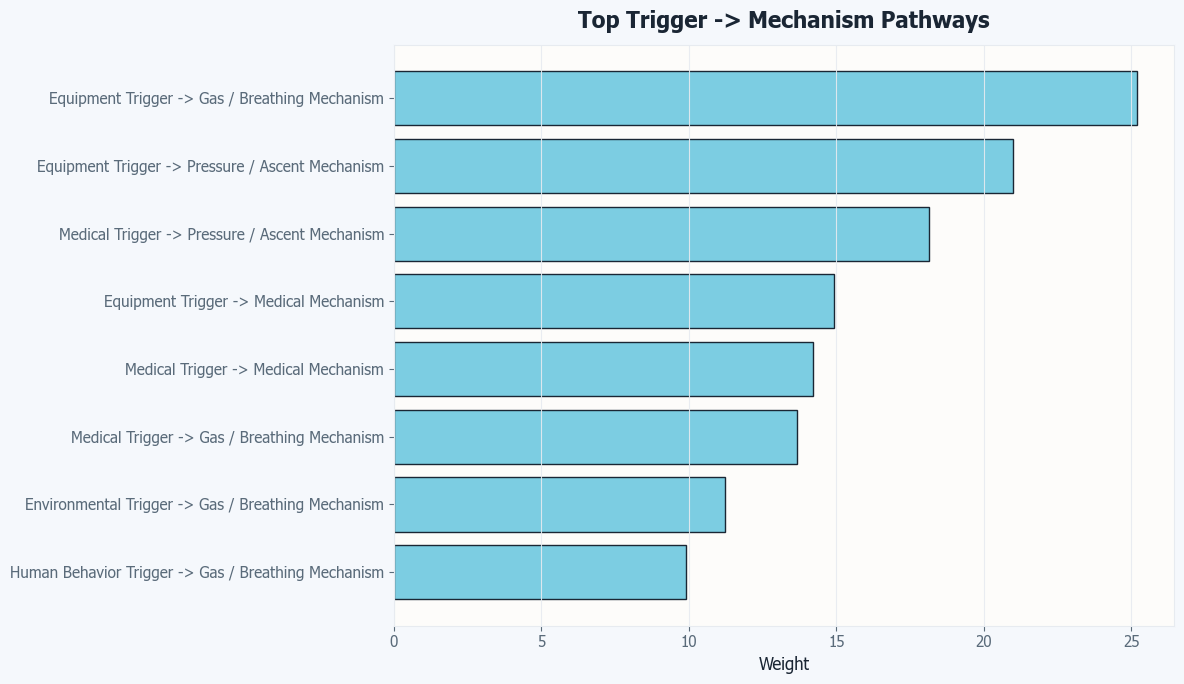

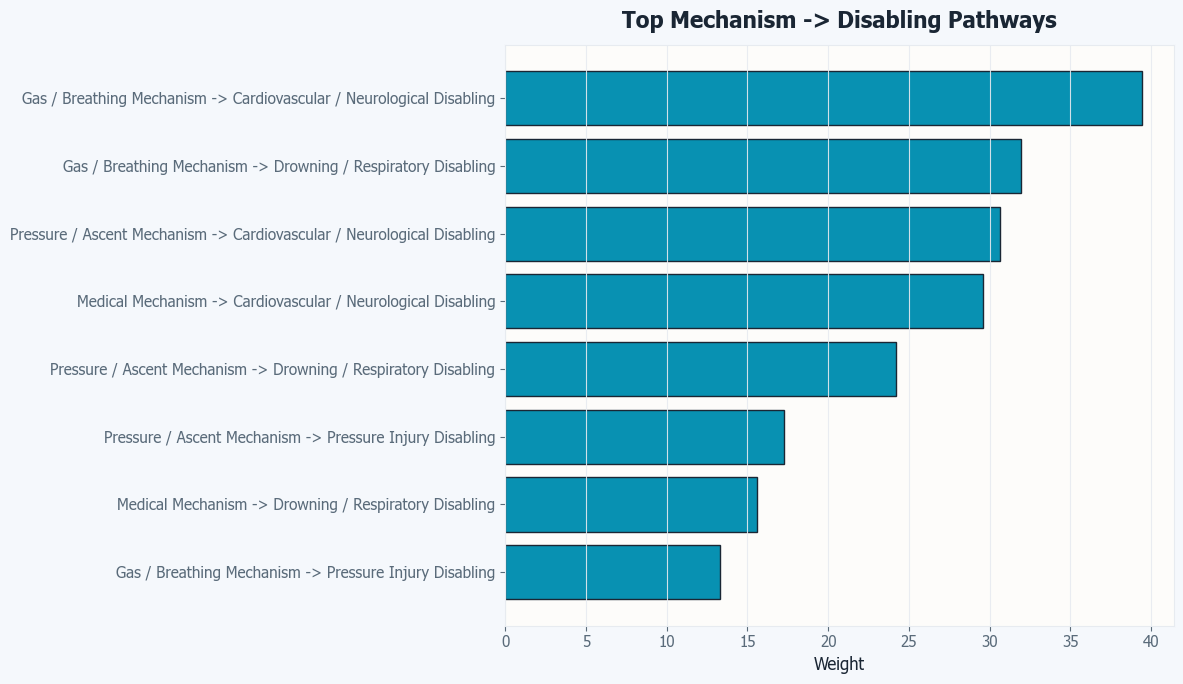

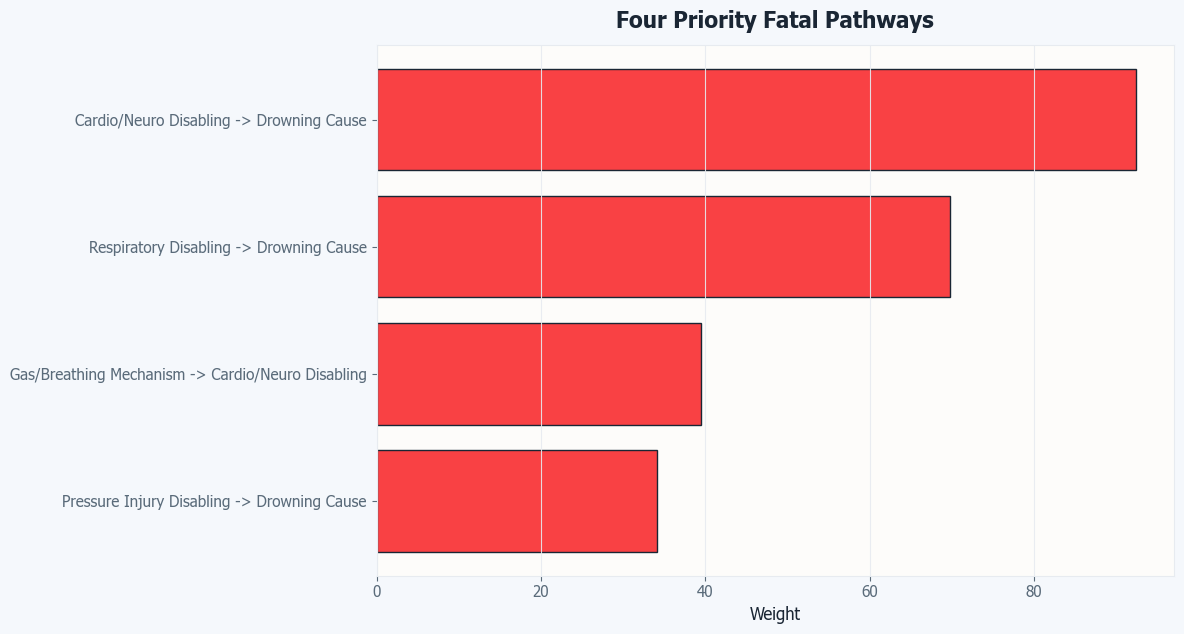

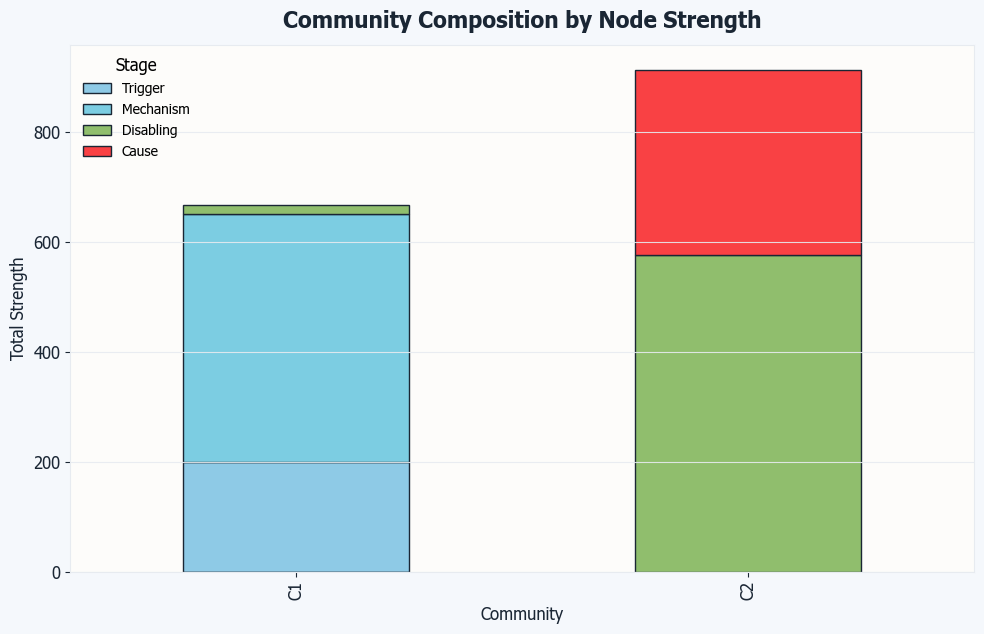

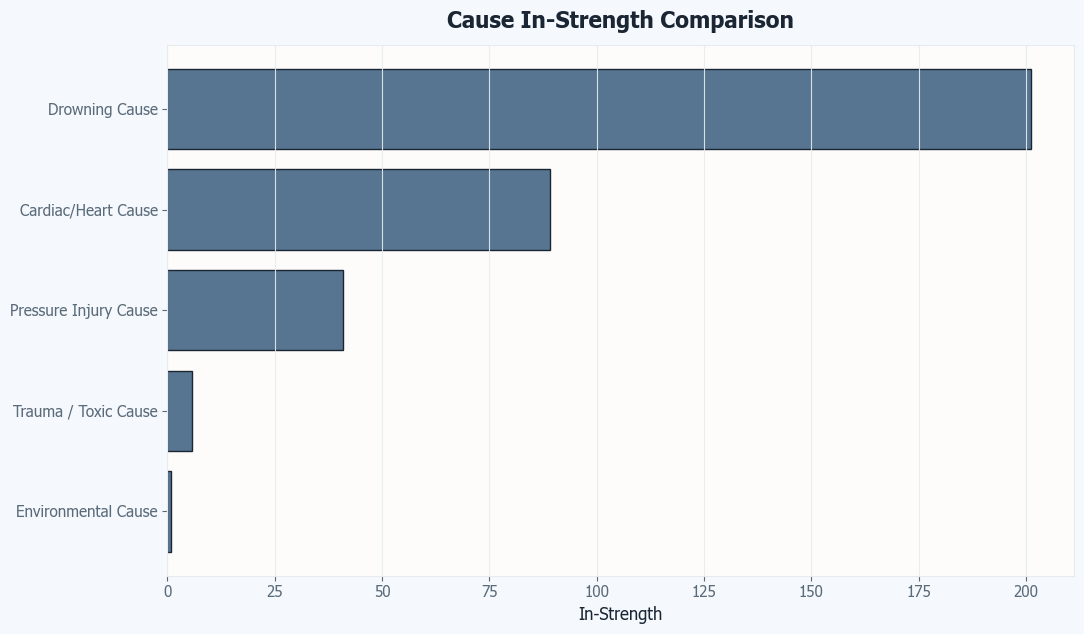

,stage_pair,path,weight
6,Disabling → Cause,Cardiovascular / Neurological Disabling -> Dro...,92.432598
11,Disabling → Cause,Drowning / Respiratory Disabling -> Drowning C...,69.802676
5,Disabling → Cause,Cardiovascular / Neurological Disabling -> Car...,43.568995
35,Mechanism → Disabling,Gas / Breathing Mechanism -> Cardiovascular / ...,39.445442
71,Disabling → Cause,Pressure Injury Disabling -> Drowning Cause,34.119713
36,Mechanism → Disabling,Gas / Breathing Mechanism -> Drowning / Respir...,31.958941
65,Mechanism → Disabling,Pressure / Ascent Mechanism -> Cardiovascular ...,30.662706
10,Disabling → Cause,Drowning / Respiratory Disabling -> Cardiac/He...,30.366526
55,Mechanism → Disabling,Medical Mechanism -> Cardiovascular / Neurolog...,29.576789
31,Trigger → Mechanism,Equipment Trigger -> Gas / Breathing Mechanism,25.183379


Exported chart images to: /Users/mirandagrein/Documents/final project/figures/network-analysis


In [7]:
# ADDITIONAL VISUALIZATIONS TO SUPPORT NETWORK FINDINGS (keeps existing node viz unchanged)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
from networkx.algorithms.community import greedy_modularity_communities

# ------------------------------------------------------------------
# Index-style theme + export helpers
# ------------------------------------------------------------------
THEME = {
    "bg": "#f5f8fc",
    "panel": "#fdfcfa",
    "panel_soft": "#fbfbf7",
    "line": "#e7ebf0",
    "text": "#1a2634",
    "muted": "#5a6b7a",
    "accent": "#0891b2",
    "accent_soft": "#dff4fb",
    "trigger": "#8ecae6",
    "mechanism": "#7ccde2",
    "disabling": "#90be6d",
    "cause": "#f94144",
    "alt": "#577590",
}

plt.rcParams.update({
    "figure.facecolor": THEME["bg"],
    "axes.facecolor": THEME["panel"],
    "axes.edgecolor": THEME["line"],
    "axes.labelcolor": THEME["text"],
    "axes.titlecolor": THEME["text"],
    "xtick.color": THEME["text"],
    "ytick.color": THEME["text"],
    "font.size": 12,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Tahoma", "Geneva", "Verdana", "Arial", "DejaVu Sans"],
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
})

# Saves to project-level folder used by findings.html
export_dir = Path.cwd() / "figures" / "network-analysis"
export_dir.mkdir(parents=True, exist_ok=True)


def save_and_show(fig, filename):
    fig.savefig(export_dir / filename, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


def style_axis(ax, xlabel="", ylabel=""):
    ax.set_xlabel(xlabel, color=THEME["text"])
    ax.set_ylabel(ylabel, color=THEME["text"])
    ax.tick_params(axis="both", colors=THEME["muted"], labelsize=11)
    ax.grid(axis="x", color=THEME["line"], alpha=0.9, linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_color(THEME["line"])


# ------------------------------------------------------------------
# Robust setup: load/build what is needed if user runs this cell alone
# ------------------------------------------------------------------
if "network_data" not in globals():
    file_path_network = Path.home() / "Downloads" / "YearbyMechanisms.xlsx"
    if not file_path_network.exists():
        raise RuntimeError("Could not find YearbyMechanisms.xlsx in Downloads.")
    network_data = pd.read_excel(file_path_network)

if "Year" not in network_data.columns and "Trigger" in network_data.columns:
    network_data = network_data.rename(columns={"Trigger": "Year"})


def safe_sum(df, cols):
    present = [c for c in cols if c in df.columns]
    if not present:
        return pd.Series(0, index=df.index, dtype=float)
    return df[present].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)


def ensure_grouped_columns(df):
    if "Medical Trigger" not in df.columns:
        df["Medical Trigger"] = safe_sum(df, ["Health problem Trigger", "Cardiac event Trigger"])
    if "Human Behavior Trigger" not in df.columns:
        df["Human Behavior Trigger"] = safe_sum(df, [
            "Panic Trigger", "Inexperience Trigger", "Alcohol or drug Trigger", "Exertion Trigger"
        ])
    if "Equipment Trigger" not in df.columns:
        df["Equipment Trigger"] = safe_sum(df, ["EquipmentTrigger", "Breathing issues Trigger", "Gas Toxicity Trigger"])
    if "Environmental Trigger" not in df.columns:
        df["Environmental Trigger"] = safe_sum(df, ["Entrapment", "Entanglement Trigger"])
    if "Ascent / Buoyancy Trigger" not in df.columns:
        df["Ascent / Buoyancy Trigger"] = safe_sum(df, ["Buoyancy problem Trigger", "Rapid ascent Trigger"])

    if "Gas / Breathing Mechanism" not in df.columns:
        df["Gas / Breathing Mechanism"] = safe_sum(df, ["Breathing Issues/ Out of air Mech", "Gas Toxicity Mech"])
    if "Human Behavior Mechanism" not in df.columns:
        df["Human Behavior Mechanism"] = safe_sum(df, ["Panic Mech", "Exhaustion Mech", "Intoxication Mech"])
    if "Pressure / Ascent Mechanism" not in df.columns:
        df["Pressure / Ascent Mechanism"] = safe_sum(df, ["Ascent/ Pressure-related Mech", "Buoyancy Mech"])
    if "Medical Mechanism" not in df.columns:
        df["Medical Mechanism"] = safe_sum(df, ["Health problem Mech", "Stroke Mech", "Cardiac event Mech"])
    if "Enviromental / Equipment Mechanism" not in df.columns:
        df["Enviromental / Equipment Mechanism"] = safe_sum(df, ["Environmental Mech", "Striking an object Mech", "Entangled Mech", "Equipment Mech"])

    if "Drowning / Respiratory Disabling" not in df.columns:
        df["Drowning / Respiratory Disabling"] = safe_sum(df, ["Respiratory distress Disable", "Drowning/ Asphixia Disable", "Immersion pulmonary edema Disable"])
    if "Cardiovascular / Neurological Disabling" not in df.columns:
        df["Cardiovascular / Neurological Disabling"] = safe_sum(df, ["Cardiac Disable", "Stroke Disable", "Loss of consciousness Disable", "Seizure Disable", "Other Health Issue Disable"])
    if "Pressure Injury Disabling" not in df.columns:
        df["Pressure Injury Disabling"] = safe_sum(df, ["Decompression/Pressure related Disable"])
    if "Environmental Disabling" not in df.columns:
        df["Environmental Disabling"] = safe_sum(df, ["Blunt head trauma Disable", "Shark bite Disable", "Carbon monoxide poisoning Disable"])
    if "Human Disabling" not in df.columns:
        df["Human Disabling"] = safe_sum(df, ["Panic Disable", "Intoxication Disable"])

    if "Drowning Cause" not in df.columns or "Respiratory issue Cause" in df.columns:
        drowning_base = pd.to_numeric(df.get("Drowning Cause", 0), errors="coerce").fillna(0)
        df["Drowning Cause"] = drowning_base + safe_sum(df, ["Respiratory issue Cause", "Immersion pulmonary edema Cause"])
    if "Cardiac/Heart Cause" not in df.columns:
        df["Cardiac/Heart Cause"] = safe_sum(df, ["Cardiac/Heart Issue Cause"])
    if "Pressure Injury Cause" not in df.columns:
        df["Pressure Injury Cause"] = safe_sum(df, ["Decompression/Pressure related Cause"])
    if "Trauma / Toxic Cause" not in df.columns:
        df["Trauma / Toxic Cause"] = safe_sum(df, ["Head/brain injury Cause", "Carbon monoxide poisoning Cause", "Intoxication Cause"])
    if "Environmental Cause" not in df.columns:
        df["Environmental Cause"] = safe_sum(df, ["Shark bite Cause", "bite venom Cause", "Entanglement Cause", "Adverse cons Cause"])


ensure_grouped_columns(network_data)

if "stage_groups" not in globals():
    stage_groups = {
        "Trigger": [
            "Medical Trigger",
            "Human Behavior Trigger",
            "Equipment Trigger",
            "Environmental Trigger",
            "Ascent / Buoyancy Trigger",
        ],
        "Mechanism": [
            "Gas / Breathing Mechanism",
            "Human Behavior Mechanism",
            "Pressure / Ascent Mechanism",
            "Medical Mechanism",
            "Enviromental / Equipment Mechanism",
        ],
        "Disabling": [
            "Drowning / Respiratory Disabling",
            "Cardiovascular / Neurological Disabling",
            "Pressure Injury Disabling",
            "Environmental Disabling",
            "Human Disabling",
        ],
        "Cause": [
            "Drowning Cause",
            "Cardiac/Heart Cause",
            "Pressure Injury Cause",
            "Trauma / Toxic Cause",
            "Environmental Cause",
        ],
    }

if "metrics" not in globals() or "edge_df" not in globals():
    missing_cols = {
        stage: [col for col in cols if col not in network_data.columns]
        for stage, cols in stage_groups.items()
        if any(col not in network_data.columns for col in cols)
    }
    if missing_cols:
        raise RuntimeError(f"Missing grouped columns in network_data: {missing_cols}")

    def build_stage_share_table(df, cols):
        temp = df[["Year"] + cols].copy()
        temp["Year"] = pd.to_numeric(temp["Year"], errors="coerce")
        temp = temp.dropna(subset=["Year"]).copy()
        temp["Year"] = temp["Year"].astype(int)
        temp[cols] = temp[cols].apply(pd.to_numeric, errors="coerce").fillna(0)
        temp = temp.groupby("Year", as_index=False)[cols].sum()
        temp["stage_total"] = temp[cols].sum(axis=1)
        shares = temp[["Year"]].copy()
        denom = temp["stage_total"].replace(0, np.nan)
        for col in cols:
            shares[col] = (temp[col] / denom).fillna(0)
        return shares, temp.set_index("Year")["stage_total"]

    stage_share_tables = {}
    stage_total_series = {}
    for stage, cols in stage_groups.items():
        share_table, total_series = build_stage_share_table(network_data, cols)
        stage_share_tables[stage] = share_table
        stage_total_series[stage] = total_series

    def build_layer_edges(source_stage, target_stage):
        source_cols = stage_groups[source_stage]
        target_cols = stage_groups[target_stage]

        source = stage_share_tables[source_stage].set_index("Year")
        target = stage_share_tables[target_stage].set_index("Year")
        years = sorted(set(source.index).intersection(target.index))

        rows = []
        for year in years:
            srow = source.loc[year, source_cols]
            trow = target.loc[year, target_cols]
            source_scale = float(stage_total_series[source_stage].loc[year])
            target_scale = float(stage_total_series[target_stage].loc[year])
            pair_scale = (source_scale + target_scale) / 2.0

            if pair_scale <= 0:
                continue

            for source_node in source_cols:
                for target_node in target_cols:
                    weight = float(srow[source_node]) * float(trow[target_node]) * pair_scale
                    if weight > 0:
                        rows.append(
                            {
                                "source": source_node,
                                "target": target_node,
                                "weight": weight,
                                "year": year,
                                "stage_pair": f"{source_stage} → {target_stage}",
                            }
                        )

        return pd.DataFrame(rows)

    edge_df_parts = [
        build_layer_edges("Trigger", "Mechanism"),
        build_layer_edges("Mechanism", "Disabling"),
        build_layer_edges("Disabling", "Cause"),
    ]
    edge_df = pd.concat(edge_df_parts, ignore_index=True)
    edge_df = (
        edge_df.groupby(["source", "target", "stage_pair"], as_index=False)["weight"]
        .sum()
        .sort_values("weight", ascending=False)
    )

    G = nx.DiGraph()
    for _, row in edge_df.iterrows():
        G.add_edge(row["source"], row["target"], weight=float(row["weight"]))

    node_stage = {node: stage for stage, cols in stage_groups.items() for node in cols}
    nx.set_node_attributes(G, node_stage, "stage")

    metrics = pd.DataFrame({"node": list(G.nodes())})
    metrics["stage"] = metrics["node"].map(node_stage)
    metrics["in_strength"] = metrics["node"].apply(
        lambda node: sum(data["weight"] for _, _, data in G.in_edges(node, data=True))
    )
    metrics["out_strength"] = metrics["node"].apply(
        lambda node: sum(data["weight"] for _, _, data in G.out_edges(node, data=True))
    )
    metrics["strength"] = metrics["in_strength"] + metrics["out_strength"]

    if G.number_of_edges() > 0:
        metrics["pagerank"] = metrics["node"].map(nx.pagerank(G, weight="weight"))
        undirected_G = G.to_undirected()
        distance_G = undirected_G.copy()
        for u, v, data in distance_G.edges(data=True):
            data["distance"] = 1.0 / data["weight"] if data["weight"] > 0 else 1.0
        metrics["betweenness"] = metrics["node"].map(nx.betweenness_centrality(distance_G, weight="distance"))
        communities = list(greedy_modularity_communities(undirected_G, weight="weight"))
        community_lookup = {node: f"C{i + 1}" for i, community in enumerate(communities) for node in community}
        metrics["community"] = metrics["node"].map(community_lookup)
    else:
        metrics["pagerank"] = 0
        metrics["betweenness"] = 0
        metrics["community"] = None

# -----------------------------
# Separate Figures (one chart per picture)
# -----------------------------

cause_strength = (
    metrics.loc[metrics["stage"] == "Cause", ["node", "in_strength"]]
    .sort_values("in_strength", ascending=True)
)
fig = plt.figure(figsize=(11, 6.5))
ax = fig.add_subplot(111)
ax.barh(cause_strength["node"], cause_strength["in_strength"], color=THEME["trigger"], edgecolor=THEME["text"])
ax.set_title("Cause Nodes by Incoming Strength", pad=12, color=THEME["text"])
style_axis(ax, xlabel="In-Strength")
plt.tight_layout()
save_and_show(fig, "01_cause_nodes_incoming_strength.png")

disabling_out = (
    metrics.loc[metrics["stage"] == "Disabling", ["node", "out_strength"]]
    .sort_values("out_strength", ascending=True)
)
fig = plt.figure(figsize=(11, 6.5))
ax = fig.add_subplot(111)
ax.barh(disabling_out["node"], disabling_out["out_strength"], color=THEME["disabling"], edgecolor=THEME["text"])
ax.set_title("Disabling Nodes by Out-Strength", pad=12, color=THEME["text"])
style_axis(ax, xlabel="Out-Strength")
plt.tight_layout()
save_and_show(fig, "02_disabling_nodes_out_strength.png")

tm = edge_df[edge_df["stage_pair"] == "Trigger → Mechanism"].copy()
tm["path"] = tm["source"] + " -> " + tm["target"]
top_tm = tm.sort_values("weight", ascending=False).head(8).sort_values("weight", ascending=True)
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111)
ax.barh(top_tm["path"], top_tm["weight"], color=THEME["mechanism"], edgecolor=THEME["text"])
ax.set_title("Top Trigger -> Mechanism Pathways", pad=12, color=THEME["text"])
style_axis(ax, xlabel="Weight")
plt.tight_layout()
save_and_show(fig, "03_top_trigger_to_mechanism_pathways.png")

md = edge_df[edge_df["stage_pair"] == "Mechanism → Disabling"].copy()
md["path"] = md["source"] + " -> " + md["target"]
top_md = md.sort_values("weight", ascending=False).head(8).sort_values("weight", ascending=True)
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111)
ax.barh(top_md["path"], top_md["weight"], color=THEME["accent"], edgecolor=THEME["text"])
ax.set_title("Top Mechanism -> Disabling Pathways", pad=12, color=THEME["text"])
style_axis(ax, xlabel="Weight")
plt.tight_layout()
save_and_show(fig, "04_top_mechanism_to_disabling_pathways.png")


def edge_weight_lookup(df, source, target):
    hit = df[(df["source"] == source) & (df["target"] == target)]
    return float(hit["weight"].sum()) if not hit.empty else 0.0

priority_pathways = {
    "Cardio/Neuro Disabling -> Drowning Cause": edge_weight_lookup(edge_df, "Cardiovascular / Neurological Disabling", "Drowning Cause"),
    "Respiratory Disabling -> Drowning Cause": edge_weight_lookup(edge_df, "Drowning / Respiratory Disabling", "Drowning Cause"),
    "Gas/Breathing Mechanism -> Cardio/Neuro Disabling": edge_weight_lookup(edge_df, "Gas / Breathing Mechanism", "Cardiovascular / Neurological Disabling"),
    "Pressure Injury Disabling -> Drowning Cause": edge_weight_lookup(edge_df, "Pressure Injury Disabling", "Drowning Cause"),
}

pp = pd.Series(priority_pathways).sort_values(ascending=True)
fig = plt.figure(figsize=(12, 6.5))
ax = fig.add_subplot(111)
ax.barh(pp.index, pp.values, color=THEME["cause"], edgecolor=THEME["text"])
ax.set_title("Four Priority Fatal Pathways", pad=12, color=THEME["text"])
style_axis(ax, xlabel="Weight")
plt.tight_layout()
save_and_show(fig, "05_four_priority_fatal_pathways.png")

if "community" in metrics.columns and metrics["community"].notna().any():
    community_stage_strength = (
        metrics.groupby(["community", "stage"], as_index=False)["strength"]
        .sum()
        .pivot(index="community", columns="stage", values="strength")
        .fillna(0)
    )
    stage_cols = [c for c in ["Trigger", "Mechanism", "Disabling", "Cause"] if c in community_stage_strength.columns]
    community_stage_strength = community_stage_strength[stage_cols]

    fig = plt.figure(figsize=(10, 6.5))
    ax = fig.add_subplot(111)
    community_stage_strength.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[THEME["trigger"], THEME["mechanism"], THEME["disabling"], THEME["cause"]][:len(stage_cols)],
        edgecolor=THEME["text"],
    )
    ax.set_title("Community Composition by Node Strength", pad=12, color=THEME["text"])
    ax.set_xlabel("Community", color=THEME["text"])
    ax.set_ylabel("Total Strength", color=THEME["text"])
    ax.grid(axis="y", color=THEME["line"], alpha=0.9, linewidth=0.8)
    ax.legend(title="Stage", fontsize=10, frameon=False)
    for spine in ax.spines.values():
        spine.set_color(THEME["line"])
    plt.tight_layout()
    save_and_show(fig, "06_community_composition_by_strength.png")

cause_compare = (
    metrics.loc[metrics["stage"] == "Cause", ["node", "in_strength"]]
    .sort_values("in_strength", ascending=True)
)
fig = plt.figure(figsize=(11, 6.5))
ax = fig.add_subplot(111)
ax.barh(cause_compare["node"], cause_compare["in_strength"], color=THEME["alt"], edgecolor=THEME["text"])
ax.set_title("Cause In-Strength Comparison", pad=12, color=THEME["text"])
style_axis(ax, xlabel="In-Strength")
plt.tight_layout()
save_and_show(fig, "07_cause_in_strength_comparison.png")

edge_df_display = edge_df.copy()
edge_df_display["path"] = edge_df_display["source"] + " -> " + edge_df_display["target"]
display(edge_df_display[["stage_pair", "path", "weight"]].head(20))

print(f"Exported chart images to: {export_dir}")

Intervention simulation results:


,intervention,edge,reduction_level,baseline_drowning_in,new_drowning_in,absolute_reduction,pct_reduction
0,Cardio/Neuro Disabling -> Drowning Cause,Cardiovascular / Neurological Disabling -> Dro...,30%,201.136188,173.406408,27.729779,13.786569
1,Respiratory Disabling -> Drowning Cause,Drowning / Respiratory Disabling -> Drowning C...,30%,201.136188,180.195385,20.940803,10.411256
2,Cardio/Neuro Disabling -> Drowning Cause,Cardiovascular / Neurological Disabling -> Dro...,20%,201.136188,182.649668,18.486520,9.191046
3,Respiratory Disabling -> Drowning Cause,Drowning / Respiratory Disabling -> Drowning C...,20%,201.136188,187.175652,13.960535,6.940837
4,Pressure Injury Disabling -> Drowning Cause,Pressure Injury Disabling -> Drowning Cause,30%,201.136188,190.900274,10.235914,5.089046
5,Cardio/Neuro Disabling -> Drowning Cause,Cardiovascular / Neurological Disabling -> Dro...,10%,201.136188,191.892928,9.243260,4.595523
6,Respiratory Disabling -> Drowning Cause,Drowning / Respiratory Disabling -> Drowning C...,10%,201.136188,194.155920,6.980268,3.470419
7,Pressure Injury Disabling -> Drowning Cause,Pressure Injury Disabling -> Drowning Cause,20%,201.136188,194.312245,6.823943,3.392698
8,Pressure Injury Disabling -> Drowning Cause,Pressure Injury Disabling -> Drowning Cause,10%,201.136188,197.724216,3.411971,1.696349
9,Equipment -> Gas/Breathing,Equipment Trigger -> Gas / Breathing Mechanism,10%,201.136188,201.136188,0.000000,0.000000



20% reduction scenario ranking:


,intervention,pct_reduction,absolute_reduction,new_drowning_in
0,Cardio/Neuro Disabling -> Drowning Cause,9.191046,18.486520,182.649668
1,Respiratory Disabling -> Drowning Cause,6.940837,13.960535,187.175652
2,Pressure Injury Disabling -> Drowning Cause,3.392698,6.823943,194.312245
3,Equipment -> Gas/Breathing,0.000000,0.000000,201.136188
4,Gas/Breathing -> Cardio/Neuro Disabling,0.000000,0.000000,201.136188



Percent reduction in Drowning Cause by intervention level:


reduction_level,10%,20%,30%
intervention,,,
Cardio/Neuro Disabling -> Drowning Cause,4.595523,9.191046,13.786569
Equipment -> Gas/Breathing,0.000000,0.000000,0.000000
Gas/Breathing -> Cardio/Neuro Disabling,0.000000,0.000000,0.000000
Pressure Injury Disabling -> Drowning Cause,1.696349,3.392698,5.089046
Respiratory Disabling -> Drowning Cause,3.470419,6.940837,10.411256


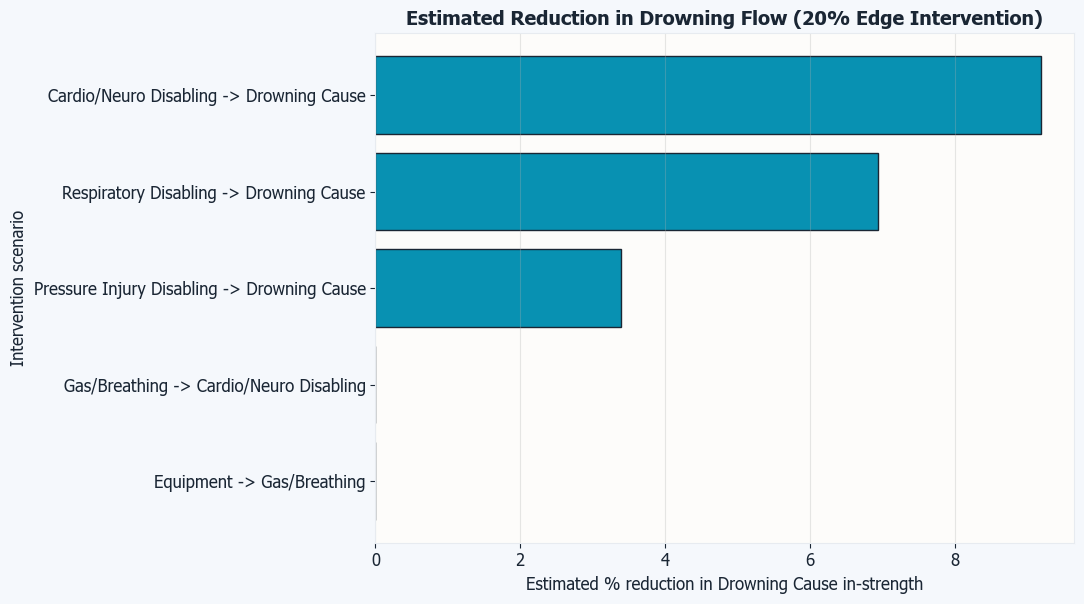


Top simulated intervention: Cardio/Neuro Disabling -> Drowning Cause at 30% -> 13.79% estimated reduction in Drowning Cause flow.
Exported figure: /Users/mirandagrein/Documents/final project/figures/network-analysis/08_intervention_impact_simulation_20pct.png


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if "edge_df" not in globals():
    raise RuntimeError("`edge_df` is not available. Run the network-analysis cells above first.")

required_edges = [
    ("Equipment Trigger", "Gas / Breathing Mechanism", "Equipment -> Gas/Breathing"),
    ("Gas / Breathing Mechanism", "Cardiovascular / Neurological Disabling", "Gas/Breathing -> Cardio/Neuro Disabling"),
    ("Cardiovascular / Neurological Disabling", "Drowning Cause", "Cardio/Neuro Disabling -> Drowning Cause"),
    ("Drowning / Respiratory Disabling", "Drowning Cause", "Respiratory Disabling -> Drowning Cause"),
    ("Pressure Injury Disabling", "Drowning Cause", "Pressure Injury Disabling -> Drowning Cause"),
]

baseline_drowning_in = float(edge_df.loc[edge_df["target"] == "Drowning Cause", "weight"].sum())
if baseline_drowning_in <= 0:
    raise RuntimeError("Baseline flow into Drowning Cause is zero; check `edge_df` construction.")

reduction_levels = [0.10, 0.20, 0.30]
results = []

for source, target, label in required_edges:
    edge_exists = ((edge_df["source"] == source) & (edge_df["target"] == target)).any()
    if not edge_exists:
        print(f"Warning: edge not found and skipped: {source} -> {target}")
        continue

    for reduction in reduction_levels:
        simulated = edge_df.copy()
        mask = (simulated["source"] == source) & (simulated["target"] == target)
        simulated.loc[mask, "weight"] = simulated.loc[mask, "weight"] * (1 - reduction)

        new_drowning_in = float(simulated.loc[simulated["target"] == "Drowning Cause", "weight"].sum())
        absolute_reduction = baseline_drowning_in - new_drowning_in
        pct_reduction = (absolute_reduction / baseline_drowning_in) * 100

        results.append({
            "intervention": label,
            "edge": f"{source} -> {target}",
            "reduction_level": f"{int(reduction*100)}%",
            "baseline_drowning_in": baseline_drowning_in,
            "new_drowning_in": new_drowning_in,
            "absolute_reduction": absolute_reduction,
            "pct_reduction": pct_reduction,
        })

impact_df = pd.DataFrame(results)
if impact_df.empty:
    raise RuntimeError("No valid intervention edges found in `edge_df`.")

impact_df = impact_df.sort_values(["pct_reduction", "intervention"], ascending=[False, True]).reset_index(drop=True)

print("Intervention simulation results:")
display(impact_df)

summary_20 = (
    impact_df[impact_df["reduction_level"] == "20%"]
    .sort_values("pct_reduction", ascending=False)
    .reset_index(drop=True)
)

print("\n20% reduction scenario ranking:")
display(summary_20[["intervention", "pct_reduction", "absolute_reduction", "new_drowning_in"]])

pivot = impact_df.pivot_table(index="intervention", columns="reduction_level", values="pct_reduction", aggfunc="mean")
print("\nPercent reduction in Drowning Cause by intervention level:")
display(pivot)

fig, ax = plt.subplots(figsize=(11, 6.2))
plot_data = summary_20.sort_values("pct_reduction", ascending=True)
ax.barh(plot_data["intervention"], plot_data["pct_reduction"], color="#0891b2", edgecolor="#1a2634")
ax.set_title("Estimated Reduction in Drowning Flow (20% Edge Intervention)", fontsize=14, fontweight="bold")
ax.set_xlabel("Estimated % reduction in Drowning Cause in-strength")
ax.set_ylabel("Intervention scenario")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

export_dir = Path.cwd() / "figures" / "network-analysis"
export_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(export_dir / "08_intervention_impact_simulation_20pct.png", dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())

best_row = impact_df.iloc[0]
print(
    f"\nTop simulated intervention: {best_row['intervention']} at {best_row['reduction_level']} "
    f"-> {best_row['pct_reduction']:.2f}% estimated reduction in Drowning Cause flow."
)
print(f"Exported figure: {export_dir / '08_intervention_impact_simulation_20pct.png'}")

In [19]:
from pathlib import Path
import pandas as pd

downloads = Path.home() / "Downloads"
candidates = [
    downloads / "medicalcondition.xlsl",
    downloads / "medicalcondition.xlsx",
    downloads / "medicalcondition.xls",
]


medical_conditions = pd.read_excel(medical_file)

display(medical_conditions.head(10))

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,Condition,2016,2014,2015,2010,2011,2012,2013
1,Hypertension,3,4,2,12,12,11,5
2,Diabetes,2,1,2,3,6,5,1
3,Flu/cold,1,0,0,2,0,0,0
4,Back Pain,1,1,0,0,3,1,1
5,Ear/sinus,1,0,0,1,0,0,0
6,Cardiovascular disease,0,3,2,2,7,7,2
7,Seasickness,0,1,0,0,0,0,0
8,Pulmonary,0,2,0,0,2,1,0
9,Asthma,0,1,0,3,0,4,1


Cleaned medical conditions long format:


,Condition,year,count
0,Hypertension,2016,3
1,Diabetes,2016,2
2,Flu/cold,2016,1
3,Back Pain,2016,1
4,Ear/sinus,2016,1
5,Cardiovascular disease,2016,0
6,Seasickness,2016,0
7,Pulmonary,2016,0
8,Asthma,2016,0
9,Depression,2016,0


Top conditions overall:


,Condition,count
8,Hypertension,49
3,Cardiovascular disease,23
5,Diabetes,20
1,Asthma,9
2,Back Pain,7
10,Pulmonary,5
4,Depression,4
0,Allergies,3
7,Flu/cold,3
6,Ear/sinus,2


Conditions increasing fastest (by slope):


,Condition,start_year,end_year,start_count,end_count,abs_change,pct_change,slope_per_year,total_count
11,Seasickness,2010.0,2016.0,0.0,0.0,0.0,NaN,3.571429e-02,1
6,Ear/sinus,2010.0,2016.0,1.0,1.0,0.0,0.000000,4.218729e-15,2
4,Depression,2010.0,2016.0,1.0,0.0,-1.0,-100.000000,-3.571429e-02,4
2,Back Pain,2010.0,2016.0,0.0,1.0,1.0,NaN,-1.071429e-01,7
7,Flu/cold,2010.0,2016.0,2.0,1.0,-1.0,-50.000000,-1.071429e-01,3
9,Nervous System,2010.0,2016.0,0.0,0.0,0.0,NaN,-1.071429e-01,2
10,Pulmonary,2010.0,2016.0,0.0,0.0,0.0,NaN,-1.071429e-01,5
0,Allergies,2010.0,2016.0,1.0,0.0,-1.0,-100.000000,-1.428571e-01,3
1,Asthma,2010.0,2016.0,3.0,0.0,-3.0,-100.000000,-4.285714e-01,9
5,Diabetes,2010.0,2016.0,3.0,2.0,-1.0,-33.333333,-5.357143e-01,20


Conditions decreasing fastest (by slope):


,Condition,start_year,end_year,start_count,end_count,abs_change,pct_change,slope_per_year,total_count
8,Hypertension,2010.0,2016.0,12.0,3.0,-9.0,-75.000000,-1.928571,49
3,Cardiovascular disease,2010.0,2016.0,2.0,0.0,-2.0,-100.000000,-0.714286,23
5,Diabetes,2010.0,2016.0,3.0,2.0,-1.0,-33.333333,-0.535714,20
1,Asthma,2010.0,2016.0,3.0,0.0,-3.0,-100.000000,-0.428571,9
0,Allergies,2010.0,2016.0,1.0,0.0,-1.0,-100.000000,-0.142857,3
10,Pulmonary,2010.0,2016.0,0.0,0.0,0.0,NaN,-0.107143,5
9,Nervous System,2010.0,2016.0,0.0,0.0,0.0,NaN,-0.107143,2
7,Flu/cold,2010.0,2016.0,2.0,1.0,-1.0,-50.000000,-0.107143,3
2,Back Pain,2010.0,2016.0,0.0,1.0,1.0,NaN,-0.107143,7
4,Depression,2010.0,2016.0,1.0,0.0,-1.0,-100.000000,-0.035714,4


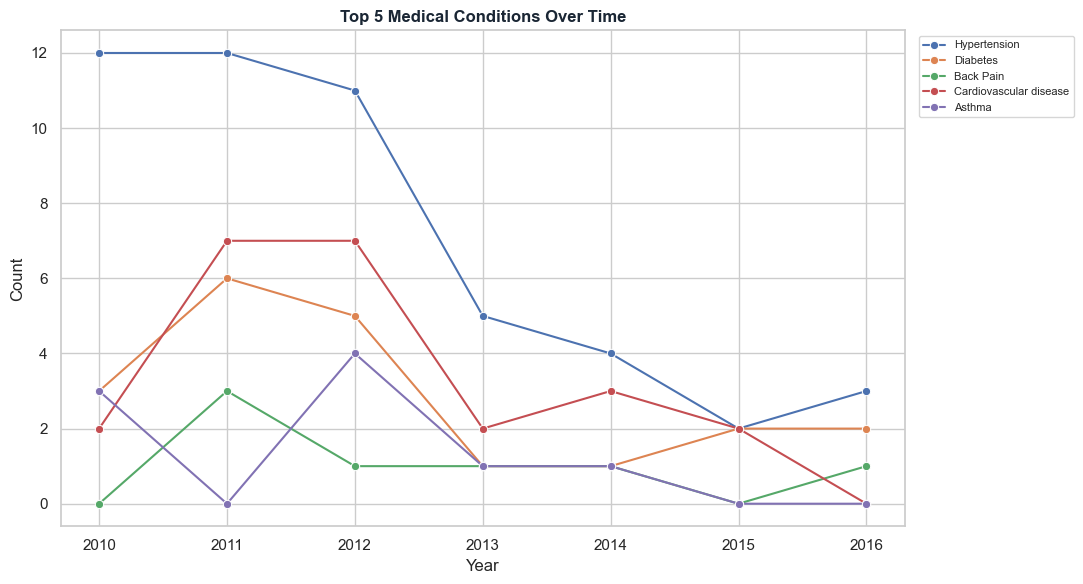

Year-level cross analysis (all medical conditions vs total fatalities):


,year,medical_total,total_fatalities,medical_per_100_fatalities
0,2010,25,117.0,21.367521
1,2011,32,157.0,20.382166
2,2012,31,161.0,19.254658
3,2013,11,127.0,8.661417
4,2014,13,143.0,9.090909
5,2015,8,130.0,6.153846
6,2016,8,169.0,4.733728


Average condition burden per 100 fatalities (across years):


,Condition,condition_per_100_fatalities
8,Hypertension,4.968549
3,Cardiovascular disease,2.246713
5,Diabetes,1.957135
1,Asthma,0.933611
2,Back Pain,0.658623
10,Pulmonary,0.470515
4,Depression,0.432872
7,Flu/cold,0.328731
0,Allergies,0.323317
6,Ear/sinus,0.206631


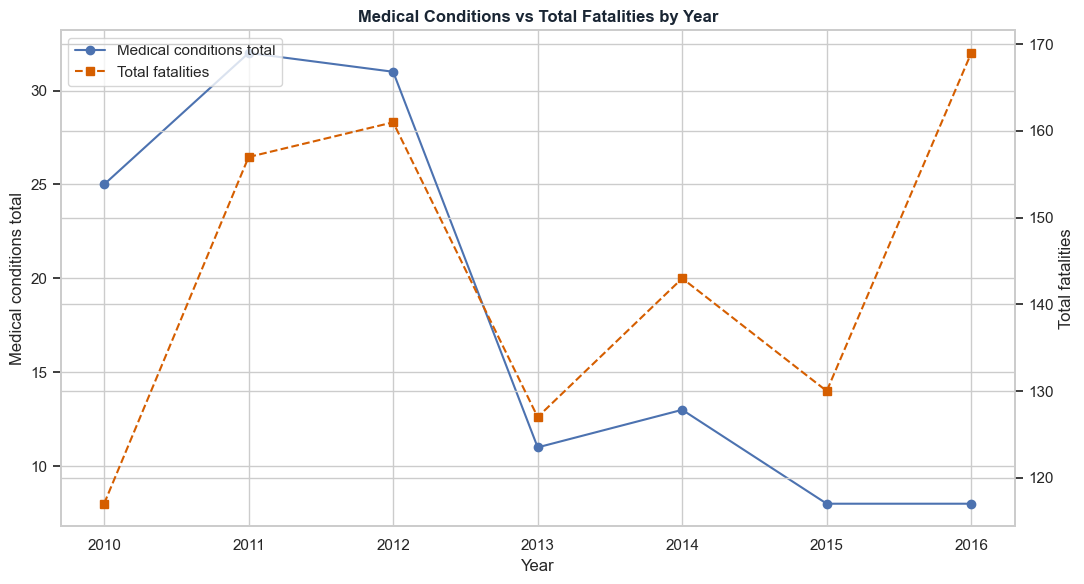

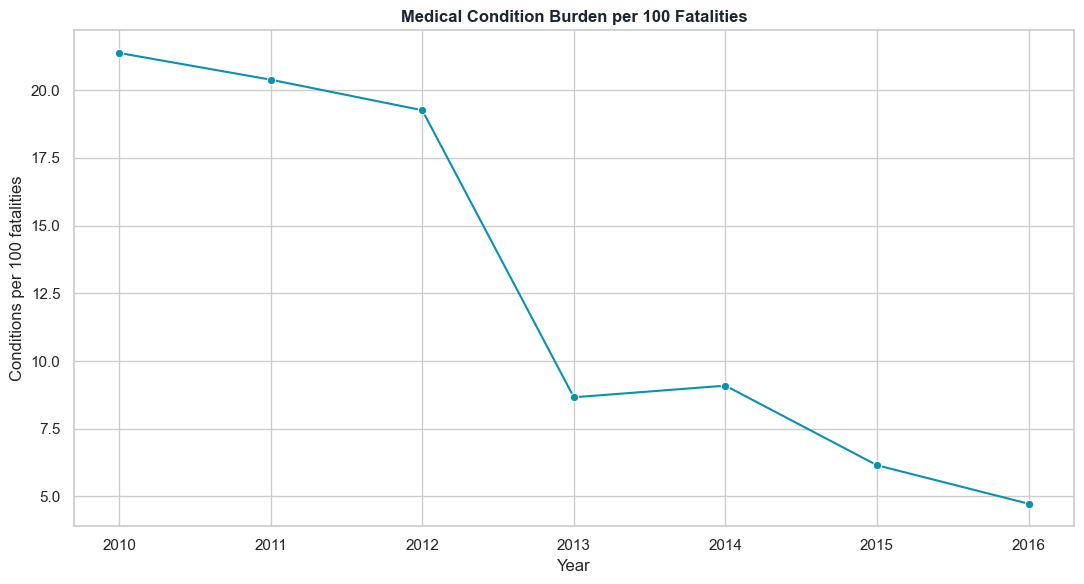

In [20]:
#Medical conditions: clean + trend analysis + cross analysis with yearly fatalities
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "medical_conditions" not in globals():
    raise RuntimeError("`medical_conditions` is not available. Run the medical file load cell first.")


mc_raw = medical_conditions.copy()
mc_raw = mc_raw.dropna(how="all").reset_index(drop=True)

if all(str(c).startswith("Unnamed") for c in mc_raw.columns):
    new_header = mc_raw.iloc[0].astype(str).str.strip().tolist()
    mc = mc_raw.iloc[1:].copy().reset_index(drop=True)
    mc.columns = new_header
else:
    mc = mc_raw.copy()

mc.columns = [str(c).strip() for c in mc.columns]
mc = mc.rename(columns={mc.columns[0]: "Condition"})
mc["Condition"] = mc["Condition"].astype(str).str.strip()

year_cols = [c for c in mc.columns if re.fullmatch(r"\d{4}", str(c).strip())]
if not year_cols:
    # fallback: detect year-like labels
    year_cols = []
    for c in mc.columns:
        m = re.search(r"(19\d{2}|20\d{2})", str(c))
        if m:
            year_cols.append(c)
    if year_cols:
        mc = mc.rename(columns={c: re.search(r"(19\d{2}|20\d{2})", str(c)).group(1) for c in year_cols})
        year_cols = [re.search(r"(19\d{2}|20\d{2})", str(c)).group(1) for c in year_cols]

if not year_cols:
    raise ValueError(f"No year columns found in medical conditions table. Columns: {list(mc.columns)}")

medical_long = mc.melt(
    id_vars=["Condition"],
    value_vars=year_cols,
    var_name="year",
    value_name="count",
)
medical_long["year"] = pd.to_numeric(medical_long["year"], errors="coerce").astype("Int64")
medical_long["count"] = pd.to_numeric(medical_long["count"], errors="coerce").fillna(0)
medical_long = medical_long.dropna(subset=["year"]).copy()
medical_long["year"] = medical_long["year"].astype(int)
medical_long = medical_long[medical_long["Condition"].str.lower().ne("total")].copy()

print("Cleaned medical conditions long format:")
display(medical_long.head(12))

# Trend analsysi
condition_totals = (
    medical_long.groupby("Condition", as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
)
print("Top conditions overall:")
display(condition_totals.head(10))

med_year_total = medical_long.groupby("year", as_index=False)["count"].sum().rename(columns={"count": "medical_total"})
medical_share = medical_long.merge(med_year_total, on="year", how="left")
medical_share["share_of_medical_total"] = np.where(
    medical_share["medical_total"] > 0,
    medical_share["count"] / medical_share["medical_total"],
    0,
    )

def _condition_trend(group):
    group = group.sort_values("year")
    x = group["year"].to_numpy()
    y = group["count"].to_numpy(dtype=float)
    if len(group) >= 2 and np.unique(x).size >= 2:
        slope = float(np.polyfit(x, y, 1)[0])
    else:
        slope = np.nan
    start = float(y[0])
    end = float(y[-1])
    abs_change = end - start
    pct_change = (abs_change / start * 100) if start != 0 else np.nan
    return pd.Series({
        "start_year": int(x[0]),
        "end_year": int(x[-1]),
        "start_count": start,
        "end_count": end,
        "abs_change": abs_change,
        "pct_change": pct_change,
        "slope_per_year": slope,
    })

condition_trends = (
    medical_long.groupby("Condition", as_index=False)
    .apply(_condition_trend, include_groups=False)
    .reset_index(drop=True)
    .merge(condition_totals, on="Condition", how="left")
    .rename(columns={"count": "total_count"})
)

print("Conditions increasing fastest (by slope):")
display(condition_trends.sort_values("slope_per_year", ascending=False).head(10))

print("Conditions decreasing fastest (by slope):")
display(condition_trends.sort_values("slope_per_year", ascending=True).head(10))

# Trend chart for top 5 total conditions
top5_conditions = condition_totals.head(5)["Condition"].tolist()
top5_med = medical_long[medical_long["Condition"].isin(top5_conditions)].copy()

plt.figure(figsize=(11, 6))
sns.lineplot(data=top5_med, x="year", y="count", hue="Condition", marker="o")
plt.title("Top 5 Medical Conditions Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) CROSS ANALYSIS WITH FATALITIES
# -----------------------------
if "year_totals" in globals() and {"year", "total_fatalities"}.issubset(year_totals.columns):
    fatality_totals = year_totals[["year", "total_fatalities"]].copy()
elif "region_long" in globals() and {"year", "fatalities"}.issubset(region_long.columns):
    fatality_totals = region_long.groupby("year", as_index=False)["fatalities"].sum().rename(columns={"fatalities": "total_fatalities"})
else:
    raise RuntimeError("Could not find yearly fatality totals (`year_totals` or `region_long`).")

fatality_totals["year"] = pd.to_numeric(fatality_totals["year"], errors="coerce").astype(int)
fatality_totals["total_fatalities"] = pd.to_numeric(fatality_totals["total_fatalities"], errors="coerce").fillna(0)

cross_year = med_year_total.merge(fatality_totals, on="year", how="inner")
cross_year["medical_per_100_fatalities"] = np.where(
    cross_year["total_fatalities"] > 0,
    (cross_year["medical_total"] / cross_year["total_fatalities"]) * 100,
    np.nan,
    )

print("Year-level cross analysis (all medical conditions vs total fatalities):")
display(cross_year.sort_values("year"))

condition_cross = medical_long.merge(fatality_totals, on="year", how="inner")
condition_cross["condition_per_100_fatalities"] = np.where(
    condition_cross["total_fatalities"] > 0,
    (condition_cross["count"] / condition_cross["total_fatalities"]) * 100,
    np.nan,
    )

condition_cross_summary = (
    condition_cross.groupby("Condition", as_index=False)["condition_per_100_fatalities"]
    .mean()
    .sort_values("condition_per_100_fatalities", ascending=False)
)
print("Average condition burden per 100 fatalities (across years):")
display(condition_cross_summary.head(10))

# Cross-analysis visuals
fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(cross_year["year"], cross_year["medical_total"], marker="o", label="Medical conditions total")
ax1.set_xlabel("Year")
ax1.set_ylabel("Medical conditions total")
ax1.set_title("Medical Conditions vs Total Fatalities by Year")

ax2 = ax1.twinx()
ax2.plot(cross_year["year"], cross_year["total_fatalities"], marker="s", linestyle="--", label="Total fatalities", color="#d55e00")
ax2.set_ylabel("Total fatalities")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.lineplot(data=cross_year.sort_values("year"), x="year", y="medical_per_100_fatalities", marker="o", color="#0891b2")
plt.title("Medical Condition Burden per 100 Fatalities")
plt.xlabel("Year")
plt.ylabel("Conditions per 100 fatalities")
plt.tight_layout()
plt.show()

Yearly merged test table:


,year,premed_hyper_cvd,cardio_health_trigger,cardiac_cause,total_fatalities,premed_per_100_fatalities,cardio_trigger_per_100_fatalities,cardiac_cause_per_100_fatalities
0,2010,14,20.0,6,117.0,11.965812,17.094017,5.128205
1,2011,19,0.0,23,157.0,12.101911,0.000000,14.649682
2,2012,18,2.0,14,161.0,11.180124,1.242236,8.695652
3,2013,7,0.0,8,127.0,5.511811,0.000000,6.299213
4,2014,7,12.0,16,143.0,4.895105,8.391608,11.188811
5,2015,4,10.0,11,130.0,3.076923,7.692308,8.461538
6,2016,3,5.0,8,169.0,1.775148,2.958580,4.733728


Correlation results:


,test,n_years,pearson_r
0,Raw: Premed vs Cardio/Health Trigger,7,-0.166191
1,Raw: Premed vs Cardiac Cause,7,0.529750
2,Rate: Premed vs Cardio/Health Trigger,7,0.113498
3,Rate: Premed vs Cardiac Cause,7,0.350585


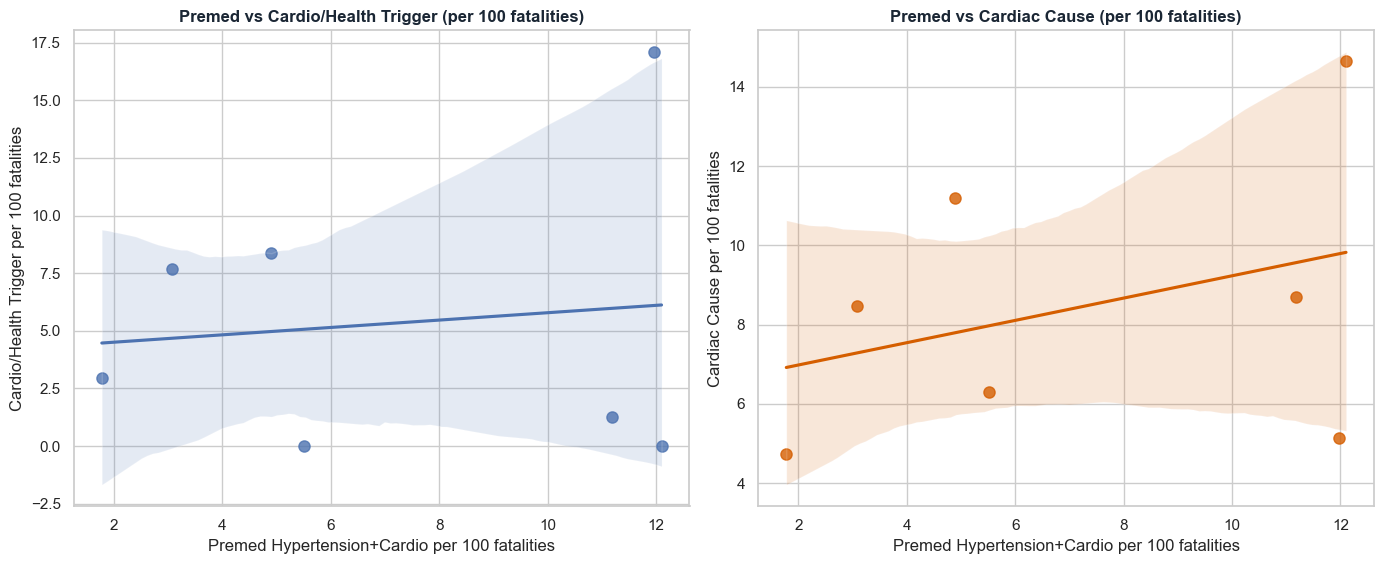

In [23]:
# Test: premedical hypertension/cardiovascular vs cardio-health trigger/cause signals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "medical_long" not in globals():
    raise RuntimeError("`medical_long` is not available. Run the medical cleaning cell first.")

# Build premedical yearly totals (Hypertension + Cardiovascular disease)
target_conditions = ["Hypertension", "Cardiovascular disease"]
premed_year = (
    medical_long[medical_long["Condition"].isin(target_conditions)]
    .groupby("year", as_index=False)["count"]
    .sum()
    .rename(columns={"count": "premed_hyper_cvd"})
)

# Get yearly fatality totals for normalization
if "year_totals" in globals() and {"year", "total_fatalities"}.issubset(year_totals.columns):
    fatality_totals = year_totals[["year", "total_fatalities"]].copy()
elif "region_long" in globals() and {"year", "fatalities"}.issubset(region_long.columns):
    fatality_totals = region_long.groupby("year", as_index=False)["fatalities"].sum().rename(columns={"fatalities": "total_fatalities"})
else:
    raise RuntimeError("Could not find yearly fatality totals (`year_totals` or `region_long`).")

fatality_totals["year"] = pd.to_numeric(fatality_totals["year"], errors="coerce").astype(int)
fatality_totals["total_fatalities"] = pd.to_numeric(fatality_totals["total_fatalities"], errors="coerce").fillna(0)

# Build yearly cardio/health trigger + cardiac cause signal from network_data if available
if "network_data" not in globals():
    raise RuntimeError("`network_data` not available. Run network-data load cell first.")

nd = network_data.copy()
if "Year" not in nd.columns and "Trigger" in nd.columns:
    nd = nd.rename(columns={"Trigger": "Year"})
if "Year" not in nd.columns:
    raise RuntimeError("No Year column found in `network_data`.")

nd["Year"] = pd.to_numeric(nd["Year"], errors="coerce")
nd = nd.dropna(subset=["Year"]).copy()
nd["Year"] = nd["Year"].astype(int)

def _sum_present(df, cols):
    present = [c for c in cols if c in df.columns]
    if not present:
        return pd.Series(0.0, index=df.index)
    return df[present].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)

# Trigger side: prefer grouped column to avoid double counting
if "Medical Trigger" in nd.columns:
    nd["cardio_health_trigger"] = pd.to_numeric(nd["Medical Trigger"], errors="coerce").fillna(0)
else:
    nd["cardio_health_trigger"] = _sum_present(nd, ["Health problem Trigger", "Cardiac event Trigger"] )

# Cause side: prefer grouped cardiac cause column to avoid double counting
if "Cardiac/Heart Cause" in nd.columns:
    nd["cardiac_cause"] = pd.to_numeric(nd["Cardiac/Heart Cause"], errors="coerce").fillna(0)
else:
    nd["cardiac_cause"] = _sum_present(nd, ["Cardiac/Heart Issue Cause"])

cardio_year = (
    nd.groupby("Year", as_index=False)[["cardio_health_trigger", "cardiac_cause"]]
    .sum()
    .rename(columns={"Year": "year"})
)

# Merge all yearly series (overlap years only)
test_df = (
    premed_year
    .merge(cardio_year, on="year", how="inner")
    .merge(fatality_totals, on="year", how="inner")
    .sort_values("year")
    .reset_index(drop=True)
)

if test_df.empty or len(test_df) < 3:
    raise RuntimeError("Not enough overlapping years to test relationship (need at least 3).")

# Normalized versions per 100 fatalities
test_df["premed_per_100_fatalities"] = np.where(
    test_df["total_fatalities"] > 0,
    (test_df["premed_hyper_cvd"] / test_df["total_fatalities"]) * 100,
    np.nan,
    )
test_df["cardio_trigger_per_100_fatalities"] = np.where(
    test_df["total_fatalities"] > 0,
    (test_df["cardio_health_trigger"] / test_df["total_fatalities"]) * 100,
    np.nan,
    )
test_df["cardiac_cause_per_100_fatalities"] = np.where(
    test_df["total_fatalities"] > 0,
    (test_df["cardiac_cause"] / test_df["total_fatalities"]) * 100,
    np.nan,
    )

# Correlation summary
pairs = [
    ("premed_hyper_cvd", "cardio_health_trigger", "Raw: Premed vs Cardio/Health Trigger"),
    ("premed_hyper_cvd", "cardiac_cause", "Raw: Premed vs Cardiac Cause"),
    ("premed_per_100_fatalities", "cardio_trigger_per_100_fatalities", "Rate: Premed vs Cardio/Health Trigger"),
    ("premed_per_100_fatalities", "cardiac_cause_per_100_fatalities", "Rate: Premed vs Cardiac Cause"),
]

rows = []
for xcol, ycol, label in pairs:
    sub = test_df[[xcol, ycol]].dropna()
    if len(sub) >= 3 and sub[xcol].nunique() > 1 and sub[ycol].nunique() > 1:
        r = sub[xcol].corr(sub[ycol])
    else:
        r = np.nan
    rows.append({
        "test": label,
        "n_years": len(sub),
        "pearson_r": r,
    })

cardio_assoc = pd.DataFrame(rows)

print("Yearly merged test table:")
display(test_df)

print("Correlation results:")
display(cardio_assoc)

# Quick visuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
sns.regplot(data=test_df, x="premed_per_100_fatalities", y="cardio_trigger_per_100_fatalities", ax=axes[0], scatter_kws={"s": 65})
axes[0].set_title("Premed vs Cardio/Health Trigger (per 100 fatalities)")
axes[0].set_xlabel("Premed Hypertension+Cardio per 100 fatalities")
axes[0].set_ylabel("Cardio/Health Trigger per 100 fatalities")

sns.regplot(data=test_df, x="premed_per_100_fatalities", y="cardiac_cause_per_100_fatalities", ax=axes[1], scatter_kws={"s": 65}, color="#d55e00")
axes[1].set_title("Premed vs Cardiac Cause (per 100 fatalities)")
axes[1].set_xlabel("Premed Hypertension+Cardio per 100 fatalities")
axes[1].set_ylabel("Cardiac Cause per 100 fatalities")

plt.tight_layout()
plt.show()

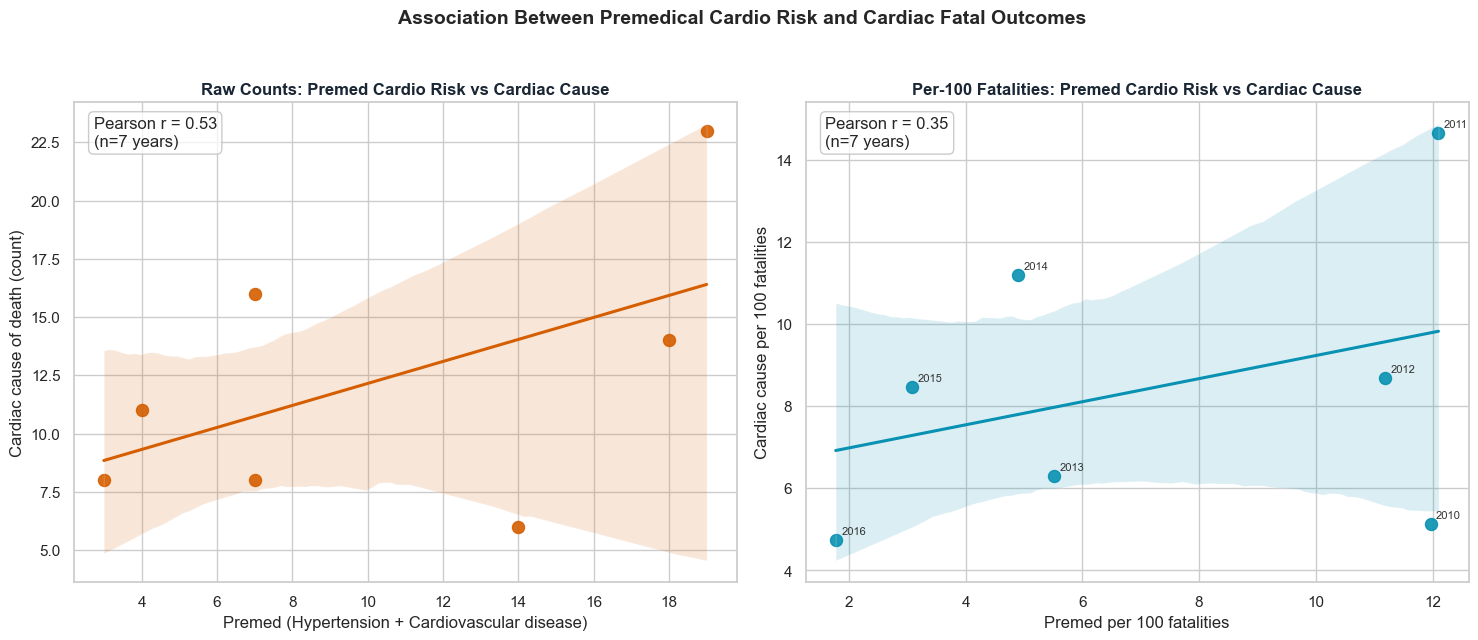

In [24]:
# Focused viz: premedical cardio risk vs cardiac cause of death
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "test_df" not in globals():
    raise RuntimeError("`test_df` is not available. Run the cardio relationship test cell first.")

plot_df = test_df.copy().sort_values("year")
r_raw = plot_df["premed_hyper_cvd"].corr(plot_df["cardiac_cause"] )
r_rate = plot_df["premed_per_100_fatalities"].corr(plot_df["cardiac_cause_per_100_fatalities"] )

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))

# Raw relationship
sns.regplot(
    data=plot_df,
    x="premed_hyper_cvd",
    y="cardiac_cause",
    ax=axes[0],
    scatter_kws={"s": 75, "alpha": 0.9},
    line_kws={"linewidth": 2.2},
    color="#d55e00",
)
axes[0].set_title("Raw Counts: Premed Cardio Risk vs Cardiac Cause", fontweight="bold")
axes[0].set_xlabel("Premed (Hypertension + Cardiovascular disease)")
axes[0].set_ylabel("Cardiac cause of death (count)")
axes[0].text(
    0.03, 0.97,
    f"Pearson r = {r_raw:.2f}\n(n={len(plot_df)} years)",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.75, "edgecolor": "#bbbbbb"},
)

# Rate-normalized relationship
sns.regplot(
    data=plot_df,
    x="premed_per_100_fatalities",
    y="cardiac_cause_per_100_fatalities",
    ax=axes[1],
    scatter_kws={"s": 75, "alpha": 0.9},
    line_kws={"linewidth": 2.2},
    color="#0891b2",
)
axes[1].set_title("Per-100 Fatalities: Premed Cardio Risk vs Cardiac Cause", fontweight="bold")
axes[1].set_xlabel("Premed per 100 fatalities")
axes[1].set_ylabel("Cardiac cause per 100 fatalities")
axes[1].text(
    0.03, 0.97,
    f"Pearson r = {r_rate:.2f}\n(n={len(plot_df)} years)",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.75, "edgecolor": "#bbbbbb"},
)

for _, row in plot_df.iterrows():
    axes[1].annotate(str(int(row["year"])), (row["premed_per_100_fatalities"], row["cardiac_cause_per_100_fatalities"]),
                     textcoords="offset points", xytext=(4, 4), fontsize=8, color="#333333")

plt.suptitle("Association Between Premedical Cardio Risk and Cardiac Fatal Outcomes", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

Full 4-way log-linear model (Pre-condition × Trigger × Cause × Year) requires JOINT contingency counts by combination.
Current data are yearly marginals, so this cell runs pairwise Poisson log-linear association screening as the statistically valid fallback.



/Users/mirandagrein/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/mirandagrein/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/mirandagrein/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/mirandagrein/Library/Python/3.9/lib/python/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction de

Top associations (Poisson log-linear, with FDR correction):


,condition,outcome,outcome_type,beta,IRR,p_value,n_years,q_value,significant_q10,direction
0,Asthma,Environmental Cause,Cause,-9.031143,1.196256e-04,1.103895e-168,7,1.324674e-166,True,negative
1,Allergies,Environmental Cause,Cause,-27.543273,1.091713e-12,1.475651e-150,7,8.853903e-149,True,negative
2,Pulmonary,Environmental Cause,Cause,12.456992,2.570412e+05,1.700874e-149,7,6.803494e-148,True,positive
3,Diabetes,Environmental Cause,Cause,8.903666,7.358902e+03,6.086205e-140,7,1.825862e-138,True,positive
4,Back Pain,Environmental Cause,Cause,10.356073,3.144743e+04,1.775327e-69,7,4.260785e-68,True,positive
5,Flu/cold,Environmental Cause,Cause,-11.630350,8.892078e-06,8.604108e-61,7,1.720822e-59,True,negative
6,Depression,Environmental Trigger,Trigger,-1.547723,2.127318e-01,1.721257e-51,7,2.950726e-50,True,negative
7,Nervous System,Environmental Cause,Cause,19.873591,4.275538e+08,7.409912e-45,7,1.004833e-43,True,positive
8,Ear/sinus,Environmental Cause,Cause,-19.868725,2.350296e-09,7.536246e-45,7,1.004833e-43,True,negative
9,Cardiovascular disease,Environmental Cause,Cause,3.585873,3.608486e+01,7.832796e-37,7,9.399355e-36,True,positive


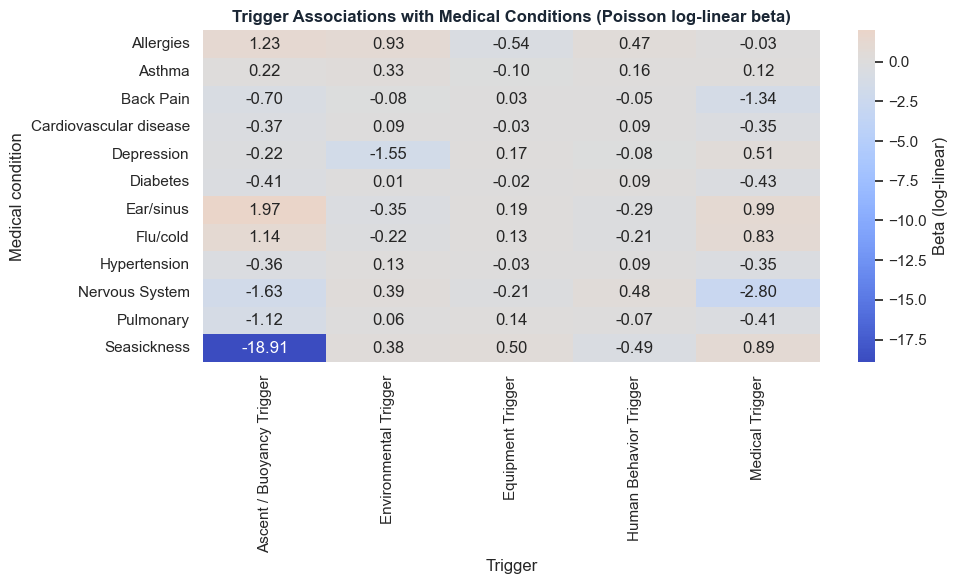

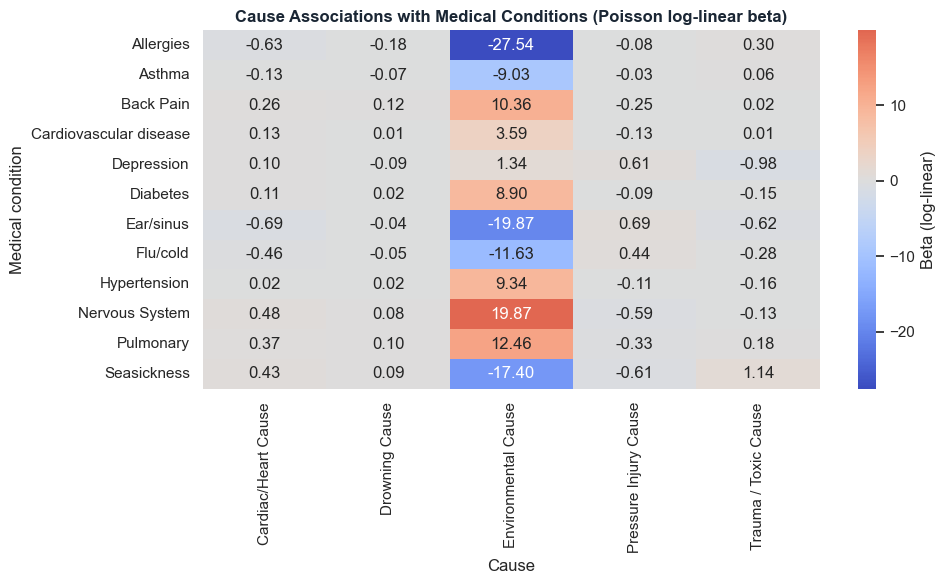

In [25]:
#log-linear style association modeling (Poisson GLM + FDR correction)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid")

if "medical_long" not in globals():
    raise RuntimeError("`medical_long` is required. Run the medical cleaning cell first.")
if "network_data" not in globals():
    raise RuntimeError("`network_data` is required. Run the network data load/grouping cells first.")
if "year_totals" not in globals():
    raise RuntimeError("`year_totals` is required for offsets. Run the regional/year totals cell first.")

print("Full 4-way log-linear model (Pre-condition × Trigger × Cause × Year) requires JOINT contingency counts by combination.")
print("Current data are yearly marginals, so this cell runs pairwise Poisson log-linear association screening as the statistically valid fallback.\n")

# Condition-by-year table
condition_year = (
    medical_long.groupby(["year", "Condition"], as_index=False)["count"]
    .sum()
    .rename(columns={"count": "condition_count"})
)

# Prepare outcome-by-year table from grouped trigger/cause categories
nd = network_data.copy()
if "Year" not in nd.columns and "Trigger" in nd.columns:
    nd = nd.rename(columns={"Trigger": "Year"})
nd["Year"] = pd.to_numeric(nd["Year"], errors="coerce")
nd = nd.dropna(subset=["Year"]).copy()
nd["Year"] = nd["Year"].astype(int)

trigger_cols = [
    "Medical Trigger",
    "Human Behavior Trigger",
    "Equipment Trigger",
    "Environmental Trigger",
    "Ascent / Buoyancy Trigger",
]
cause_cols = [
    "Drowning Cause",
    "Cardiac/Heart Cause",
    "Pressure Injury Cause",
    "Trauma / Toxic Cause",
    "Environmental Cause",
]

available_outcomes = [col for col in (trigger_cols + cause_cols) if col in nd.columns]
if not available_outcomes:
    raise RuntimeError("No grouped trigger/cause columns found in network_data.")

outcome_year = nd[["Year"] + available_outcomes].copy().rename(columns={"Year": "year"})
for c in available_outcomes:
    outcome_year[c] = pd.to_numeric(outcome_year[c], errors="coerce").fillna(0)

# Year totals for offset
totals = year_totals[["year", "total_fatalities"]].copy()
totals["year"] = pd.to_numeric(totals["year"], errors="coerce").astype(int)
totals["total_fatalities"] = pd.to_numeric(totals["total_fatalities"], errors="coerce").fillna(0)
totals = totals[totals["total_fatalities"] > 0].copy()

# Candidate conditions (drop all-zero/constant)
condition_totals = condition_year.groupby("Condition", as_index=False)["condition_count"].sum()
candidate_conditions = condition_totals[condition_totals["condition_count"] > 0]["Condition"].tolist()

results = []

for cond in candidate_conditions:
    cond_df = condition_year[condition_year["Condition"] == cond][["year", "condition_count"]].copy()

    for outcome in available_outcomes:
        model_df = totals.merge(cond_df, on="year", how="inner").merge(
            outcome_year[["year", outcome]].rename(columns={outcome: "outcome_count"}),
            on="year",
            how="inner",
        )

        model_df = model_df.dropna(subset=["condition_count", "outcome_count", "total_fatalities"]).copy()
        if len(model_df) < 5:
            continue
        if model_df["condition_count"].nunique() < 2 or model_df["outcome_count"].nunique() < 2:
            continue

        model_df["year_centered"] = model_df["year"] - model_df["year"].mean()
        model_df["offset"] = np.log(model_df["total_fatalities"])

        try:
            fit = smf.glm(
                "outcome_count ~ condition_count + year_centered",
                data=model_df,
                family=sm.families.Poisson(),
                offset=model_df["offset"],
            ).fit(cov_type="HC3")

            beta = fit.params.get("condition_count", np.nan)
            pval = fit.pvalues.get("condition_count", np.nan)
            irr = float(np.exp(beta)) if pd.notna(beta) else np.nan

            results.append({
                "condition": cond,
                "outcome": outcome,
                "outcome_type": "Trigger" if outcome in trigger_cols else "Cause",
                "beta": beta,
                "IRR": irr,
                "p_value": pval,
                "n_years": len(model_df),
            })
        except Exception:
            continue

assoc_results_ll = pd.DataFrame(results)
if assoc_results_ll.empty:
    raise RuntimeError("No valid GLM fits produced. Check overlap years and non-constant series.")

# Multiple-testing correction (BH-FDR)
reject, qvals, _, _ = multipletests(assoc_results_ll["p_value"].values, alpha=0.10, method="fdr_bh")
assoc_results_ll["q_value"] = qvals
assoc_results_ll["significant_q10"] = reject
assoc_results_ll["direction"] = np.where(assoc_results_ll["beta"] >= 0, "positive", "negative")

assoc_results_ll = assoc_results_ll.sort_values(["q_value", "p_value", "outcome_type", "outcome"]).reset_index(drop=True)

print("Top associations (Poisson log-linear, with FDR correction):")
display(assoc_results_ll.head(20))

# Heatmaps: beta coefficients for trigger and cause associations
for outcome_type in ["Trigger", "Cause"]:
    hm = assoc_results_ll[assoc_results_ll["outcome_type"] == outcome_type].copy()
    if hm.empty:
        continue

    pivot_beta = hm.pivot_table(index="condition", columns="outcome", values="beta", aggfunc="mean")
    plt.figure(figsize=(10, max(6, 0.35 * len(pivot_beta.index))))
    sns.heatmap(pivot_beta, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar_kws={"label": "Beta (log-linear)"})
    plt.title(f"{outcome_type} Associations with Medical Conditions (Poisson log-linear beta)")
    plt.xlabel(outcome_type)
    plt.ylabel("Medical condition")
    plt.tight_layout()
    plt.show()

# Keep for downstream use
assoc_results = assoc_results_ll.copy()

Subtype split correlations:


,subtype,n_years,r_raw_with_cardiac_cause,r_rate_with_cardiac_cause
1,Cardiovascular disease,7,0.78043,0.739612
0,Hypertension,7,0.31540,0.107063



Stability (leave-one-year-out correlations):


,dropped_year,r_raw,r_rate
0,2010,0.754591,0.681448
1,2011,0.134911,-0.045335
2,2012,0.545245,0.368796
3,2013,0.497339,0.321329
4,2014,0.629689,0.469420
5,2015,0.541534,0.385533
6,2016,0.452133,0.133865



Stability summary:


,metric,mean,std,min,max,pct_positive
0,r_raw,0.507920,0.191728,0.134911,0.754591,100.000000
1,r_rate,0.330722,0.233438,-0.045335,0.681448,85.714286



Lag test summary (t-1 premedical -> t cardiac cause):


,n_lag_pairs,lag_r_raw,lag_r_rate
0,6,0.181903,0.414258


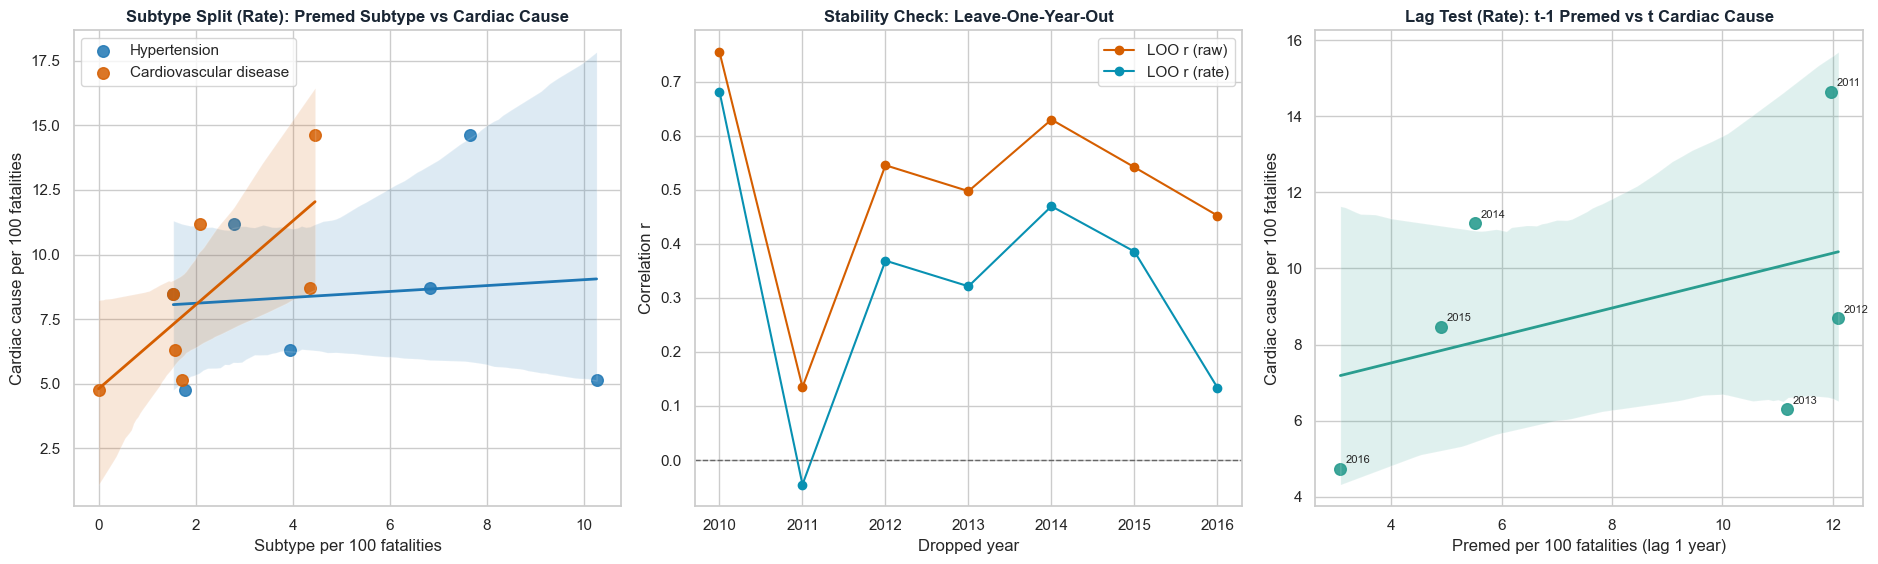

In [26]:
# Additional tests: subtype split + stability (leave-one-year-out) + lag test
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "test_df" not in globals():
    raise RuntimeError("`test_df` is not available. Run the cardio relationship test cell first.")
if "medical_long" not in globals():
    raise RuntimeError("`medical_long` is not available. Run the medical cleaning cell first.")

base = test_df.copy().sort_values("year").reset_index(drop=True)
required_cols = {
    "year",
    "premed_hyper_cvd",
    "premed_per_100_fatalities",
    "cardiac_cause",
    "cardiac_cause_per_100_fatalities",
    "total_fatalities",
}
missing = [c for c in required_cols if c not in base.columns]
if missing:
    raise RuntimeError(f"`test_df` is missing required columns: {missing}")

# 1) Subtype split: Hypertension vs Cardiovascular disease
subtypes = ["Hypertension", "Cardiovascular disease"]
subtype_rows = []
subtype_merged = {}

for subtype in subtypes:
    subtype_year = (
        medical_long[medical_long["Condition"] == subtype]
        .groupby("year", as_index=False)["count"]
        .sum()
        .rename(columns={"count": "subtype_count"})
    )

    subtype_df = base[["year", "cardiac_cause", "cardiac_cause_per_100_fatalities", "total_fatalities"]].merge(
        subtype_year,
        on="year",
        how="left",
    )
    subtype_df["subtype_count"] = subtype_df["subtype_count"].fillna(0)
    subtype_df["subtype_per_100_fatalities"] = np.where(
        subtype_df["total_fatalities"] > 0,
        (subtype_df["subtype_count"] / subtype_df["total_fatalities"]) * 100,
        np.nan,
    )

    r_raw = subtype_df[["subtype_count", "cardiac_cause"]].corr().iloc[0, 1]
    r_rate = subtype_df[["subtype_per_100_fatalities", "cardiac_cause_per_100_fatalities"]].corr().iloc[0, 1]

    subtype_rows.append(
        {
            "subtype": subtype,
            "n_years": int(subtype_df.shape[0]),
            "r_raw_with_cardiac_cause": r_raw,
            "r_rate_with_cardiac_cause": r_rate,
        }
    )
    subtype_merged[subtype] = subtype_df

subtype_results = pd.DataFrame(subtype_rows).sort_values("r_rate_with_cardiac_cause", ascending=False)

# 2) Stability: leave-one-year-out on primary relationship
stability_rows = []
for dropped_year in base["year"].tolist():
    loo = base[base["year"] != dropped_year].copy()
    r_raw = loo[["premed_hyper_cvd", "cardiac_cause"]].corr().iloc[0, 1]
    r_rate = loo[["premed_per_100_fatalities", "cardiac_cause_per_100_fatalities"]].corr().iloc[0, 1]
    stability_rows.append(
        {
            "dropped_year": int(dropped_year),
            "r_raw": r_raw,
            "r_rate": r_rate,
        }
    )

stability_df = pd.DataFrame(stability_rows).sort_values("dropped_year")
stability_summary = pd.DataFrame(
    {
        "metric": ["r_raw", "r_rate"],
        "mean": [stability_df["r_raw"].mean(), stability_df["r_rate"].mean()],
        "std": [stability_df["r_raw"].std(ddof=1), stability_df["r_rate"].std(ddof=1)],
        "min": [stability_df["r_raw"].min(), stability_df["r_rate"].min()],
        "max": [stability_df["r_raw"].max(), stability_df["r_rate"].max()],
        "pct_positive": [
            (stability_df["r_raw"] > 0).mean() * 100,
            (stability_df["r_rate"] > 0).mean() * 100,
        ],
    }
)

# 3) Lag test: t-1 premedical burden vs t cardiac cause
lag_df = base[["year", "premed_hyper_cvd", "premed_per_100_fatalities"]].copy()
lag_df["premed_hyper_cvd_lag1"] = lag_df["premed_hyper_cvd"].shift(1)
lag_df["premed_per_100_fatalities_lag1"] = lag_df["premed_per_100_fatalities"].shift(1)

lag_test = base[["year", "cardiac_cause", "cardiac_cause_per_100_fatalities"]].merge(
    lag_df[["year", "premed_hyper_cvd_lag1", "premed_per_100_fatalities_lag1"]],
    on="year",
    how="left",
)
lag_test = lag_test.dropna().copy()

if len(lag_test) >= 3:
    lag_r_raw = lag_test[["premed_hyper_cvd_lag1", "cardiac_cause"]].corr().iloc[0, 1]
    lag_r_rate = lag_test[["premed_per_100_fatalities_lag1", "cardiac_cause_per_100_fatalities"]].corr().iloc[0, 1]
else:
    lag_r_raw = np.nan
    lag_r_rate = np.nan

lag_summary = pd.DataFrame(
    [
        {
            "n_lag_pairs": int(len(lag_test)),
            "lag_r_raw": lag_r_raw,
            "lag_r_rate": lag_r_rate,
        }
    ]
)

print("Subtype split correlations:")
display(subtype_results)

print("\nStability (leave-one-year-out correlations):")
display(stability_df)
print("\nStability summary:")
display(stability_summary)

print("\nLag test summary (t-1 premedical -> t cardiac cause):")
display(lag_summary)

# Visuals
fig, axes = plt.subplots(1, 3, figsize=(19, 5.8))

# Subtype split (rate scale)
for subtype, color in zip(subtypes, ["#1f77b4", "#d55e00"]):
    dsub = subtype_merged[subtype]
    sns.regplot(
        data=dsub,
        x="subtype_per_100_fatalities",
        y="cardiac_cause_per_100_fatalities",
        scatter_kws={"s": 70, "alpha": 0.85},
        line_kws={"linewidth": 2},
        color=color,
        ax=axes[0],
        label=subtype,
    )
axes[0].set_title("Subtype Split (Rate): Premed Subtype vs Cardiac Cause")
axes[0].set_xlabel("Subtype per 100 fatalities")
axes[0].set_ylabel("Cardiac cause per 100 fatalities")
axes[0].legend(frameon=True)

# Stability plot
axes[1].plot(stability_df["dropped_year"], stability_df["r_raw"], marker="o", label="LOO r (raw)", color="#d55e00")
axes[1].plot(stability_df["dropped_year"], stability_df["r_rate"], marker="o", label="LOO r (rate)", color="#0891b2")
axes[1].axhline(0, linestyle="--", color="#666666", linewidth=1)
axes[1].set_title("Stability Check: Leave-One-Year-Out")
axes[1].set_xlabel("Dropped year")
axes[1].set_ylabel("Correlation r")
axes[1].legend(frameon=True)

# Lag plot (rate)
if len(lag_test) >= 2:
    sns.regplot(
        data=lag_test,
        x="premed_per_100_fatalities_lag1",
        y="cardiac_cause_per_100_fatalities",
        scatter_kws={"s": 70, "alpha": 0.9},
        line_kws={"linewidth": 2},
        color="#2a9d8f",
        ax=axes[2],
    )
    for _, row in lag_test.iterrows():
        axes[2].annotate(str(int(row["year"])), (row["premed_per_100_fatalities_lag1"], row["cardiac_cause_per_100_fatalities"]), textcoords="offset points", xytext=(4, 4), fontsize=8)
    axes[2].set_title("Lag Test (Rate): t-1 Premed vs t Cardiac Cause")
    axes[2].set_xlabel("Premed per 100 fatalities (lag 1 year)")
    axes[2].set_ylabel("Cardiac cause per 100 fatalities")
else:
    axes[2].text(0.5, 0.5, "Not enough lagged points", ha="center", va="center")
    axes[2].set_title("Lag Test")
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()

# Keep outputs for write-up
subtype_split_results = subtype_results.copy()
stability_leave_one_out = stability_df.copy()
lag_test_results = lag_summary.copy()

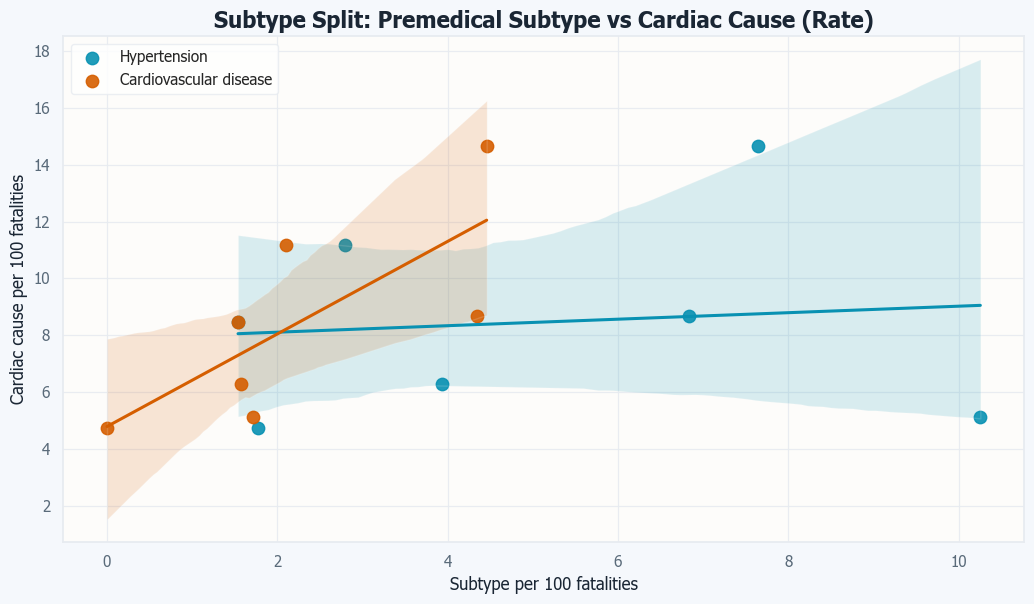

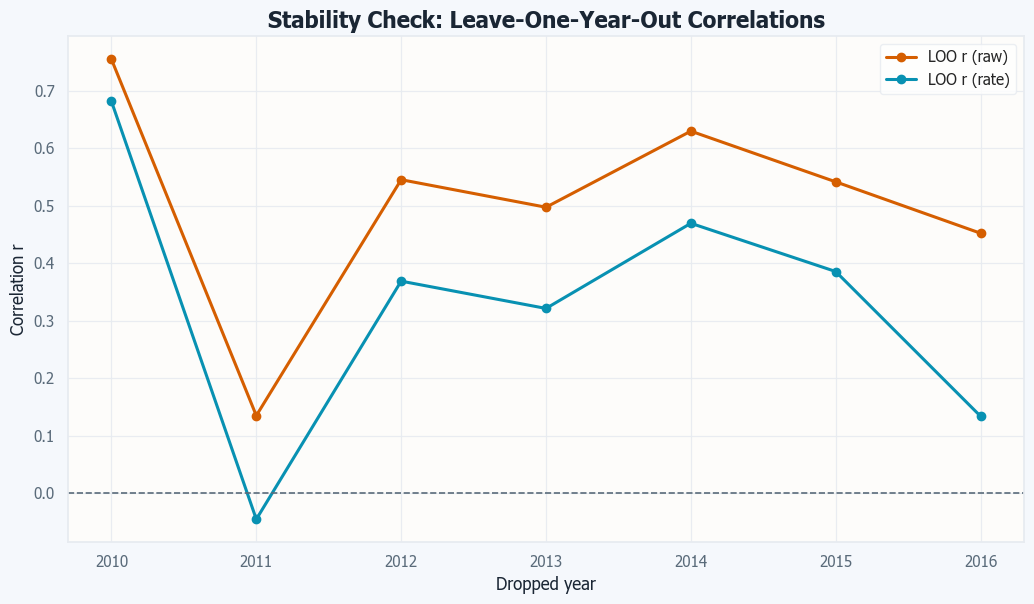

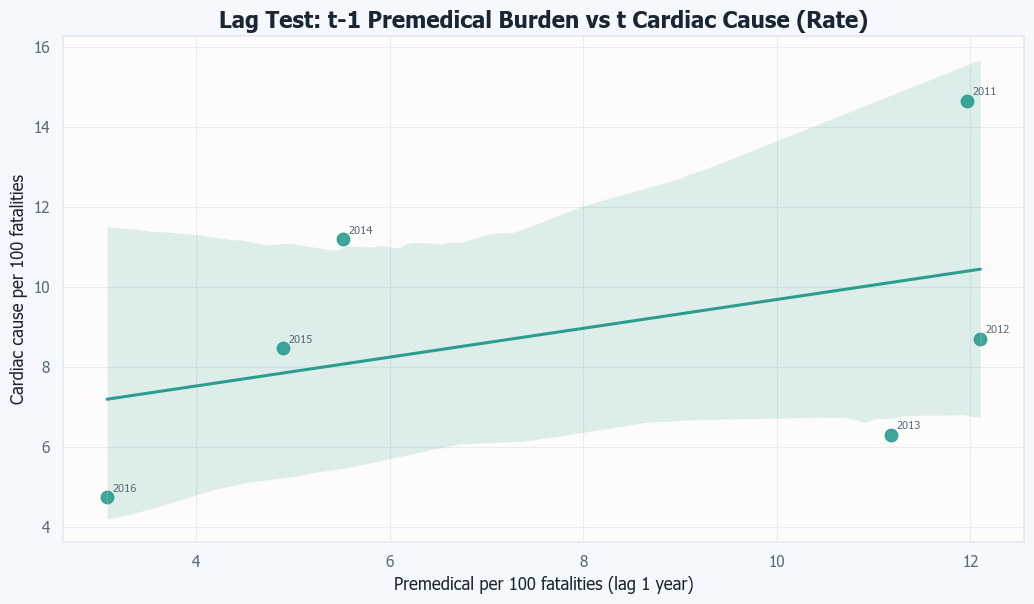

In [27]:
# Separate styled figures (Index theme): subtype split, stability, and lag
import matplotlib.pyplot as plt
import seaborn as sns

required_objects = ["subtype_merged", "subtypes", "stability_df", "lag_test"]
missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise RuntimeError(f"Run the previous robustness test cell first. Missing: {missing_objects}")

INDEX_THEME = {
    "bg": "#f5f8fc",
    "panel": "#fdfcfa",
    "panel_soft": "#fbfbf7",
    "line": "#e7ebf0",
    "text": "#1a2634",
    "muted": "#5a6b7a",
    "accent": "#0891b2",
    "accent_soft": "#dff4fb",
}

plt.rcParams.update({
    "figure.facecolor": INDEX_THEME["bg"],
    "axes.facecolor": INDEX_THEME["panel"],
    "axes.edgecolor": INDEX_THEME["line"],
    "axes.labelcolor": INDEX_THEME["text"],
    "axes.titlecolor": INDEX_THEME["text"],
    "xtick.color": INDEX_THEME["text"],
    "ytick.color": INDEX_THEME["text"],
    "font.size": 12,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Tahoma", "Geneva", "Verdana", "Arial", "DejaVu Sans"],
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
})


def style_axis(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, color=INDEX_THEME["text"])
    ax.set_ylabel(ylabel, color=INDEX_THEME["text"])
    ax.tick_params(axis="both", colors=INDEX_THEME["muted"], labelsize=11)
    ax.grid(color=INDEX_THEME["line"], linewidth=0.9, alpha=0.9)
    for spine in ax.spines.values():
        spine.set_color(INDEX_THEME["line"])


# Figure 1: Subtype split (rate)
fig = plt.figure(figsize=(10.5, 6.2))
ax = fig.add_subplot(111)
for subtype, color in zip(subtypes, ["#0891b2", "#d55e00"]):
    dsub = subtype_merged[subtype]
    sns.regplot(
        data=dsub,
        x="subtype_per_100_fatalities",
        y="cardiac_cause_per_100_fatalities",
        scatter_kws={"s": 80, "alpha": 0.9},
        line_kws={"linewidth": 2.2},
        color=color,
        ax=ax,
        label=subtype,
    )
ax.set_title("Subtype Split: Premedical Subtype vs Cardiac Cause (Rate)")
style_axis(ax, "Subtype per 100 fatalities", "Cardiac cause per 100 fatalities")
ax.legend(frameon=True, facecolor="white", edgecolor=INDEX_THEME["line"])
plt.tight_layout()
plt.show()


# Figure 2: Stability leave-one-year-out
fig = plt.figure(figsize=(10.5, 6.2))
ax = fig.add_subplot(111)
ax.plot(stability_df["dropped_year"], stability_df["r_raw"], marker="o", label="LOO r (raw)", color="#d55e00", linewidth=2.2)
ax.plot(stability_df["dropped_year"], stability_df["r_rate"], marker="o", label="LOO r (rate)", color="#0891b2", linewidth=2.2)
ax.axhline(0, linestyle="--", color=INDEX_THEME["muted"], linewidth=1.2)
ax.set_title("Stability Check: Leave-One-Year-Out Correlations")
style_axis(ax, "Dropped year", "Correlation r")
ax.legend(frameon=True, facecolor="white", edgecolor=INDEX_THEME["line"])
plt.tight_layout()
plt.show()


# Figure 3: Lag test (rate)
fig = plt.figure(figsize=(10.5, 6.2))
ax = fig.add_subplot(111)
if len(lag_test) >= 2:
    sns.regplot(
        data=lag_test,
        x="premed_per_100_fatalities_lag1",
        y="cardiac_cause_per_100_fatalities",
        scatter_kws={"s": 80, "alpha": 0.9},
        line_kws={"linewidth": 2.2},
        color="#2a9d8f",
        ax=ax,
    )
    for _, row in lag_test.iterrows():
        ax.annotate(
            str(int(row["year"])),
            (row["premed_per_100_fatalities_lag1"], row["cardiac_cause_per_100_fatalities"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
            color=INDEX_THEME["muted"],
        )
    ax.set_title("Lag Test: t-1 Premedical Burden vs t Cardiac Cause (Rate)")
    style_axis(ax, "Premedical per 100 fatalities (lag 1 year)", "Cardiac cause per 100 fatalities")
else:
    ax.text(0.5, 0.5, "Not enough lagged points", ha="center", va="center", color=INDEX_THEME["muted"])
    ax.set_axis_off()
plt.tight_layout()
plt.show()

In [28]:
# Load and inspect DisablingInjury file from Downloads
from pathlib import Path
import pandas as pd

downloads = Path.home() / "Downloads"
disable_candidates = [
    downloads / "DisablingInjury.xlsl",
    downloads / "DisablingInjury.xlsx",
    downloads / "DisablingInjury.xls",
    downloads / "disablinginjury.xlsl",
    downloads / "disablinginjury.xlsx",
    downloads / "disablinginjury.xls",
]

existing_disable_files = [p for p in disable_candidates if p.exists()]
if not existing_disable_files:
    raise FileNotFoundError(f"Could not find DisablingInjury file in Downloads. Tried: {disable_candidates}")

disable_file = existing_disable_files[0]
disable_df = pd.read_excel(disable_file)

print(f"Loaded disable_df from: {disable_file}")
print("disable_df shape:", disable_df.shape)
print("disable_df columns:", list(disable_df.columns))
display(disable_df.head(12))

Loaded disable_df from: /Users/mirandagrein/Downloads/DisablingInjury.xlsx
disable_df shape: (23, 10)
disable_df columns: ['Disabling injuries by year and overall, 2010-2013 (n=323)', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']


,"Disabling injuries by year and overall, 2010-2013 (n=323)",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Disabling Injury,2010,2011,2012,2013,2014,2015,2016,2017,2018
1,Unknown,15,38,39,48,27,4,7,3,0
2,Cardiovascular disease,13,25,16,8,2,0,0,0,0
3,Drowning/ Asphixia,16,16,13,13,13,6,7,1,6
4,Arterial gas embolism,19,4,4,2,1,6,0,1,6
5,Immersion pulmonary edema,0,6,2,2,0,0,0,0,6
6,Loss of consciousness,1,3,1,3,1,1,7,1,3
7,Decompression sickness,0,3,1,0,0,0,3,1,0
8,Other,4,0,0,0,0,0,0,0,0
9,Seizure,0,1,2,0,2,0,0,0,0


Advanced log-linear interaction modeling complete.
Modeling structure: outcome_count ~ outcome + condition + outcome×condition + year + offset(log(total_fatalities))

Overdispersion check (Pearson chi2 / df, >1 suggests extra-Poisson variation):


,stage,pearson_chi2_df
0,Trigger,3.466129
1,Cause,1.290525
2,Disabling,2.932323



Top interaction effects (all stages, FDR-corrected within stage):


,term,beta,p_value,stage,irr,q_value,significant_q10,direction
86,C(outcome)[T.Pressure Injury Cause]:C(conditio...,-1.791759,0.000103,Cause,0.166667,NaN,True,negative
84,C(outcome)[T.Drowning Cause]:C(condition)[T.Se...,-0.773569,0.000388,Cause,0.461364,NaN,True,negative
79,C(outcome)[T.Trauma / Toxic Cause]:C(condition...,-0.684179,0.011831,Cause,0.504505,NaN,False,negative
87,C(outcome)[T.Trauma / Toxic Cause]:C(condition...,-0.538997,0.023617,Cause,0.583333,NaN,False,negative
83,C(outcome)[T.Trauma / Toxic Cause]:C(condition...,-0.638087,0.033951,Cause,0.528302,NaN,False,negative
82,C(outcome)[T.Pressure Injury Cause]:C(conditio...,-1.043553,0.042498,Cause,0.352201,NaN,False,negative
50,C(outcome)[T.Pressure Injury Cause]:C(conditio...,-1.001985,0.045606,Cause,0.367150,NaN,False,negative
51,C(outcome)[T.Trauma / Toxic Cause]:C(condition...,-0.614220,0.056550,Cause,0.541063,NaN,False,negative
80,C(outcome)[T.Drowning Cause]:C(condition)[T.Pu...,-0.486538,0.066207,Cause,0.614751,NaN,False,negative
75,C(outcome)[T.Trauma / Toxic Cause]:C(condition...,-0.611317,0.068356,Cause,0.542636,NaN,False,negative



Robustness interactions (Unknown removed + rare outcomes removed):


,term,beta,p_value,stage,irr,q_value,significant_q10,direction
65,C(outcome)[T.Pressure Injury Cause]:C(conditio...,-1.791759,1.055044e-04,Cause_robust,1.666667e-01,0.002321,True,negative
64,C(outcome)[T.Drowning Cause]:C(condition)[T.Se...,-0.773569,3.549622e-04,Cause_robust,4.613636e-01,0.003905,True,negative
63,C(outcome)[T.Pressure Injury Cause]:C(conditio...,-1.043553,4.287272e-02,Cause_robust,3.522013e-01,0.253022,False,negative
47,C(outcome)[T.Pressure Injury Cause]:C(conditio...,-1.001985,4.600397e-02,Cause_robust,3.671498e-01,0.253022,False,negative
62,C(outcome)[T.Drowning Cause]:C(condition)[T.Pu...,-0.486538,6.501807e-02,Cause_robust,6.147513e-01,0.286080,False,negative
61,C(outcome)[T.Pressure Injury Cause]:C(conditio...,-0.838329,1.017221e-01,Cause_robust,4.324324e-01,0.372981,False,negative
46,C(outcome)[T.Drowning Cause]:C(condition)[T.Ba...,-0.387447,1.230134e-01,Cause_robust,6.787879e-01,0.386613,False,negative
60,C(outcome)[T.Drowning Cause]:C(condition)[T.Ne...,-0.384074,1.593343e-01,Cause_robust,6.810811e-01,0.416345,False,negative
52,C(outcome)[T.Drowning Cause]:C(condition)[T.Di...,-0.346160,2.066572e-01,Cause_robust,7.073996e-01,0.416345,False,negative
58,C(outcome)[T.Drowning Cause]:C(condition)[T.Hy...,-0.346160,2.066572e-01,Cause_robust,7.073996e-01,0.416345,False,negative


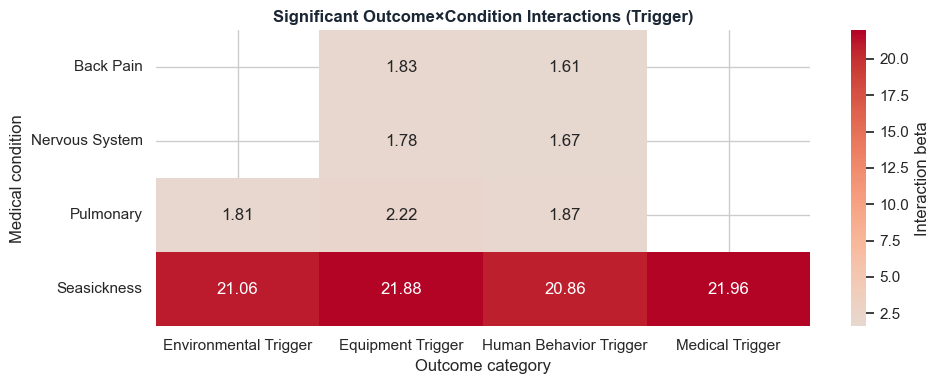

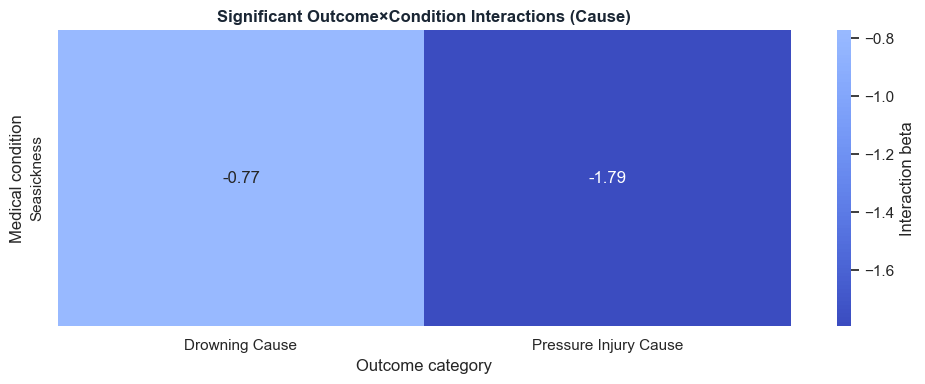

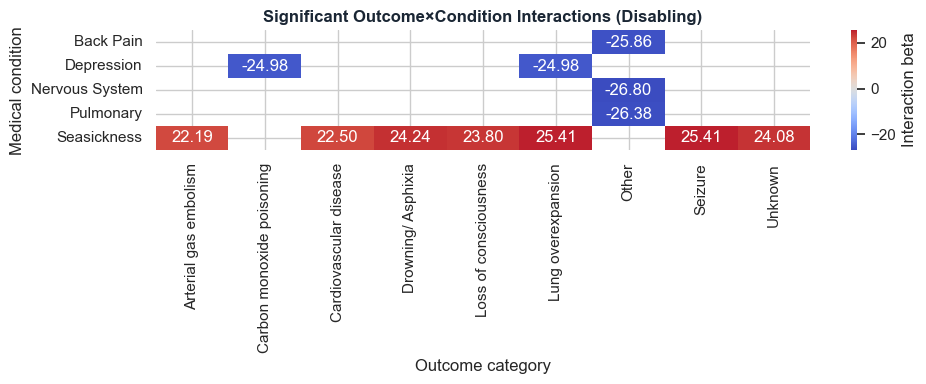

In [29]:
# Advanced multi-category log-linear modeling using medical + trigger/cause + disabling
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

sns.set_theme(style="whitegrid")

required = ["medical_long", "network_data", "year_totals", "disable_df"]
missing_required = [x for x in required if x not in globals()]
if missing_required:
    raise RuntimeError(f"Missing required objects: {missing_required}")

# -----------------------------
# 1) Clean disabling table
# -----------------------------
dis_raw = disable_df.copy().dropna(how="all").reset_index(drop=True)

if all(str(c).startswith("Unnamed") or "Disabling injuries" in str(c) for c in dis_raw.columns):
    new_header = dis_raw.iloc[0].astype(str).str.strip().tolist()
    dis = dis_raw.iloc[1:].copy().reset_index(drop=True)
    dis.columns = new_header
else:
    dis = dis_raw.copy()

first_col = dis.columns[0]
dis = dis.rename(columns={first_col: "Disabling"})
dis["Disabling"] = dis["Disabling"].astype(str).str.strip()

year_cols_dis = [c for c in dis.columns if re.fullmatch(r"\d{4}", str(c).strip())]
if not year_cols_dis:
    for c in list(dis.columns):
        m = re.search(r"(19\d{2}|20\d{2})", str(c))
        if m:
            dis = dis.rename(columns={c: m.group(1)})
    year_cols_dis = [c for c in dis.columns if re.fullmatch(r"\d{4}", str(c).strip())]

if not year_cols_dis:
    raise RuntimeError(f"No year columns found in disable_df. Columns: {list(dis.columns)}")

disable_long = dis.melt(id_vars=["Disabling"], value_vars=year_cols_dis, var_name="year", value_name="count")
disable_long["year"] = pd.to_numeric(disable_long["year"], errors="coerce").astype("Int64")
disable_long["count"] = pd.to_numeric(disable_long["count"], errors="coerce").fillna(0)
disable_long = disable_long.dropna(subset=["year"]).copy()
disable_long["year"] = disable_long["year"].astype(int)
disable_long = disable_long[~disable_long["Disabling"].str.lower().isin(["nan", "total", "disabling injury"])].copy()

# -----------------------------
# 2) Build Trigger + Cause long from grouped network_data
# -----------------------------
nd = network_data.copy()
if "Year" not in nd.columns and "Trigger" in nd.columns:
    nd = nd.rename(columns={"Trigger": "Year"})
nd["Year"] = pd.to_numeric(nd["Year"], errors="coerce")
nd = nd.dropna(subset=["Year"]).copy()
nd["Year"] = nd["Year"].astype(int)

trigger_cols = [
    "Medical Trigger",
    "Human Behavior Trigger",
    "Equipment Trigger",
    "Environmental Trigger",
    "Ascent / Buoyancy Trigger",
]
cause_cols = [
    "Drowning Cause",
    "Cardiac/Heart Cause",
    "Pressure Injury Cause",
    "Trauma / Toxic Cause",
    "Environmental Cause",
]

missing_trigger = [c for c in trigger_cols if c not in nd.columns]
missing_cause = [c for c in cause_cols if c not in nd.columns]
if missing_trigger or missing_cause:
    raise RuntimeError(f"Missing grouped trigger/cause columns. Trigger missing: {missing_trigger}; Cause missing: {missing_cause}")

for c in trigger_cols + cause_cols:
    nd[c] = pd.to_numeric(nd[c], errors="coerce").fillna(0)

trigger_long = nd[["Year"] + trigger_cols].melt(id_vars=["Year"], var_name="outcome", value_name="count").rename(columns={"Year": "year"})
trigger_long["stage"] = "Trigger"

cause_long = nd[["Year"] + cause_cols].melt(id_vars=["Year"], var_name="outcome", value_name="count").rename(columns={"Year": "year"})
cause_long["stage"] = "Cause"

disable_stage_long = disable_long.rename(columns={"Disabling": "outcome", "count": "count"})[["year", "outcome", "count"]].copy()
disable_stage_long["stage"] = "Disabling"

stage_long_all = pd.concat([trigger_long, cause_long, disable_stage_long], ignore_index=True)
stage_long_all["count"] = pd.to_numeric(stage_long_all["count"], errors="coerce").fillna(0)

# -----------------------------
# 3) Medical condition-by-year
# -----------------------------
cond_year = (
    medical_long.groupby(["year", "Condition"], as_index=False)["count"]
    .sum()
    .rename(columns={"count": "condition_count", "Condition": "condition"})
)
cond_year = cond_year[cond_year["condition_count"] > 0].copy()

# totals for offset
totals = year_totals[["year", "total_fatalities"]].copy()
totals["year"] = pd.to_numeric(totals["year"], errors="coerce").astype(int)
totals["total_fatalities"] = pd.to_numeric(totals["total_fatalities"], errors="coerce").fillna(0)
totals = totals[totals["total_fatalities"] > 0].copy()

# -----------------------------
# 4) Stage-wise log-linear interaction model
# outcome_count ~ outcome_category + condition_count + outcome_category:condition_count + year
# -----------------------------
def fit_stage_model(stage_df, stage_name):
    pooled = (
        stage_df.merge(cond_year, on="year", how="inner")
        .merge(totals, on="year", how="inner")
        .copy()
    )
    pooled = pooled.dropna(subset=["count", "condition_count", "total_fatalities", "outcome", "condition"]).copy()
    pooled = pooled[pooled["total_fatalities"] > 0].copy()

    # Keep only outcomes with enough total counts to reduce separation
    outcome_totals = pooled.groupby("outcome", as_index=False)["count"].sum().rename(columns={"count": "outcome_total"})
    keep_outcomes = outcome_totals[outcome_totals["outcome_total"] >= 5]["outcome"].tolist()
    pooled = pooled[pooled["outcome"].isin(keep_outcomes)].copy()

    # Keep conditions with enough total counts
    cond_totals = pooled.groupby("condition", as_index=False)["condition_count"].sum().rename(columns={"condition_count": "condition_total"})
    keep_conds = cond_totals[cond_totals["condition_total"] >= 3]["condition"].tolist()
    pooled = pooled[pooled["condition"].isin(keep_conds)].copy()

    if pooled.empty or pooled["outcome"].nunique() < 2 or pooled["condition"].nunique() < 2:
        raise RuntimeError(f"Not enough variation to fit {stage_name} model.")

    pooled["year_centered"] = pooled["year"] - pooled["year"].mean()
    pooled["offset"] = np.log(pooled["total_fatalities"])

    formula = "count ~ C(outcome) + C(condition) + C(outcome):C(condition) + year_centered"
    fit = smf.glm(
        formula=formula,
        data=pooled,
        family=sm.families.Poisson(),
        offset=pooled["offset"],
    ).fit(cov_type="HC3")

    coef = fit.params.rename("beta").reset_index().rename(columns={"index": "term"})
    pvals = fit.pvalues.rename("p_value").reset_index().rename(columns={"index": "term"})
    out = coef.merge(pvals, on="term", how="left")
    out["stage"] = stage_name
    out["irr"] = np.exp(out["beta"])

    # interaction terms only (core question)
    interactions = out[out["term"].str.contains("C\(outcome\)\[T\..*\]:C\(condition\)\[T\..*\]", regex=True)].copy()
    if not interactions.empty:
        reject, qvals, _, _ = multipletests(interactions["p_value"].values, alpha=0.10, method="fdr_bh")
        interactions["q_value"] = qvals
        interactions["significant_q10"] = reject
        interactions["direction"] = np.where(interactions["beta"] >= 0, "positive", "negative")

    # overdispersion proxy
    dispersion = float(fit.pearson_chi2 / fit.df_resid) if fit.df_resid > 0 else np.nan

    return pooled, fit, out, interactions, dispersion

stage_models = {}
interaction_tables = []
dispersion_rows = []

for stage_name, stage_df in {
    "Trigger": trigger_long,
    "Cause": cause_long,
    "Disabling": disable_stage_long,
}.items():
    pooled, fit, all_terms, interactions, dispersion = fit_stage_model(stage_df, stage_name)
    stage_models[stage_name] = {
        "data": pooled,
        "fit": fit,
        "all_terms": all_terms,
        "interactions": interactions,
        "dispersion": dispersion,
    }
    dispersion_rows.append({"stage": stage_name, "pearson_chi2_df": dispersion})
    if not interactions.empty:
        interaction_tables.append(interactions)

interaction_results = pd.concat(interaction_tables, ignore_index=True) if interaction_tables else pd.DataFrame()
dispersion_df = pd.DataFrame(dispersion_rows)

# -----------------------------
# 5) Additional robustness test: exclude Unknown + rare outcomes (>=10)
# -----------------------------
robust_tables = []
for stage_name, stage_df in {
    "Trigger": trigger_long,
    "Cause": cause_long,
    "Disabling": disable_stage_long,
}.items():
    rs = stage_df.copy()
    rs = rs[~rs["outcome"].str.lower().str.contains("unknown")].copy()
    ot = rs.groupby("outcome", as_index=False)["count"].sum().rename(columns={"count": "total"})
    keep = ot[ot["total"] >= 10]["outcome"].tolist()
    rs = rs[rs["outcome"].isin(keep)].copy()
    if rs["outcome"].nunique() < 2:
        continue

    try:
        pooled_r, fit_r, terms_r, inter_r, disp_r = fit_stage_model(rs, f"{stage_name}_robust")
        if not inter_r.empty:
            robust_tables.append(inter_r)
    except Exception:
        continue

robust_interactions = pd.concat(robust_tables, ignore_index=True) if robust_tables else pd.DataFrame()

# -----------------------------
# Output
# -----------------------------
print("Advanced log-linear interaction modeling complete.")
print("Modeling structure: outcome_count ~ outcome + condition + outcome×condition + year + offset(log(total_fatalities))")
print("\nOverdispersion check (Pearson chi2 / df, >1 suggests extra-Poisson variation):")
display(dispersion_df)

print("\nTop interaction effects (all stages, FDR-corrected within stage):")
if not interaction_results.empty:
    display(interaction_results.sort_values(["stage", "q_value", "p_value"]).head(30))
else:
    print("No interaction terms estimated.")

print("\nRobustness interactions (Unknown removed + rare outcomes removed):")
if not robust_interactions.empty:
    display(robust_interactions.sort_values(["stage", "q_value", "p_value"]).head(30))
else:
    print("No robust interaction terms estimated under stricter filtering.")

# Compact heatmaps for significant interactions
if not interaction_results.empty:
    sig = interaction_results[interaction_results.get("significant_q10", False) == True].copy()
    if not sig.empty:
        sig["outcome_clean"] = sig["term"].str.extract(r"C\(outcome\)\[T\.(.*?)\]")
        sig["condition_clean"] = sig["term"].str.extract(r"C\(condition\)\[T\.(.*?)\]")
        for stage_name in sig["stage"].unique():
            s = sig[sig["stage"] == stage_name].copy()
            if s.empty:
                continue
            pv = s.pivot_table(index="condition_clean", columns="outcome_clean", values="beta", aggfunc="mean")
            plt.figure(figsize=(10, max(4, 0.35 * len(pv.index))))
            sns.heatmap(pv, cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar_kws={"label": "Interaction beta"})
            plt.title(f"Significant Outcome×Condition Interactions ({stage_name})")
            plt.xlabel("Outcome category")
            plt.ylabel("Medical condition")
            plt.tight_layout()
            plt.show()

# Keep for downstream interpretation
advanced_stage_models = stage_models
advanced_interaction_results = interaction_results.copy() if not interaction_results.empty else pd.DataFrame()
advanced_interaction_results_robust = robust_interactions.copy() if not robust_interactions.empty else pd.DataFrame()
advanced_dispersion = dispersion_df.copy()

Cardiovascular-focused yearly table:


,year,cardio_condition_count,total_fatalities,cardio_per_100_fatalities,medical_trigger_count,cardiac_cause_count,cardio_disabling_count,medical_trigger_count_per_100,cardiac_cause_count_per_100,cardio_disabling_count_per_100
0,2010,14,117.0,11.965812,20.0,6,14.0,17.094017,5.128205,11.965812
1,2011,19,157.0,12.101911,0.0,23,29.0,0.000000,14.649682,18.471338
2,2012,18,161.0,11.180124,2.0,14,19.0,1.242236,8.695652,11.801242
3,2013,7,127.0,5.511811,0.0,8,11.0,0.000000,6.299213,8.661417
4,2014,7,143.0,4.895105,12.0,16,24.0,8.391608,11.188811,16.783217
5,2015,4,130.0,3.076923,10.0,11,10.0,7.692308,8.461538,7.692308
6,2016,3,169.0,1.775148,5.0,8,13.0,2.958580,4.733728,7.692308



Lag scan results (predictor shifted by lag years):

Outcome: medical_trigger_count_per_100


,lag,n_pairs,pearson_r
0,-2,5,0.658665
1,-1,6,0.224049
2,0,7,0.113498
3,1,6,-0.738682
4,2,5,-0.358791



Outcome: cardiac_cause_count_per_100


,lag,n_pairs,pearson_r
0,-2,5,-0.417622
1,-1,6,0.060892
2,0,7,0.350585
3,1,6,0.414258
4,2,5,0.438497



Outcome: cardio_disabling_count_per_100


,lag,n_pairs,pearson_r
0,-2,5,-0.139959
1,-1,6,0.434893
2,0,7,0.578295
3,1,6,0.383230
4,2,5,0.591455



Cardiovascular focused model results:


,outcome,model,beta,irr,irr_lcl,irr_ucl,p_value,pearson_chi2_df
0,cardiac_cause_count,NegBin_HC3,0.069606,1.072086,0.999513,1.149929,0.051609,0.148828
1,cardiac_cause_count,Poisson_HC3,0.058194,1.059921,0.992167,1.132302,0.084228,2.085738
2,cardio_disabling_count,NegBin_HC3,0.035882,1.036534,0.987965,1.087491,0.142791,0.130160
3,cardio_disabling_count,Poisson_HC3,0.030921,1.031404,0.985546,1.079396,0.182681,2.208191
4,medical_trigger_count,NegBin_HC3,-0.311001,0.732713,0.590161,0.909698,0.004842,0.665465
5,medical_trigger_count,Poisson_HC3,-0.257333,0.773111,0.626515,0.954008,0.016444,5.759918


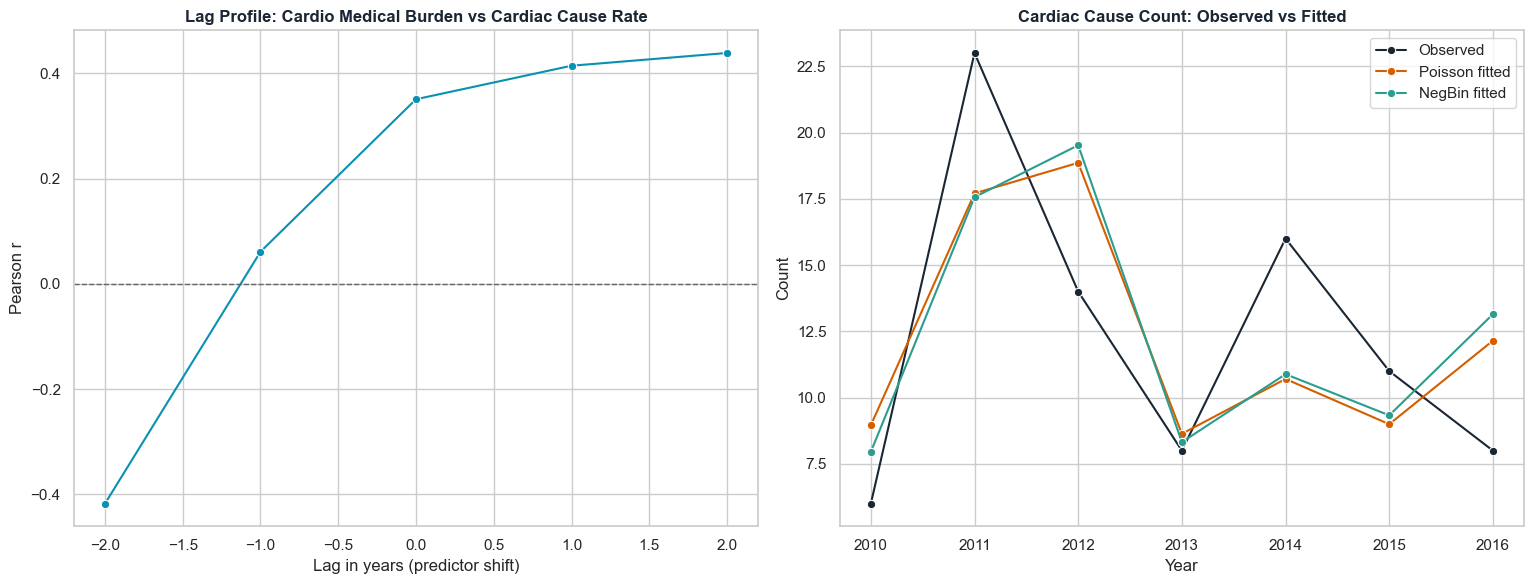

In [30]:
# Deep-dive: cardiovascular medical outcome investigation (focused + robust models)
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")

required_objs = ["medical_long", "network_data", "year_totals", "disable_long"]
missing_objs = [o for o in required_objs if o not in globals()]
if missing_objs:
    raise RuntimeError(f"Run prior prep/model cells first. Missing: {missing_objs}")

# -----------------------------
# 1) Build focused cardiovascular predictor series
# -----------------------------
cardio_aliases = {"cardiovascular disease", "hypertension"}
med = medical_long.copy()
med["cond_norm"] = med["Condition"].astype(str).str.strip().str.lower()
cardio_med_year = (
    med[med["cond_norm"].isin(cardio_aliases)]
    .groupby("year", as_index=False)["count"]
    .sum()
    .rename(columns={"count": "cardio_condition_count"})
)

totals = year_totals[["year", "total_fatalities"]].copy()
totals["year"] = pd.to_numeric(totals["year"], errors="coerce").astype(int)
totals["total_fatalities"] = pd.to_numeric(totals["total_fatalities"], errors="coerce").fillna(0)
totals = totals[totals["total_fatalities"] > 0].copy()

base_cardio = cardio_med_year.merge(totals, on="year", how="inner")
base_cardio["cardio_per_100_fatalities"] = (base_cardio["cardio_condition_count"] / base_cardio["total_fatalities"]) * 100

if base_cardio.empty:
    raise RuntimeError("No overlap between cardiovascular medical years and fatality totals.")

# -----------------------------
# 2) Build cardiovascular-related outcomes across stages
# -----------------------------
nd = network_data.copy()
if "Year" not in nd.columns and "Trigger" in nd.columns:
    nd = nd.rename(columns={"Trigger": "Year"})
nd["Year"] = pd.to_numeric(nd["Year"], errors="coerce")
nd = nd.dropna(subset=["Year"]).copy()
nd["Year"] = nd["Year"].astype(int)

for col in ["Medical Trigger", "Cardiac/Heart Cause"]:
    if col not in nd.columns:
        raise RuntimeError(f"Expected grouped column not found: {col}")
    nd[col] = pd.to_numeric(nd[col], errors="coerce").fillna(0)

# Cardiovascular-relevant disabling outcomes from disable_long
dlong = disable_long.copy()
dlong["outcome_norm"] = dlong["Disabling"].astype(str).str.strip().str.lower()
cardio_disable_mask = dlong["outcome_norm"].str.contains(r"cardiac|cardio|heart|hypertension|stroke|seizure|loss of consciousness", regex=True, na=False)
cardio_disable_year = (
    dlong[cardio_disable_mask]
    .groupby("year", as_index=False)["count"]
    .sum()
    .rename(columns={"count": "cardio_disabling_count"})
)

outcomes = (
    nd.groupby("Year", as_index=False)[["Medical Trigger", "Cardiac/Heart Cause"]]
    .sum()
    .rename(columns={
        "Year": "year",
        "Medical Trigger": "medical_trigger_count",
        "Cardiac/Heart Cause": "cardiac_cause_count",
    })
    .merge(cardio_disable_year, on="year", how="left")
)
outcomes["cardio_disabling_count"] = outcomes["cardio_disabling_count"].fillna(0)

cardio_focus = (
    base_cardio.merge(outcomes, on="year", how="inner")
    .sort_values("year")
    .reset_index(drop=True)
)
if len(cardio_focus) < 5:
    raise RuntimeError("Not enough overlapping years for focused cardiovascular modeling.")

for c in ["medical_trigger_count", "cardiac_cause_count", "cardio_disabling_count"]:
    cardio_focus[f"{c}_per_100"] = (cardio_focus[c] / cardio_focus["total_fatalities"]) * 100

print("Cardiovascular-focused yearly table:")
display(cardio_focus)

# -----------------------------
# 3) Lag scan: cardio burden vs cardio outcomes
# -----------------------------
def lag_corr(df, x_col, y_col, lags=range(-2, 3)):
    rows = []
    for lag in lags:
        tmp = df[[x_col, y_col]].copy()
        tmp["x_lagged"] = tmp[x_col].shift(lag)
        sub = tmp[["x_lagged", y_col]].dropna()
        if len(sub) >= 3 and sub["x_lagged"].nunique() > 1 and sub[y_col].nunique() > 1:
            r = sub["x_lagged"].corr(sub[y_col])
        else:
            r = np.nan
        rows.append({"lag": lag, "n_pairs": len(sub), "pearson_r": r})
    return pd.DataFrame(rows)

lag_results = {}
for y_col in ["medical_trigger_count_per_100", "cardiac_cause_count_per_100", "cardio_disabling_count_per_100"]:
    lag_results[y_col] = lag_corr(cardio_focus, "cardio_per_100_fatalities", y_col)

print("\nLag scan results (predictor shifted by lag years):")
for name, df_lag in lag_results.items():
    print(f"\nOutcome: {name}")
    display(df_lag)

# -----------------------------
# 4) Robust modeling: Poisson + Negative Binomial
# -----------------------------
model_rows = []
fitted_ts = []

for outcome_col in ["medical_trigger_count", "cardiac_cause_count", "cardio_disabling_count"]:
    mdf = cardio_focus[["year", "total_fatalities", "cardio_condition_count", outcome_col]].copy()
    mdf = mdf.rename(columns={outcome_col: "outcome_count"})
    mdf["year_centered"] = mdf["year"] - mdf["year"].mean()
    mdf["offset"] = np.log(mdf["total_fatalities"])

    # Poisson (HC3 robust SE)
    pois_fit = smf.glm(
        "outcome_count ~ cardio_condition_count + year_centered",
        data=mdf,
        family=sm.families.Poisson(),
        offset=mdf["offset"],
    ).fit(cov_type="HC3")

    # Negative Binomial (helps with overdispersion)
    nb_fit = smf.glm(
        "outcome_count ~ cardio_condition_count + year_centered",
        data=mdf,
        family=sm.families.NegativeBinomial(alpha=1.0),
        offset=mdf["offset"],
    ).fit(cov_type="HC3")

    for model_name, fit_obj in [("Poisson_HC3", pois_fit), ("NegBin_HC3", nb_fit)]:
        beta = fit_obj.params.get("cardio_condition_count", np.nan)
        se = fit_obj.bse.get("cardio_condition_count", np.nan)
        p = fit_obj.pvalues.get("cardio_condition_count", np.nan)
        lcl = beta - 1.96 * se if pd.notna(beta) and pd.notna(se) else np.nan
        ucl = beta + 1.96 * se if pd.notna(beta) and pd.notna(se) else np.nan
        model_rows.append({
            "outcome": outcome_col,
            "model": model_name,
            "beta": beta,
            "irr": np.exp(beta) if pd.notna(beta) else np.nan,
            "irr_lcl": np.exp(lcl) if pd.notna(lcl) else np.nan,
            "irr_ucl": np.exp(ucl) if pd.notna(ucl) else np.nan,
            "p_value": p,
            "pearson_chi2_df": float(getattr(fit_obj, "pearson_chi2", np.nan) / fit_obj.df_resid) if fit_obj.df_resid > 0 else np.nan,
        })

    pred = mdf[["year"]].copy()
    pred["outcome"] = outcome_col
    pred["observed"] = mdf["outcome_count"].values
    pred["poisson_fitted"] = pois_fit.fittedvalues.values
    pred["negbin_fitted"] = nb_fit.fittedvalues.values
    fitted_ts.append(pred)

cardio_model_results = pd.DataFrame(model_rows).sort_values(["outcome", "model"]).reset_index(drop=True)
cardio_fitted_series = pd.concat(fitted_ts, ignore_index=True)

print("\nCardiovascular focused model results:")
display(cardio_model_results)

# -----------------------------
# 5) Visual summary
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6))

# Left: lag profile for cardiac cause (core outcome)
lag_core = lag_results["cardiac_cause_count_per_100"]
sns.lineplot(data=lag_core, x="lag", y="pearson_r", marker="o", ax=axes[0], color="#0891b2")
axes[0].axhline(0, linestyle="--", linewidth=1, color="#666")
axes[0].set_title("Lag Profile: Cardio Medical Burden vs Cardiac Cause Rate")
axes[0].set_xlabel("Lag in years (predictor shift)")
axes[0].set_ylabel("Pearson r")

# Right: observed vs fitted for cardiac cause
plot_core = cardio_fitted_series[cardio_fitted_series["outcome"] == "cardiac_cause_count"]
sns.lineplot(data=plot_core, x="year", y="observed", marker="o", label="Observed", ax=axes[1], color="#1a2634")
sns.lineplot(data=plot_core, x="year", y="poisson_fitted", marker="o", label="Poisson fitted", ax=axes[1], color="#d55e00")
sns.lineplot(data=plot_core, x="year", y="negbin_fitted", marker="o", label="NegBin fitted", ax=axes[1], color="#2a9d8f")
axes[1].set_title("Cardiac Cause Count: Observed vs Fitted")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

# keep outputs
cardio_focus_table = cardio_focus.copy()
cardio_lag_results = lag_results
cardio_model_results_table = cardio_model_results.copy()
cardio_fitted_table = cardio_fitted_series.copy()

Top medical condition ↔ disabling agent associations (seasickness removed):


,medical_condition,disabling_agent,n_years,spearman_rho,p_value,q_value,significant_fdr_0_05,abs_rho
0,Hypertension,Drowning/ Asphixia,7,0.962950,0.000497,0.065663,False,0.962950
1,Hypertension,Cardiovascular disease,7,0.927273,0.002634,0.173823,False,0.927273
2,Pulmonary,Seizure,7,0.900000,0.005752,0.253067,False,0.900000
3,Hypertension,Heart problem,7,-0.874767,0.009953,0.328464,False,0.874767
4,Cardiovascular disease,Seizure,7,0.845403,0.016577,0.437635,False,0.845403
5,Nervous System,Cardiovascular disease,7,0.797724,0.031590,0.602175,False,0.797724
6,Nervous System,Immersion pulmonary edema,7,0.793725,0.033099,0.602175,False,0.793725
7,Depression,Arterial gas embolism,7,0.783929,0.036960,0.602175,False,0.783929
8,Cardiovascular disease,Cardiovascular disease,7,0.774136,0.041057,0.602175,False,0.774136
9,Flu/cold,Other,7,0.763763,0.045659,0.602700,False,0.763763



Significant pairs after FDR correction: 0
Saved heatmap to: figures/preexisting-medical-conditions-spearman-heatmap.png


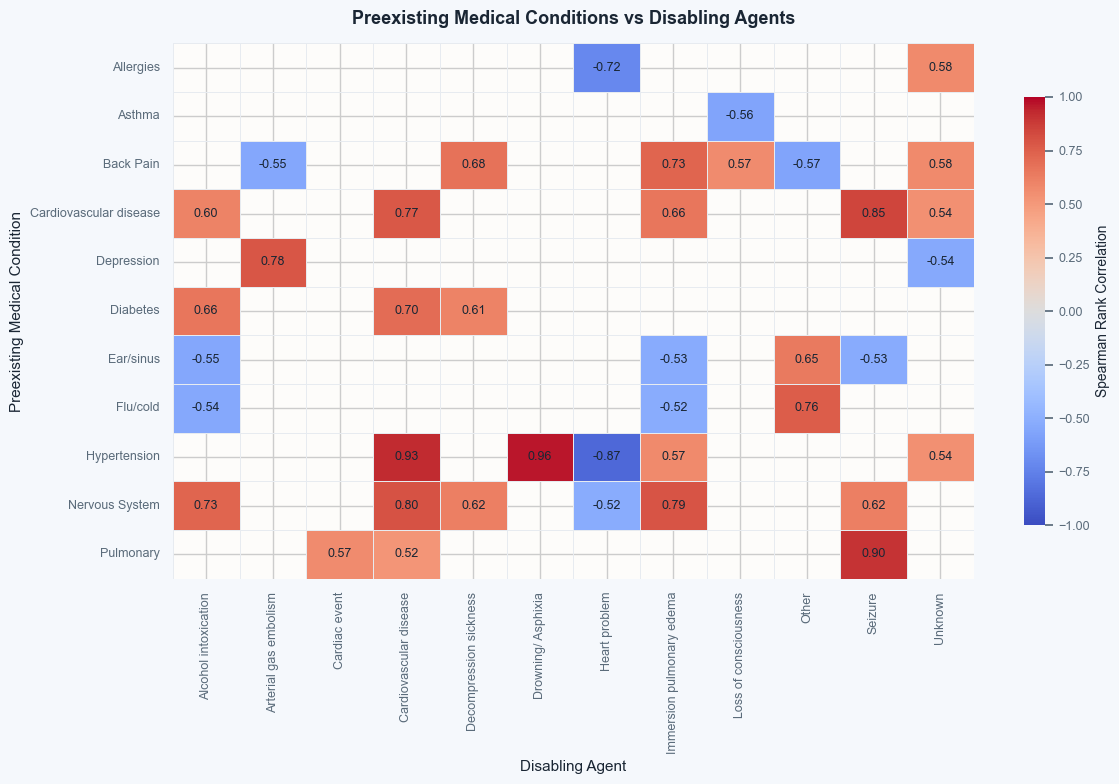

In [40]:
# Association check: preexisting medical conditions vs disabling injuries (exclude seasickness)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

required_objs = ["medical_long", "disable_long", "year_totals"]
missing_objs = [o for o in required_objs if o not in globals()]
if missing_objs:
    raise RuntimeError(f"Run prior prep cells first. Missing: {missing_objs}")

# ---- 1) Clean + prep yearly condition and disabling series ----
med = medical_long.copy()
dis = disable_long.copy()

med["Condition"] = med["Condition"].astype(str).str.strip()
dis["Disabling"] = dis["Disabling"].astype(str).str.strip()

# Ignore seasickness as requested (from both condition and disabling sides)
med = med[~med["Condition"].str.contains("seasick", case=False, na=False)].copy()
dis = dis[~dis["Disabling"].str.contains("seasick", case=False, na=False)].copy()

for df, c in [(med, "count"), (dis, "count")]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df.dropna(subset=["year"], inplace=True)
    df["year"] = df["year"].astype(int)

# Keep most informative categories to reduce sparse/noisy pair tests
TOP_MED = 12
TOP_DIS = 12

top_med = (
    med.groupby("Condition", as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
    .head(TOP_MED)["Condition"]
    .tolist()
)
top_dis = (
    dis.groupby("Disabling", as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
    .head(TOP_DIS)["Disabling"]
    .tolist()
)

med_sub = med[med["Condition"].isin(top_med)].copy()
dis_sub = dis[dis["Disabling"].isin(top_dis)].copy()

med_wide = med_sub.pivot_table(index="year", columns="Condition", values="count", aggfunc="sum", fill_value=0)
dis_wide = dis_sub.pivot_table(index="year", columns="Disabling", values="count", aggfunc="sum", fill_value=0)

# align years for fair pairwise tests
common_years = med_wide.index.intersection(dis_wide.index)
med_wide = med_wide.loc[common_years].sort_index()
dis_wide = dis_wide.loc[common_years].sort_index()

if len(common_years) < 5:
    raise RuntimeError("Not enough overlapping years for association testing.")

# ---- 2) Pairwise association tests (Spearman across years) ----
rows = []
for m in med_wide.columns:
    for d in dis_wide.columns:
        x = med_wide[m]
        y = dis_wide[d]
        valid = np.isfinite(x) & np.isfinite(y)
        x = x[valid]
        y = y[valid]

        if len(x) < 5 or x.nunique() < 2 or y.nunique() < 2:
            continue

        rho, p = spearmanr(x, y)
        rows.append({
            "medical_condition": m,
            "disabling_agent": d,
            "n_years": int(len(x)),
            "spearman_rho": float(rho),
            "p_value": float(p),
        })

assoc_results = pd.DataFrame(rows)
if assoc_results.empty:
    raise RuntimeError("No valid condition-disabling pairs after filtering.")

# Multiple-testing correction
reject, qvals, _, _ = multipletests(assoc_results["p_value"].values, alpha=0.05, method="fdr_bh")
assoc_results["q_value"] = qvals
assoc_results["significant_fdr_0_05"] = reject
assoc_results["abs_rho"] = assoc_results["spearman_rho"].abs()

assoc_results = assoc_results.sort_values(
    ["significant_fdr_0_05", "abs_rho", "p_value"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("Top medical condition ↔ disabling agent associations (seasickness removed):")
display(assoc_results.head(25))

sig = assoc_results[assoc_results["significant_fdr_0_05"]].copy()
print(f"\nSignificant pairs after FDR correction: {len(sig)}")
if not sig.empty:
    display(sig.head(25))

# ---- 3) Heatmap for strongest pairs ----
_T = {
    'bg':     '#f5f8fc',
    'panel':  '#fdfcfa',
    'line':   '#e7ebf0',
    'text':   '#1a2634',
    'muted':  '#5a6b7a',
}

plot_pairs = assoc_results.head(40).copy()
heat = plot_pairs.pivot_table(
    index="medical_condition",
    columns="disabling_agent",
    values="spearman_rho",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(12, 8), facecolor=_T['bg'])
ax.set_facecolor(_T['panel'])
sns.heatmap(
    heat,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    linecolor=_T['line'],
    annot_kws={'size': 9, 'color': _T['text']},
    cbar_kws={'label': 'Spearman Rank Correlation', 'shrink': 0.8},
    ax=ax,
)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color(_T['text'])
cbar.ax.yaxis.label.set_fontsize(10)
cbar.ax.tick_params(colors=_T['muted'], labelsize=9)
cbar.outline.set_edgecolor(_T['line'])
ax.set_title('Preexisting Medical Conditions vs Disabling Agents', color=_T['text'], fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Disabling Agent', color=_T['text'], fontsize=11)
ax.set_ylabel('Preexisting Medical Condition', color=_T['text'], fontsize=11)
ax.tick_params(axis='both', colors=_T['muted'], labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor(_T['line'])
plt.tight_layout()

export_path = Path('figures') / 'preexisting-medical-conditions-spearman-heatmap.png'
fig.savefig(export_path, dpi=300, bbox_inches='tight')
print(f"Saved heatmap to: {export_path}")

plt.show()

# Keep outputs for write-up / downstream use
condition_disabling_assoc = assoc_results.copy()
condition_disabling_sig = sig.copy()
condition_disabling_heat = heat.copy()

Hypothesis-driven pair results (biologically motivated):


,medical_condition,disabling_agent,n_years,spearman_rho,p_value,note,q_value,significant_fdr_0_05,abs_rho
0,Hypertension,Drowning/ Asphixia,7,0.962950,0.000497,,0.007462,True,0.962950
1,Hypertension,Cardiovascular disease,7,0.927273,0.002634,,0.019753,True,0.927273
2,Hypertension,Heart problem,7,-0.874767,0.009953,,0.049767,True,0.874767
3,Cardiovascular disease,Cardiovascular disease,7,0.774136,0.041057,,0.153965,False,0.774136
4,Diabetes,Cardiovascular disease,7,0.697277,0.081610,,0.244829,False,0.697277
5,Nervous System,Seizure,7,0.617342,0.139673,,0.349182,False,0.617342
6,Diabetes,Cardiac event,7,-0.519675,0.231906,,0.474694,False,0.519675
7,Cardiovascular disease,Drowning/ Asphixia,7,0.500000,0.253170,,0.474694,False,0.500000
8,Pulmonary,Drowning/ Asphixia,7,0.417483,0.351373,,0.585622,False,0.417483
9,Cardiovascular disease,Heart problem,7,-0.350982,0.440167,,0.660250,False,0.350982



Significant hypothesis pairs (FDR q < 0.05): 3


,medical_condition,disabling_agent,n_years,spearman_rho,p_value,note,q_value,significant_fdr_0_05,abs_rho
0,Hypertension,Drowning/ Asphixia,7,0.962950,0.000497,,0.007462,True,0.962950
1,Hypertension,Cardiovascular disease,7,0.927273,0.002634,,0.019753,True,0.927273
2,Hypertension,Heart problem,7,-0.874767,0.009953,,0.049767,True,0.874767


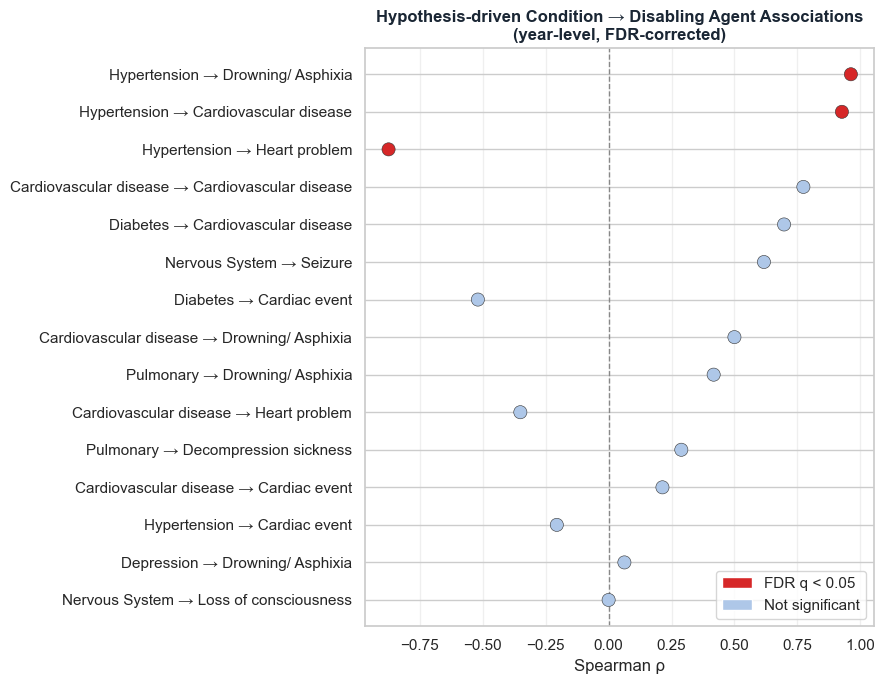

In [36]:
# ── Hypothesis-driven subset: focused pairs most plausible from diving physiology ──
# Testing only biologically motivated condition × disabling-agent pairs,
# which increases per-test power and is more defensible than fishing across all combos.

from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

HYPOTHESIS_PAIRS = [
    # (medical_condition_label,          disabling_agent_label)
    ("Hypertension",                     "Cardiovascular disease"),
    ("Hypertension",                     "Cardiac event"),
    ("Hypertension",                     "Drowning/ Asphixia"),
    ("Hypertension",                     "Heart problem"),
    ("Cardiovascular disease",           "Cardiovascular disease"),
    ("Cardiovascular disease",           "Cardiac event"),
    ("Cardiovascular disease",           "Heart problem"),
    ("Cardiovascular disease",           "Drowning/ Asphixia"),
    ("Diabetes",                         "Cardiovascular disease"),
    ("Diabetes",                         "Cardiac event"),
    ("Pulmonary",                        "Drowning/ Asphixia"),
    ("Pulmonary",                        "Decompression sickness"),
    ("Nervous System",                   "Seizure"),
    ("Nervous System",                   "Loss of consciousness"),
    ("Depression",                       "Drowning/ Asphixia"),
]

hyp_rows = []
for m_label, d_label in HYPOTHESIS_PAIRS:
    med_cols = [c for c in med_wide.columns if c.strip().lower() == m_label.strip().lower()]
    dis_cols = [c for c in dis_wide.columns if c.strip().lower() == d_label.strip().lower()]
    if not med_cols or not dis_cols:
        hyp_rows.append({
            "medical_condition": m_label,
            "disabling_agent": d_label,
            "n_years": 0,
            "spearman_rho": np.nan,
            "p_value": np.nan,
            "note": "column not found in top-12",
        })
        continue
    x = med_wide[med_cols[0]]
    y = dis_wide[dis_cols[0]]
    valid_mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid_mask], y[valid_mask]
    if len(x) < 4 or x.nunique() < 2 or y.nunique() < 2:
        hyp_rows.append({
            "medical_condition": m_label,
            "disabling_agent": d_label,
            "n_years": int(len(x)),
            "spearman_rho": np.nan,
            "p_value": np.nan,
            "note": "insufficient variation",
        })
        continue
    rho_val, p_val = spearmanr(x, y)
    hyp_rows.append({
        "medical_condition": m_label,
        "disabling_agent": d_label,
        "n_years": int(len(x)),
        "spearman_rho": float(rho_val),
        "p_value": float(p_val),
        "note": "",
    })

hyp_df = pd.DataFrame(hyp_rows)
testable = hyp_df.dropna(subset=["p_value"]).copy()

if not testable.empty:
    rej, qv, _, _ = multipletests(testable["p_value"].values, alpha=0.05, method="fdr_bh")
    testable["q_value"] = qv
    testable["significant_fdr_0_05"] = rej
    testable["abs_rho"] = testable["spearman_rho"].abs()
    testable = testable.sort_values(["significant_fdr_0_05", "abs_rho"], ascending=[False, False]).reset_index(drop=True)

print("Hypothesis-driven pair results (biologically motivated):")
display(testable)

sig_hyp = testable[testable["significant_fdr_0_05"]] if "significant_fdr_0_05" in testable.columns else pd.DataFrame()
print(f"\nSignificant hypothesis pairs (FDR q < 0.05): {len(sig_hyp)}")
if not sig_hyp.empty:
    display(sig_hyp)

# ── Dot-plot of all hypothesis pairs ──
fig, ax = plt.subplots(figsize=(9, 7))
dot_colors = testable["significant_fdr_0_05"].map({True: "#d62728", False: "#aec7e8"})
ax.scatter(
    testable["spearman_rho"],
    testable["medical_condition"] + " → " + testable["disabling_agent"],
    c=dot_colors,
    s=90,
    zorder=3,
    edgecolors="#333",
    linewidths=0.4,
)
ax.axvline(0, color="#888", linewidth=1, linestyle="--")
ax.set_xlabel("Spearman ρ")
ax.set_title("Hypothesis-driven Condition → Disabling Agent Associations\n(year-level, FDR-corrected)")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
legend_elements = [
    Patch(facecolor="#d62728", label="FDR q < 0.05"),
    Patch(facecolor="#aec7e8", label="Not significant"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

hypothesis_assoc_results = testable.copy()
